# Retail Customer Analytics — CRISP-DM Mini Project

**ชุดข้อมูล:** ธุรกรรมค้าปลีก omni-channel 24 เดือน (2024-09-01 → 2026-08-31) · สกุลเงิน THB
**วันอ้างอิง (Reference Date):** 2026-08-31

## คำถามจากผู้บริหาร 3 ข้อ

| # | คำถาม | ตอบในหัวข้อ |
|---|---|---|
| 1 | **Increase Basket Size** — สินค้าใดมักถูกซื้อคู่กัน ควรจัดโปรร่วมกันอย่างไร | §4.1 |
| 2 | **Customer Segmentation** — พฤติกรรมการซื้อแบ่งลูกค้าได้กี่กลุ่ม แต่ละกลุ่มมีลักษณะเด่นอย่างไร | §4.2 |
| 3 | **Customer Retention** — ลูกค้ารายใดมีแนวโน้มหยุดซื้อ และพฤติกรรมใดเป็นสัญญาณเตือน | §4.3 |

## โครงสร้าง Notebook (ตามกระบวนการ CRISP-DM)

```
§1 Business Understanding   →  แปลคำถามธุรกิจเป็นโจทย์ ML + เหตุผลการเลือกเทคนิค
§2 Data Understanding       →  สำรวจข้อมูล 6 ตาราง + ตรวจคุณภาพข้อมูล + EDA
§3 Data Preparation         →  ทำความสะอาด + สร้าง 3 ชุดข้อมูลสำหรับ 3 โจทย์
§4 Modeling                 →  4.1 Association Rules · 4.2 Clustering · 4.3 Classification
§5 Evaluation               →  ประเมินผลเทียบเป้าหมายธุรกิจ + หาสัญญาณเตือน
§6 Deployment               →  รายชื่อลูกค้าเสี่ยง + กลยุทธ์ + แผน monitoring
```

> **หมายเหตุการรัน:** notebook นี้ออกแบบให้กด **Run All** ผ่านตั้งแต่ต้นจนจบโดยไม่มี Error
> ทุกตัวเลขที่อ้างอิงในรายงานถูกบันทึกลง `outputs/report_values.json` โดยอัตโนมัติ

---
# §0 Setup

ตั้งค่าสภาพแวดล้อม กำหนดค่าคงที่ และสร้างกลไกบันทึกตัวเลขสำหรับรายงาน

In [1]:
# --- Standard library ---
import json
import time
import warnings
from pathlib import Path

# --- Core data stack ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility: one seed used everywhere in this notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling - consistent across every figure so the report looks like one document
# NOTE: seaborn's theme overwrites rcParams, so it must be applied BEFORE the font
# configuration in the next cell - otherwise the Thai font setting is silently lost.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "figure.autolayout": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "font.size": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")

pandas 3.0.5 | numpy 2.5.3 | matplotlib 3.11.1


### การตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟ

matplotlib ไม่มีฟอนต์ภาษาไทยเป็นค่าเริ่มต้น ถ้าไม่ตั้งค่าตรงนี้ ข้อความไทยบนกราฟทุกใบ
จะกลายเป็นสี่เหลี่ยมว่าง (□□□) ซึ่งทำให้รายงานใช้งานไม่ได้

เซลล์ถัดไปจะค้นหาฟอนต์ที่รองรับภาษาไทยในเครื่องโดยอัตโนมัติ ทดสอบว่าเรนเดอร์ได้จริง
แล้วจึงนำไปใช้ — หากไม่พบจะแจ้งเตือนอย่างชัดเจนแทนที่จะปล่อยให้กราฟเสียเงียบ ๆ

In [2]:
from matplotlib import font_manager as fm
from matplotlib import ft2font

# Candidate Thai-capable fonts across the three major platforms, best-looking first.
THAI_FONT_CANDIDATES = [
    # macOS
    "/System/Library/Fonts/Supplemental/SukhumvitSet.ttc",
    "/System/Library/Fonts/Supplemental/Thonburi.ttc",
    "/System/Library/Fonts/Supplemental/Ayuthaya.ttf",
    "/System/Library/Fonts/Supplemental/Krungthep.ttf",
    # Linux
    "/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansThai-Regular.ttf",
    "/usr/share/fonts/truetype/tlwg/Sarabun.ttf",
    "/usr/share/fonts/truetype/tlwg/Loma.ttf",
    # Windows
    "C:/Windows/Fonts/leelawui.ttf",
    "C:/Windows/Fonts/leelawad.ttf",
    "C:/Windows/Fonts/tahoma.ttf",
]

THAI_PROBE = ord("ก")   # a plain Thai consonant
DIGIT_PROBE = ord("9")  # charts need Latin digits too - some Thai fonts lack them


def font_supports_thai(path):
    # A font qualifies only if it can render BOTH Thai letters and Latin digits.
    try:
        face = ft2font.FT2Font(path)
        return bool(face.get_char_index(THAI_PROBE)) and bool(face.get_char_index(DIGIT_PROBE))
    except Exception:
        return False


def find_thai_font():
    # 1) known locations, in order of preference
    for path in THAI_FONT_CANDIDATES:
        if Path(path).exists() and font_supports_thai(path):
            return path
    # 2) fall back to scanning whatever is installed on this machine
    for entry in fm.fontManager.ttflist:
        if font_supports_thai(entry.fname):
            return entry.fname
    return None


THAI_FONT_PATH = find_thai_font()

if THAI_FONT_PATH:
    fm.fontManager.addfont(THAI_FONT_PATH)
    THAI_FONT_NAME = fm.FontProperties(fname=THAI_FONT_PATH).get_name()
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = [THAI_FONT_NAME, "DejaVu Sans", "Arial"]
    # Thai fonts often lack U+2212 MINUS SIGN; use the ASCII hyphen instead
    plt.rcParams["axes.unicode_minus"] = False
    print(f"ฟอนต์ภาษาไทยที่ใช้: {THAI_FONT_NAME}")
    print(f"  ที่อยู่ไฟล์: {THAI_FONT_PATH}")
else:
    THAI_FONT_NAME = None
    print("!" * 70)
    print("คำเตือน: ไม่พบฟอนต์ภาษาไทยในเครื่องนี้")
    print("ข้อความไทยบนกราฟจะแสดงเป็นสี่เหลี่ยมว่าง (tofu)")
    print("วิธีแก้: ติดตั้งฟอนต์ เช่น Noto Sans Thai หรือ Sarabun แล้วรันใหม่")
    print("!" * 70)

ฟอนต์ภาษาไทยที่ใช้: Sukhumvit Set
  ที่อยู่ไฟล์: /System/Library/Fonts/Supplemental/SukhumvitSet.ttc


In [3]:
# Verify the font actually renders Thai - do not just trust that it was set.
# matplotlib emits a warning per missing glyph, so we render a probe string
# containing tone marks, vowels above/below, digits and a minus sign, then
# count how many glyphs it could not draw.
def verify_thai_rendering():
    probe = "ทดสอบ ลูกค้าที่กำลังจะหยุดซื้อ ก้ ก่ ก๊ ก๋ ญ ฐ · 90% -1.5 (บาท)"
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fig_probe, ax_probe = plt.subplots(figsize=(6, 1))
        ax_probe.text(0.02, 0.5, probe)
        ax_probe.axis("off")
        fig_probe.canvas.draw()
        plt.close(fig_probe)
    return [str(w.message) for w in caught if "missing from font" in str(w.message)]


missing_glyphs = verify_thai_rendering()
THAI_RENDER_OK = (THAI_FONT_NAME is not None) and (len(missing_glyphs) == 0)

if THAI_RENDER_OK:
    print("ตรวจสอบการเรนเดอร์: ผ่าน - วาดภาษาไทย ตัวเลข วรรณยุกต์ และเครื่องหมายลบได้ครบ")
elif THAI_FONT_NAME:
    print(f"ตรวจสอบการเรนเดอร์: พบอักขระที่วาดไม่ได้ {len(missing_glyphs)} ตัว")
    for m in missing_glyphs[:5]:
        print(f"   {m}")
else:
    print("ข้ามการตรวจสอบ เพราะไม่พบฟอนต์ภาษาไทย")

ตรวจสอบการเรนเดอร์: ผ่าน - วาดภาษาไทย ตัวเลข วรรณยุกต์ และเครื่องหมายลบได้ครบ


In [4]:
# --- Paths (all relative, so the notebook runs anywhere the folder is copied) ---
DATA_DIR = Path("student_package")
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
TBL_DIR = OUT_DIR / "tables"
for d in (FIG_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Key dates (from DATA_DICTIONARY.md) ---
REFERENCE_DATE = pd.Timestamp("2026-08-31")   # end of observation window
FEATURE_CUTOFF = pd.Timestamp("2026-06-01")   # churn features may use data up to HERE only
OUTCOME_START = pd.Timestamp("2026-06-02")    # churn outcome window starts here
WINDOW_START = pd.Timestamp("2024-09-01")     # start of observation window

# Churn definition: churn = 1  <=>  recency_days > 90  <=>  no purchase in [OUTCOME_START, REFERENCE_DATE]
CHURN_HORIZON_DAYS = 90

print(f"Feature window : {WINDOW_START.date()} -> {FEATURE_CUTOFF.date()}")
print(f"Outcome window : {OUTCOME_START.date()} -> {REFERENCE_DATE.date()}  ({CHURN_HORIZON_DAYS} days)")

Feature window : 2024-09-01 -> 2026-06-01
Outcome window : 2026-06-02 -> 2026-08-31  (90 days)


### กลไกบันทึกตัวเลขสำหรับรายงาน

ทุกตัวเลขที่จะถูกอ้างอิงในรายงานต้องผ่านฟังก์ชัน `rv()` เพื่อบันทึกลง `outputs/report_values.json`
ทำให้ **ตัวเลขในรายงานตรวจสอบย้อนกลับมาที่ผลรันจริงได้ทุกตัว** ไม่มีการพิมพ์ตัวเลขจากความจำ

In [5]:
# Report-value registry: every number quoted in the report must pass through rv()
REPORT_VALUES = {}


def rv(key, value, note=""):
    # Record a value for the report and return it unchanged, so it can be used inline.
    if isinstance(value, (np.integer,)):
        value = int(value)
    elif isinstance(value, (np.floating,)):
        value = float(value)
    elif isinstance(value, (np.bool_,)):
        value = bool(value)
    REPORT_VALUES[key] = {"value": value, "note": note} if note else {"value": value}
    return value


def save_fig(fig, name):
    # Save a figure to outputs/figures and register its path for the report.
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    REPORT_VALUES.setdefault("_figures", []).append(str(path))
    return path


def save_table(df, name, index=False):
    # Save a table to outputs/tables and register its path + shape for the report.
    path = TBL_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    REPORT_VALUES.setdefault("_tables", []).append({"path": str(path), "rows": int(len(df))})
    return path


def dump_report_values():
    # Write every registered value to disk. Called at the end of the notebook.
    with open(OUT_DIR / "report_values.json", "w", encoding="utf-8") as fh:
        json.dump(REPORT_VALUES, fh, ensure_ascii=False, indent=2, sort_keys=True)
    n = len([k for k in REPORT_VALUES if not k.startswith("_")])
    print(f"Wrote {n} report values -> {OUT_DIR / 'report_values.json'}")


# Record the font situation so the report can state which font produced its figures
rv("fig_thai_font_name", THAI_FONT_NAME if THAI_FONT_NAME else "not found")
rv("fig_thai_render_ok", bool(THAI_RENDER_OK))

print("Report-value registry ready.")

Report-value registry ready.


---
# §1 Business Understanding

## 1.1 บริบทและเป้าหมายทางธุรกิจ

ผู้บริหารต้องการเพิ่มรายได้ผ่าน 3 คันโยก ซึ่งเป็นคันโยกคลาสสิกของธุรกิจค้าปลีก:

| คันโยก | คำถามผู้บริหาร | ตัวชี้วัดที่ต้องการขยับ |
|---|---|---|
| **ขายต่อบิลให้มากขึ้น** | สินค้าใดมักถูกซื้อคู่กัน | Average Basket Size / Items per Transaction |
| **ยิงโปรให้ตรงกลุ่ม** | แบ่งลูกค้าได้กี่กลุ่ม | Campaign ROI / Conversion Rate |
| **รักษาลูกค้าเดิม** | ใครกำลังจะหยุดซื้อ | Retention Rate / Customer Lifetime Value |

> **ทำไมคันโยกที่ 3 สำคัญที่สุด:** ต้นทุนการหาลูกค้าใหม่สูงกว่าการรักษาลูกค้าเดิมหลายเท่า
> การรู้ล่วงหน้าว่าใครกำลังจะหาย ทำให้ยิงโปรได้ก่อนที่ลูกค้าจะไปแล้ว ซึ่งได้ผลกว่าการดึงกลับทีหลังมาก

## 1.2 แปลงคำถามธุรกิจเป็นโจทย์ Machine Learning

| # | คำถามผู้บริหาร | ประเภทโจทย์ ML | ผลลัพธ์ที่ส่งมอบ |
|---|---|---|---|
| 1 | สินค้าใดซื้อคู่กัน | **Unsupervised — Association Rule Mining** | รายการกฎ `{A} → {B}` เรียงตามความแข็งแรง พร้อมข้อเสนอชุดโปรโมชัน |
| 2 | ลูกค้าแบ่งได้กี่กลุ่ม | **Unsupervised — Clustering** | จำนวนกลุ่ม + persona แต่ละกลุ่ม + กลยุทธ์รายกลุ่ม |
| 3 | ใครจะหยุดซื้อ | **Supervised — Binary Classification** | คะแนนความเสี่ยงรายบุคคล + ลำดับความสำคัญของสัญญาณเตือน |

## 1.3 เหตุผลในการเลือกเทคนิค (Technique Justification)

> ส่วนนี้ตอบเกณฑ์ให้คะแนนโดยตรง: *"ต้องระบุเหตุผลในการเลือกใช้เทคนิคทางสถิติ/Machine Learning
> เพื่อตอบโจทย์ธุรกิจแต่ละข้อ"* — เหตุผลแบ่งเป็น 3 ระดับคือ **ทำไมต้องเป็นเทคนิคตระกูลนี้**,
> **ทำไมเลือกอัลกอริทึมตัวนี้ในตระกูล**, และ **ทำไมใช้ metric ตัวนี้ตัดสิน**

---

### โจทย์ที่ 1 — Increase Basket Size → **FP-Growth + Association Rules**

**ทำไมต้องเป็น Association Rule Mining**
ข้อมูลตะกร้าสินค้าไม่มี label ว่า "คู่ไหนคือคู่ที่ดี" จึงเป็นโจทย์ unsupervised
และในบรรดาเทคนิค unsupervised ทั้งหมด มีเพียง association rules ที่ให้ผลลัพธ์เป็น
**กฎที่มนุษย์อ่านออกและเอาไปออกแบบโปรโมชันได้ทันที** — ผู้จัดการฝ่ายจัดซื้ออ่าน
`{ผ้าอ้อม, ทิชชูเปียก} → {โลชั่นเด็ก}` แล้วสั่งจัดชั้นวางได้เลย ไม่ต้องแปลผลอีกชั้น

**ทำไม FP-Growth (ไม่ใช่ Apriori เพียงอย่างเดียว)**
ทั้งคู่ให้ itemset ชุดเดียวกันเป๊ะ แต่ Apriori ต้องสร้าง candidate itemset แล้วสแกนฐานข้อมูลซ้ำทุกรอบ
ขณะที่ FP-Growth บีบข้อมูลเป็น FP-tree แล้วขุดจากต้นไม้ ไม่ต้อง generate candidate
→ ใน §4.1 จะ**วัดเวลารันทั้งสองตัวเทียบกันจริง**เพื่อยืนยันข้อนี้ด้วยตัวเลข ไม่ใช่อ้างจากตำรา

**ทำไมตัดสินด้วย Lift (ไม่ใช่ Confidence)**
Confidence สูงถูก "หลอก" ได้ง่ายด้วยสินค้าที่ขายดีอยู่แล้ว เช่น ถ้านมขายได้ 60% ของบิลทั้งหมด
กฎ `{อะไรก็ตาม} → {นม}` ก็จะมี confidence ~60% โดยไม่มีความหมายอะไรเลย
**Lift** หารด้วยความถี่พื้นฐานของ consequent จึงตอบว่า *"ซื้อ A แล้วโอกาสซื้อ B เพิ่มขึ้นกี่เท่าจากปกติ"*
— Lift > 1 เท่านั้นที่แปลว่ามีความสัมพันธ์จริงเกินความบังเอิญ และคุ้มกับการจัดโปรร่วม

---

### โจทย์ที่ 2 — Customer Segmentation → **RFM + K-Means** (ตรวจสอบด้วย DBSCAN)

**ทำไมต้องเป็น RFM**
RFM (Recency / Frequency / Monetary) เป็นกรอบมาตรฐานของวงการค้าปลีกมากว่า 30 ปี เพราะสรุป
พฤติกรรมการซื้อด้วย 3 คำถามที่ผู้บริหารเข้าใจทันทีโดยไม่ต้องอธิบาย: *ซื้อล่าสุดเมื่อไร · ซื้อบ่อยแค่ไหน · จ่ายเท่าไร*
งานนี้เสริมอีก 5 มิติ (AOV, ความอ่อนไหวต่อส่วนลด, อายุสมาชิก, ความกว้างของหมวดสินค้า, ความลึกของตะกร้า)
เพื่อแยกลูกค้าที่ RFM เท่ากันแต่พฤติกรรมต่างกัน เช่น *คนซื้อของแพงไม่กี่ชิ้น* กับ *คนซื้อของถูกจำนวนมาก*

**ทำไม K-Means**
เพราะให้ **centroid** ซึ่งคือ "ลูกค้าตัวแทน" ของแต่ละกลุ่ม แปลงเป็น persona ที่ทีมการตลาดใช้งานได้ตรง ๆ
(ต่างจาก hierarchical clustering ที่ให้ dendrogram ซึ่งตีความเป็นกลยุทธ์ยากกว่า) และ scale ได้ดีกับข้อมูลหลายพันราย

**ทำไมต้องรัน DBSCAN ทั้งที่รู้ว่าจะใช้ K-Means**
นี่คือ **การตรวจสอบสมมติฐาน ไม่ใช่การแข่งขัน** — K-Means บังคับให้เกิด k กลุ่มเสมอ **แม้ข้อมูลจะไม่มีกลุ่มอยู่จริง**
DBSCAN แบ่งกลุ่มตามความหนาแน่นและ *ปฏิเสธที่จะแบ่งได้* ถ้าไม่มีช่องว่างระหว่างกลุ่ม
การรัน DBSCAN จึงตอบคำถามสำคัญว่า *ผลลัพธ์ที่ได้คือกลุ่มที่มีอยู่จริงตามธรรมชาติ หรือเป็นเส้นที่เราลากขึ้นมาเอง?*
→ คำตอบมีผลต่อวิธีที่ผู้บริหารควรตีความ segment เหล่านี้ (ดู §4.2 และ §5.2)

**ทำไมต้อง log-transform ก่อนทำ scaling**
R/F/M ของข้อมูลค้าปลีกเบ้ขวาจัดเสมอ (ลูกค้าส่วนใหญ่ซื้อน้อย มีหางยาวของ VIP ไม่กี่ราย)
K-Means ใช้ระยะทางแบบยุคลิดซึ่งอ่อนไหวต่อค่าสุดโต่งมาก ถ้าไม่ log ก่อน VIP เพียงไม่กี่รายจะดึง centroid
จนกลุ่มอื่นถูกยุบรวมกันหมด — §2.4 แสดงความเบ้นี้ให้เห็นด้วยกราฟก่อนตัดสินใจ

---

### โจทย์ที่ 3 — Customer Retention → **แชมป์ + ผู้อธิบาย**

**ทำไมเป็น Supervised Classification**
ต่างจาก 2 โจทย์แรก โจทย์นี้ **มีเฉลย** (`churn_labels.csv`) จึงเรียนรู้แบบมีผู้สอนได้
และวัดความถูกต้องได้จริงบนข้อมูลที่โมเดลไม่เคยเห็น

**ทำไมต้องใช้โมเดล 2 บทบาท ไม่ใช่ตัวเดียว**
เพราะคำถามผู้บริหารข้อนี้ซ่อนคำถาม 2 ข้อที่ต้องการคุณสมบัติคนละแบบ:

| คำถามย่อย | ต้องการ | โมเดลที่ตอบ |
|---|---|---|
| *"ลูกค้ารายใดมีแนวโน้มหยุดซื้อ"* | ความแม่นยำในการจัดอันดับความเสี่ยง | **Gradient Boosting / XGBoost** (แชมป์) |
| *"พฤติกรรมใดเป็นสัญญาณเตือน"* | ความสามารถในการอธิบายเป็นภาษาคน | **Logistic Regression + Decision Tree** (ผู้อธิบาย) |

Gradient Boosting ทำนายแม่นแต่เป็นกล่องดำ อธิบายให้ผู้บริหารฟังไม่ได้ว่า *ทำไม*
ส่วน Logistic Regression ให้ค่าสัมประสิทธิ์ที่บอกทิศทางและขนาดของผลกระทบได้ตรง ๆ
และ Decision Tree ให้กฎที่อ่านออกเช่น *"ไม่ซื้อเกิน N วัน + ความถี่ลดลง → เสี่ยง"*
→ **ใช้ทั้งสองบทบาทคู่กันจึงตอบโจทย์ครบ** และ §4.3 จะเทียบโมเดลทั้งหมด 9 ตัวด้วยเงื่อนไขเดียวกันเพื่อยืนยันการเลือก

**ทำไมวัดด้วย PR-AUC และ Recall ไม่ใช่ Accuracy**
อัตราการ churn อยู่ที่ประมาณ 25% ข้อมูลจึงไม่สมดุล — โมเดลที่ทายว่า *"ไม่มีใคร churn เลย"*
จะได้ Accuracy สูงถึง ~75% ทั้งที่ไร้ประโยชน์เชิงธุรกิจโดยสิ้นเชิง
**PR-AUC** โฟกัสที่คลาสส่วนน้อย (ผู้ที่ churn) ซึ่งคือกลุ่มที่เราสนใจ
ส่วน **Recall** ตอบคำถามที่ผู้บริหารสนใจจริง ๆ ว่า *"ในบรรดาคนที่กำลังจะหายไป เราจับได้กี่เปอร์เซ็นต์"*

**ทำไมใช้ class_weight แทน SMOTE**
SMOTE สังเคราะห์ "ลูกค้าปลอม" ที่ไม่มีอยู่จริงขึ้นมาถ่วงดุลคลาส ซึ่งในบริบทที่ผลลัพธ์จะถูกใช้
ส่งคูปองหาคนจริง การเรียนรู้จากลูกค้าที่ไม่มีตัวตนเป็นความเสี่ยงที่ไม่จำเป็น
`class_weight="balanced"` ให้ผลเชิงถ่วงดุลคล้ายกันโดยไม่ปลอมแปลงข้อมูล จึงเหมาะกว่าในงานนี้

## 1.4 ข้อจำกัดสำคัญ: เส้นแบ่งการรั่วไหลของข้อมูล (Leakage Boundary)

นี่คือข้อจำกัดที่สำคัญที่สุดของโจทย์ที่ 3 และเป็นจุดที่ทำให้ผลการทดลองผิดพลาดได้ง่ายที่สุด

```
churn = 1  ⟺  recency_days > 90  ⟺  ไม่มีการซื้อระหว่าง 2026-06-02 ถึง 2026-08-31
```

เนื่องจาก label ถูกนิยามจากพฤติกรรมใน 90 วันสุดท้าย **ฟีเจอร์ใดก็ตามที่คำนวณโดยใช้ข้อมูล
ตั้งแต่ 2026-06-02 เป็นต้นไป เท่ากับแอบดูเฉลย**

| ช่วงเวลา | วันที่ | ใช้ทำอะไร |
|---|---|---|
| **Feature window** | 2024-09-01 → **2026-06-01** | สร้างตัวแปร X ทุกตัว **ที่นี่เท่านั้น** |
| **Outcome window** | **2026-06-02** → 2026-08-31 | นิยาม `churn` เท่านั้น — ห้ามใช้เป็นฟีเจอร์เด็ดขาด |

**คอลัมน์ต้องห้าม** ใน `churn_labels.csv` ที่สะท้อนผลลัพธ์ทั้งช่วงและห้ามใช้เป็น X:
`recency_days` · `last_purchase_date` · `total_transactions`

> §3.4 จะมี **cell ตรวจสอบอัตโนมัติ (assert)** ที่จะหยุดการรันทันทีถ้าพบว่ามีข้อมูลหลังวันตัด
> หรือคอลัมน์ต้องห้ามหลุดเข้าไปในชุดฟีเจอร์ — ทำให้ข้อจำกัดนี้ถูกบังคับด้วยโค้ด ไม่ใช่แค่ความตั้งใจ

---
# §2 Data Understanding

โหลดข้อมูลทั้ง 6 ตาราง สำรวจโครงสร้าง ตรวจคุณภาพ และทำ EDA เพื่อหาข้อค้นพบที่จะกำหนดวิธีเตรียมข้อมูลใน §3

## 2.1 โหลดข้อมูลและตรวจโครงสร้าง

ความสัมพันธ์ระหว่างตาราง:

```
customers ──< transactions ──< transaction_items >── products
    │              │
    └──< support_tickets    churn_labels (1 แถวต่อ 1 ลูกค้า)
```

In [6]:
# Load all six tables. Dates are parsed on read so downstream code never re-parses.
customers_raw = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products_raw = pd.read_csv(DATA_DIR / "products.csv")
transactions_raw = pd.read_csv(DATA_DIR / "transactions.csv", parse_dates=["transaction_date"])
items_raw = pd.read_csv(DATA_DIR / "transaction_items.csv")
tickets_raw = pd.read_csv(DATA_DIR / "support_tickets.csv", parse_dates=["ticket_date"])
churn_raw = pd.read_csv(
    DATA_DIR / "churn_labels.csv",
    parse_dates=["reference_date", "first_purchase_date", "last_purchase_date"],
)

overview = pd.DataFrame([
    {"table": "customers", "rows": len(customers_raw), "cols": customers_raw.shape[1]},
    {"table": "products", "rows": len(products_raw), "cols": products_raw.shape[1]},
    {"table": "transactions", "rows": len(transactions_raw), "cols": transactions_raw.shape[1]},
    {"table": "transaction_items", "rows": len(items_raw), "cols": items_raw.shape[1]},
    {"table": "support_tickets", "rows": len(tickets_raw), "cols": tickets_raw.shape[1]},
    {"table": "churn_labels", "rows": len(churn_raw), "cols": churn_raw.shape[1]},
])

rv("raw_n_customers", len(customers_raw))
rv("raw_n_products", len(products_raw))
rv("raw_n_transactions", len(transactions_raw))
rv("raw_n_items", len(items_raw))
rv("raw_n_tickets", len(tickets_raw))
rv("raw_n_churn_rows", len(churn_raw))
save_table(overview, "t01_table_overview")
overview

,table,rows,cols
0,customers,3015,11
1,products,89,4
2,transactions,66999,12
3,transaction_items,375088,7
4,support_tickets,1636,7
5,churn_labels,3000,8


In [7]:
# Structure of the two central tables
print("=" * 70)
print("transactions.csv")
print("=" * 70)
transactions_raw.info()
print()
print("=" * 70)
print("customers.csv")
print("=" * 70)
customers_raw.info()

transactions.csv
<class 'pandas.DataFrame'>
RangeIndex: 66999 entries, 0 to 66998
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    66999 non-null  str           
 1   customer_id       66999 non-null  str           
 2   transaction_date  66999 non-null  datetime64[us]
 3   channel           66999 non-null  str           
 4   store_id          66999 non-null  str           
 5   payment_method    66999 non-null  str           
 6   n_items           66999 non-null  int64         
 7   total_units       66999 non-null  int64         
 8   gross_amount      66999 non-null  float64       
 9   discount_amount   66999 non-null  float64       
 10  net_amount        66999 non-null  float64       
 11  is_return         66999 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(3), str(5)
memory usage: 6.1 MB

customers.csv
<class 'pandas.DataFrame'>
RangeIndex

In [8]:
# Observation window and reference-date sanity check against the data dictionary
obs_min = transactions_raw.transaction_date.min()
obs_max = transactions_raw.transaction_date.max()
rv("obs_window_start", str(obs_min.date()))
rv("obs_window_end", str(obs_max.date()))
rv("obs_window_months", round((obs_max - obs_min).days / 30.44, 1))

print(f"Observation window : {obs_min.date()} -> {obs_max.date()}")
print(f"Span               : {(obs_max - obs_min).days} days "
      f"({(obs_max - obs_min).days / 30.44:.1f} months)")
print(f"Reference date     : {REFERENCE_DATE.date()}  "
      f"(matches data dictionary: {obs_max == REFERENCE_DATE})")
print(f"churn_labels reference_date is unique: "
      f"{churn_raw.reference_date.nunique() == 1} -> {churn_raw.reference_date.iloc[0].date()}")

Observation window : 2024-09-01 -> 2026-08-31
Span               : 729 days (23.9 months)
Reference date     : 2026-08-31  (matches data dictionary: True)
churn_labels reference_date is unique: True -> 2026-08-31


## 2.2 ตรวจสอบคุณภาพข้อมูล (Data Quality Audit)

`DATA_DICTIONARY.md` ระบุว่าชุดข้อมูลนี้ **จงใจใส่ปัญหาคุณภาพข้อมูลไว้** เพื่อเป็นแบบฝึกหัดขั้น Data Preparation
เราจะตรวจทีละข้อและวัดปริมาณจริง แทนที่จะเชื่อตามเอกสาร

In [9]:
# Quantify every data-quality issue rather than trusting the documentation
audit = []

# 1. Duplicate rows
dup_cust_pk = int(customers_raw.customer_id.duplicated().sum())
dup_cust_full = int(customers_raw.duplicated().sum())
dup_tx_pk = int(transactions_raw.transaction_id.duplicated().sum())
dup_tx_full = int(transactions_raw.duplicated().sum())
audit.append(["customers", "แถวซ้ำ (ซ้ำทั้งแถว)", dup_cust_full, f"{dup_cust_full/len(customers_raw):.2%}"])
audit.append(["transactions", "แถวซ้ำ (ซ้ำทั้งแถว)", dup_tx_full, f"{dup_tx_full/len(transactions_raw):.2%}"])

# 2. Missing values in customers
for col in ["age", "region", "income_bracket", "gender", "membership_tier"]:
    n_missing = int(customers_raw[col].isna().sum())
    if n_missing:
        audit.append(["customers", f"ค่าว่าง: {col}", n_missing, f"{n_missing/len(customers_raw):.2%}"])

# 3. Inconsistent categorical encoding
gender_variants = sorted(customers_raw.gender.dropna().unique().tolist())
audit.append(["customers", "gender สะกดไม่สอดคล้อง", len(gender_variants), ", ".join(gender_variants)])

# 4. Impossible values
impossible_age = int((customers_raw.age > 100).sum())
audit.append(["customers", "อายุเป็นไปไม่ได้ (>100 ปี)", impossible_age,
              f"สูงสุด {customers_raw.age.max():.0f} ปี"])

# 5. Return transactions
n_returns = int((transactions_raw.is_return == 1).sum())
audit.append(["transactions", "รายการคืนสินค้า (is_return=1)", n_returns,
              f"{n_returns/len(transactions_raw):.2%}"])

# 6. Quantity outliers in line items.
# Detect them by distance from the typical value rather than by percentile: §3.2 shows
# the percentile approach picks a threshold inside the range of ordinary purchases.
qty_median = float(items_raw.quantity.median())
n_qty_out = int((items_raw.quantity > qty_median * 10).sum())
audit.append(["transaction_items", "quantity สูงเกิน 10 เท่าของค่ามัธยฐาน", n_qty_out,
              f"สูงสุด {items_raw.quantity.max()} ชิ้น (มัธยฐาน {qty_median:.0f} ชิ้น)"])
audit.append(["transaction_items", "quantity ติดลบ (จากการคืนสินค้า)",
              int((items_raw.quantity < 0).sum()), "คาดหวังไว้แล้ว: มาจากบิลคืนสินค้า"])

audit_df = pd.DataFrame(audit, columns=["ตาราง", "ปัญหาที่พบ", "จำนวน", "รายละเอียด"])

rv("dq_dup_customers", dup_cust_full)
rv("dq_dup_transactions", dup_tx_full)
rv("dq_gender_variants", len(gender_variants), "จำนวนรูปแบบการสะกดของคอลัมน์ gender")
rv("dq_gender_variant_list", gender_variants)
rv("dq_impossible_age", impossible_age)
rv("dq_max_age_raw", float(customers_raw.age.max()))
rv("dq_n_returns", n_returns)
rv("dq_missing_age_pct", round(float(customers_raw.age.isna().mean()) * 100, 2))
rv("dq_missing_region_pct", round(float(customers_raw.region.isna().mean()) * 100, 2))
rv("dq_missing_income_pct", round(float(customers_raw.income_bracket.isna().mean()) * 100, 2))
rv("dq_max_quantity_raw", int(items_raw.quantity.max()))
rv("dq_median_quantity", float(items_raw.quantity.median()))
save_table(audit_df, "t02_data_quality_audit")
audit_df

,ตาราง,ปัญหาที่พบ,จำนวน,รายละเอียด
0,customers,แถวซ้ำ (ซ้ำทั้งแถว),15,0.50%
1,transactions,แถวซ้ำ (ซ้ำทั้งแถว),267,0.40%
2,customers,ค่าว่าง: age,124,4.11%
3,customers,ค่าว่าง: region,68,2.26%
4,customers,ค่าว่าง: income_bracket,184,6.10%
5,customers,gender สะกดไม่สอดคล้อง,8,"F, Female, M, Male, f, female, m, male"
6,customers,อายุเป็นไปไม่ได้ (>100 ปี),8,สูงสุด 173 ปี
7,transactions,รายการคืนสินค้า (is_return=1),784,1.17%
8,transaction_items,quantity สูงเกิน 10 เท่าของค่ามัธยฐาน,25,สูงสุด 216 ชิ้น (มัธยฐาน 2 ชิ้น)
9,transaction_items,quantity ติดลบ (จากการคืนสินค้า),782,คาดหวังไว้แล้ว: มาจากบิลคืนสินค้า


In [10]:
# Referential integrity: do all foreign keys resolve?
tx_ids = set(transactions_raw.transaction_id)
cust_ids = set(customers_raw.customer_id)
prod_ids = set(products_raw.product_id)

integrity = pd.DataFrame([
    ["transactions.customer_id -> customers", int((~transactions_raw.customer_id.isin(cust_ids)).sum())],
    ["transaction_items.transaction_id -> transactions", int((~items_raw.transaction_id.isin(tx_ids)).sum())],
    ["transaction_items.product_id -> products", int((~items_raw.product_id.isin(prod_ids)).sum())],
    ["support_tickets.customer_id -> customers", int((~tickets_raw.customer_id.isin(cust_ids)).sum())],
    ["churn_labels.customer_id -> customers", int((~churn_raw.customer_id.isin(cust_ids)).sum())],
], columns=["ความสัมพันธ์ (Foreign Key)", "จำนวนแถวที่หาคู่ไม่เจอ"])

rv("integrity_orphan_total", int(integrity["จำนวนแถวที่หาคู่ไม่เจอ"].sum()))
save_table(integrity, "t03_referential_integrity")
print("ถ้าทุกแถวเป็น 0 แปลว่าความสัมพันธ์ระหว่างตารางสมบูรณ์ ไม่มีแถวกำพร้า")
integrity

ถ้าทุกแถวเป็น 0 แปลว่าความสัมพันธ์ระหว่างตารางสมบูรณ์ ไม่มีแถวกำพร้า


,ความสัมพันธ์ (Foreign Key),จำนวนแถวที่หาคู่ไม่เจอ
0,transactions.customer_id -> customers,0
1,transaction_items.transaction_id -> transactions,0
2,transaction_items.product_id -> products,0
3,support_tickets.customer_id -> customers,0
4,churn_labels.customer_id -> customers,0


## 2.3 สำรวจข้อมูลเชิงธุรกิจ (EDA)

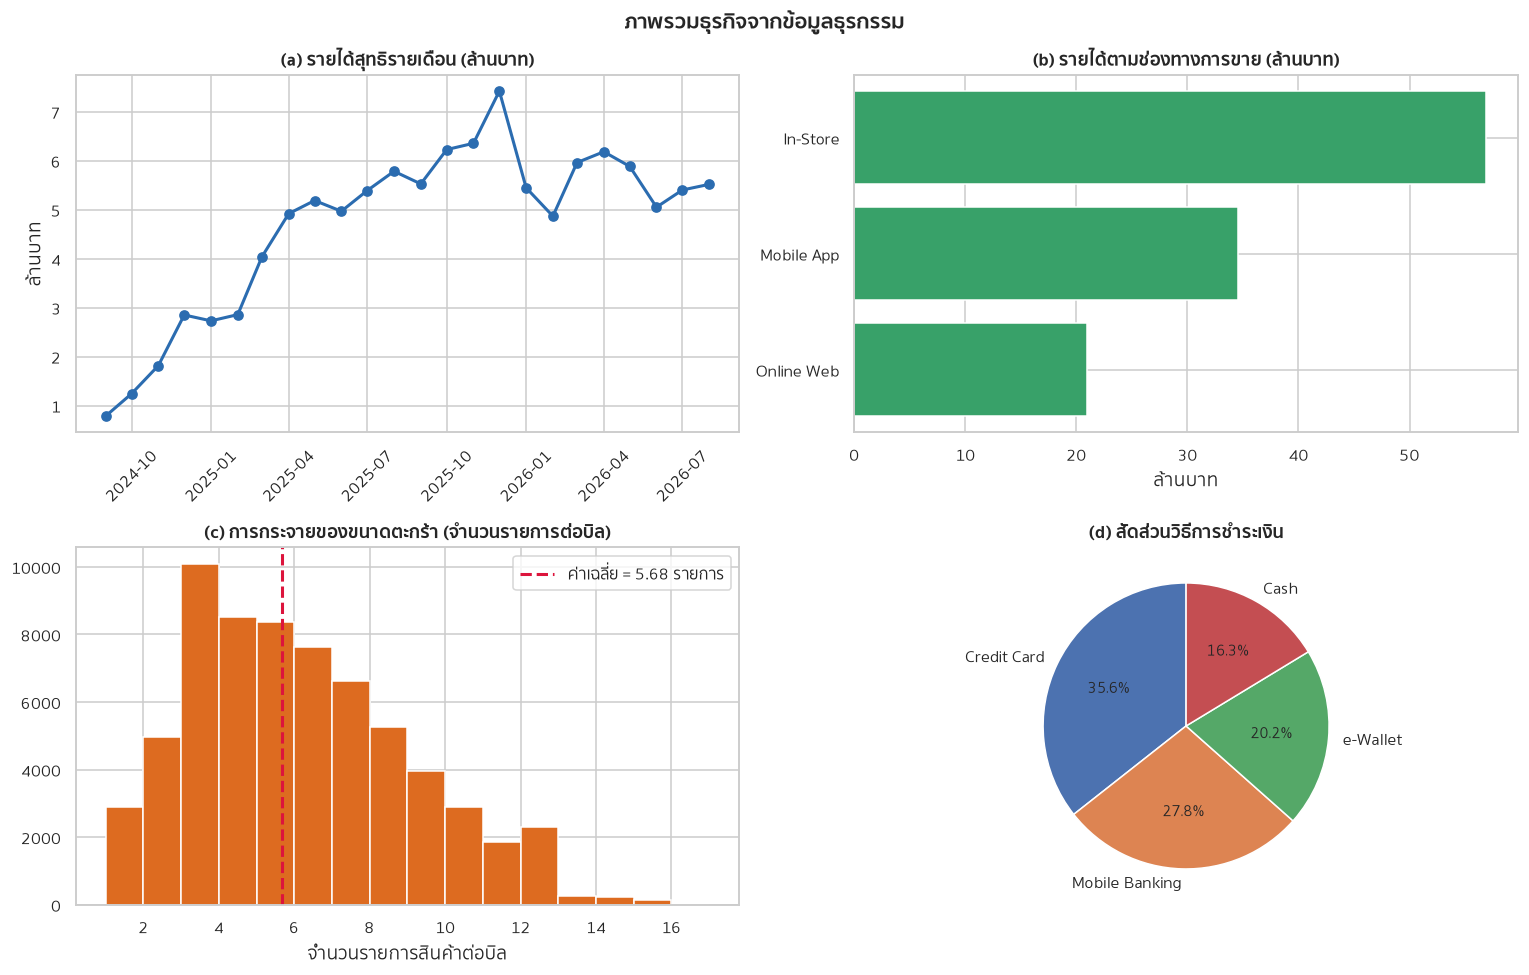

ขนาดตะกร้าเฉลี่ย : 5.68 รายการ/บิล
มูลค่าเฉลี่ยต่อบิล: 1,704.31 บาท
รายได้รวม        : 112.40 ล้านบาท


In [11]:
# Work on de-duplicated purchases for EDA so charts are not distorted by duplicate rows.
# (Full cleaning happens in §3; this is just enough to make the exploration honest.)
tx_eda = transactions_raw.drop_duplicates("transaction_id")
tx_eda = tx_eda[tx_eda.is_return == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Monthly net revenue - is the business growing, flat, or declining?
monthly = (tx_eda.set_index("transaction_date")
           .net_amount.resample("MS").sum().div(1e6))
axes[0, 0].plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#2b6cb0")
axes[0, 0].set_title("(a) รายได้สุทธิรายเดือน (ล้านบาท)")
axes[0, 0].set_ylabel("ล้านบาท")
axes[0, 0].tick_params(axis="x", rotation=45)

# (b) Revenue by channel
ch = tx_eda.groupby("channel").net_amount.sum().div(1e6).sort_values()
axes[0, 1].barh(ch.index, ch.values, color="#38a169")
axes[0, 1].set_title("(b) รายได้ตามช่องทางการขาย (ล้านบาท)")
axes[0, 1].set_xlabel("ล้านบาท")

# (c) Basket size distribution - the metric business question 1 wants to move
axes[1, 0].hist(tx_eda.n_items, bins=range(1, int(tx_eda.n_items.max()) + 2),
                color="#dd6b20", edgecolor="white")
axes[1, 0].axvline(tx_eda.n_items.mean(), color="crimson", linestyle="--", linewidth=2,
                   label=f"ค่าเฉลี่ย = {tx_eda.n_items.mean():.2f} รายการ")
axes[1, 0].set_title("(c) การกระจายของขนาดตะกร้า (จำนวนรายการต่อบิล)")
axes[1, 0].set_xlabel("จำนวนรายการสินค้าต่อบิล")
axes[1, 0].legend()

# (d) Payment method mix
pm = tx_eda.payment_method.value_counts()
axes[1, 1].pie(pm.values, labels=pm.index, autopct="%1.1f%%", startangle=90,
               colors=sns.color_palette("deep", len(pm)))
axes[1, 1].set_title("(d) สัดส่วนวิธีการชำระเงิน")

fig.suptitle("ภาพรวมธุรกิจจากข้อมูลธุรกรรม", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f01_business_overview")
plt.show()

rv("eda_mean_basket_items", round(float(tx_eda.n_items.mean()), 2))
rv("eda_median_basket_items", float(tx_eda.n_items.median()))
rv("eda_mean_basket_value", round(float(tx_eda.net_amount.mean()), 2))
rv("eda_total_revenue_thb", round(float(tx_eda.net_amount.sum()), 2))
rv("eda_top_channel", str(ch.idxmax()))
print(f"ขนาดตะกร้าเฉลี่ย : {tx_eda.n_items.mean():.2f} รายการ/บิล")
print(f"มูลค่าเฉลี่ยต่อบิล: {tx_eda.net_amount.mean():,.2f} บาท")
print(f"รายได้รวม        : {tx_eda.net_amount.sum()/1e6:,.2f} ล้านบาท")

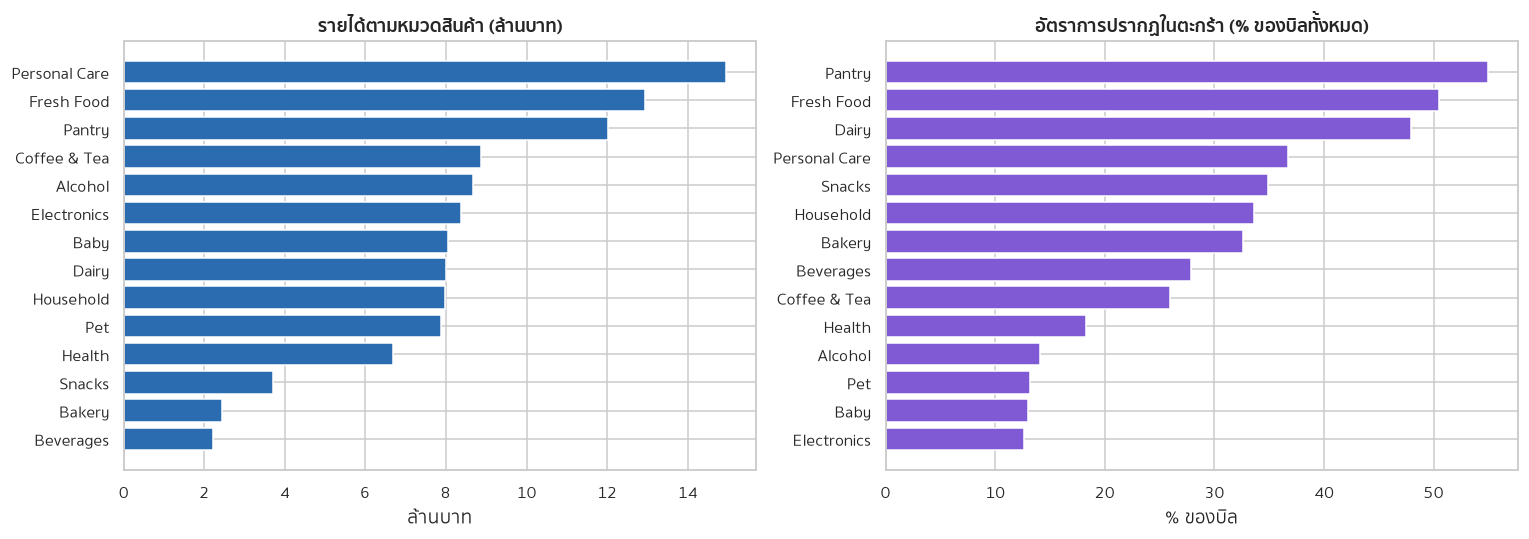

,revenue,units,baskets,basket_penetration
category,,,,
Personal Care,"14,954,005","70,993","24,234",36.7%
Fresh Food,"12,949,546","105,530","33,317",50.5%
Pantry,"12,009,933","103,672","36,231",54.9%
Coffee & Tea,"8,876,251","45,229","17,103",25.9%
Alcohol,"8,677,367","15,131","9,271",14.1%
Electronics,"8,382,630","14,052","8,351",12.7%
Baby,"8,054,466","23,246","8,545",13.0%
Dairy,"7,999,031","82,194","31,601",47.9%
Household,"7,971,656","53,297","22,158",33.6%


In [12]:
# Category performance - which departments drive revenue, and how often do they appear in baskets?
items_eda = items_raw[items_raw.transaction_id.isin(set(tx_eda.transaction_id))]
items_cat = items_eda.merge(products_raw, on="product_id")

cat_stats = (items_cat.groupby("category")
             .agg(revenue=("line_amount", "sum"),
                  units=("quantity", "sum"),
                  baskets=("transaction_id", "nunique"))
             .assign(basket_penetration=lambda d: d.baskets / tx_eda.transaction_id.nunique())
             .sort_values("revenue", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cat_stats.index[::-1], cat_stats.revenue.values[::-1] / 1e6, color="#2b6cb0")
axes[0].set_title("รายได้ตามหมวดสินค้า (ล้านบาท)")
axes[0].set_xlabel("ล้านบาท")

pen = cat_stats.basket_penetration.sort_values()
axes[1].barh(pen.index, pen.values * 100, color="#805ad5")
axes[1].set_title("อัตราการปรากฏในตะกร้า (% ของบิลทั้งหมด)")
axes[1].set_xlabel("% ของบิล")

fig.tight_layout()
save_fig(fig, "f02_category_performance")
plt.show()

rv("eda_n_categories", int(cat_stats.shape[0]))
rv("eda_top_category_revenue", str(cat_stats.index[0]))
rv("eda_top_category_penetration", str(pen.index[-1]))
rv("eda_top_category_penetration_pct", round(float(pen.iloc[-1]) * 100, 1))
save_table(cat_stats.reset_index(), "t04_category_stats")
cat_stats.style.format({"revenue": "{:,.0f}", "units": "{:,.0f}",
                        "baskets": "{:,.0f}", "basket_penetration": "{:.1%}"})

## 2.4 ความเบ้ของ RFM — ข้อค้นพบที่กำหนดวิธีเตรียมข้อมูล

ก่อนทำ clustering ต้องดูรูปร่างการกระจายของตัวแปรก่อน เพราะ K-Means ใช้ระยะทางแบบยุคลิด
ซึ่งอ่อนไหวต่อค่าสุดโต่งอย่างมาก กราฟด้านล่างเป็น**หลักฐานเชิงประจักษ์**ที่ใช้ตัดสินใจว่าต้อง log-transform หรือไม่

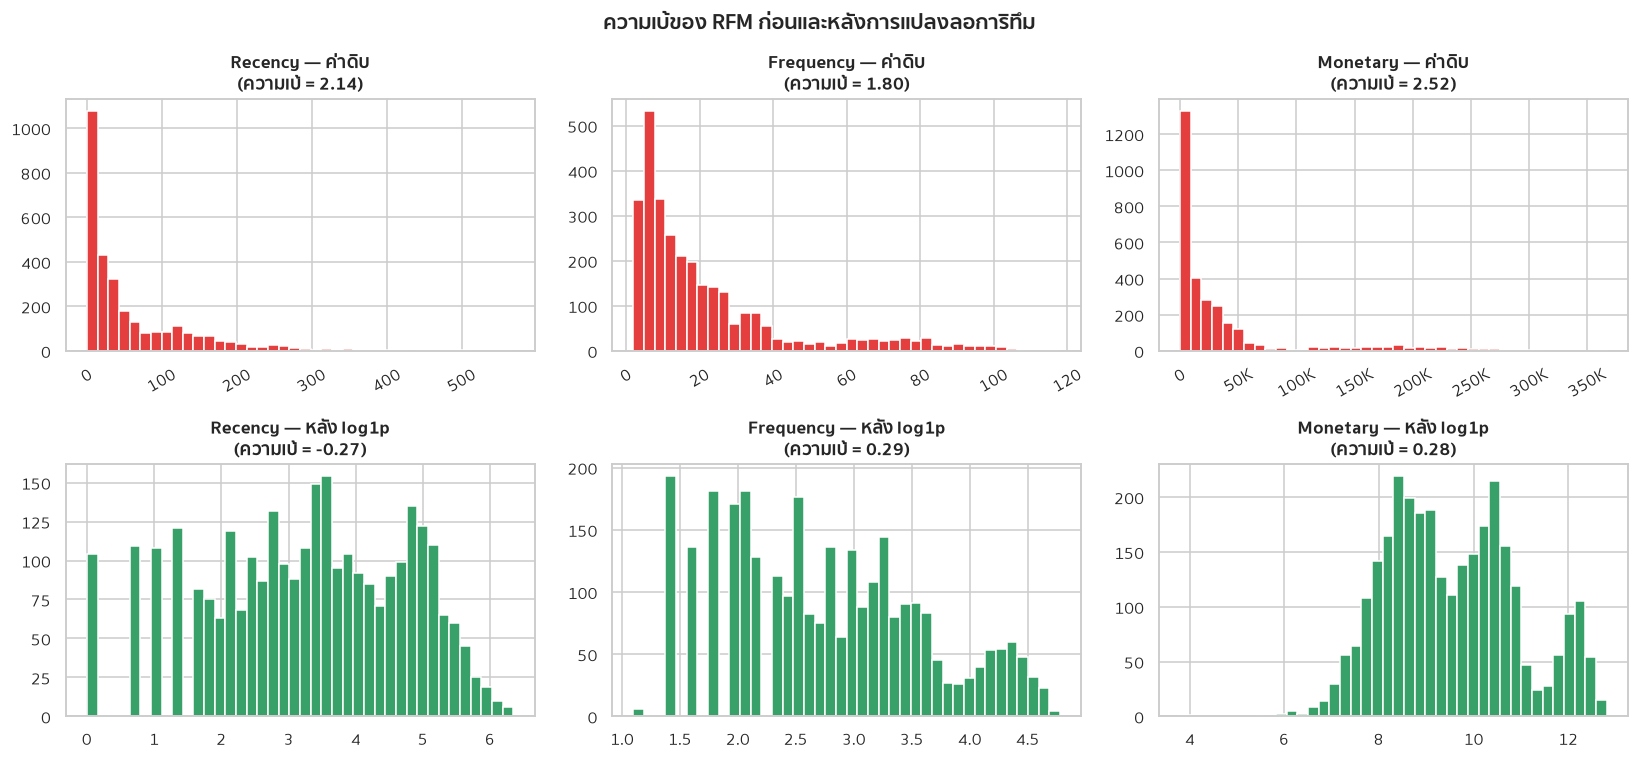

ยิ่งค่าความเบ้ใกล้ 0 ยิ่งใกล้การแจกแจงปกติ ซึ่งเหมาะกับอัลกอริทึมที่ใช้ระยะทาง เช่น K-Means


,ตัวแปร,ความเบ้ (ค่าดิบ),ความเบ้ (หลัง log1p)
0,Recency,2.141,-0.266
1,Frequency,1.798,0.294
2,Monetary,2.520,0.282


In [13]:
# Quick RFM (full version built in §3) purely to inspect distribution shape
_g = tx_eda.groupby("customer_id")
rfm_peek = pd.DataFrame({
    "Recency": (REFERENCE_DATE - _g.transaction_date.max()).dt.days,
    "Frequency": _g.size(),
    "Monetary": _g.net_amount.sum(),
})

from scipy.stats import skew

from matplotlib.ticker import FuncFormatter


def compact_number(x, _pos):
    # Render large axis values compactly so tick labels do not run into each other
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"


fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    s_raw = float(skew(rfm_peek[col]))
    axes[0, i].hist(rfm_peek[col], bins=40, color="#e53e3e", edgecolor="white")
    axes[0, i].set_title(f"{col} — ค่าดิบ\n(ความเบ้ = {s_raw:.2f})")
    axes[0, i].xaxis.set_major_formatter(FuncFormatter(compact_number))
    axes[0, i].tick_params(axis="x", labelrotation=30)

    logged = np.log1p(rfm_peek[col])
    s_log = float(skew(logged))
    axes[1, i].hist(logged, bins=40, color="#38a169", edgecolor="white")
    axes[1, i].set_title(f"{col} — หลัง log1p\n(ความเบ้ = {s_log:.2f})")

    rv(f"skew_{col.lower()}_raw", round(s_raw, 3))
    rv(f"skew_{col.lower()}_log", round(s_log, 3))

fig.suptitle("ความเบ้ของ RFM ก่อนและหลังการแปลงลอการิทึม", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f03_rfm_skewness")
plt.show()

skew_tbl = pd.DataFrame({
    "ตัวแปร": ["Recency", "Frequency", "Monetary"],
    "ความเบ้ (ค่าดิบ)": [REPORT_VALUES[f"skew_{c}_raw"]["value"] for c in ["recency", "frequency", "monetary"]],
    "ความเบ้ (หลัง log1p)": [REPORT_VALUES[f"skew_{c}_log"]["value"] for c in ["recency", "frequency", "monetary"]],
})
save_table(skew_tbl, "t05_rfm_skewness")
print("ยิ่งค่าความเบ้ใกล้ 0 ยิ่งใกล้การแจกแจงปกติ ซึ่งเหมาะกับอัลกอริทึมที่ใช้ระยะทาง เช่น K-Means")
skew_tbl

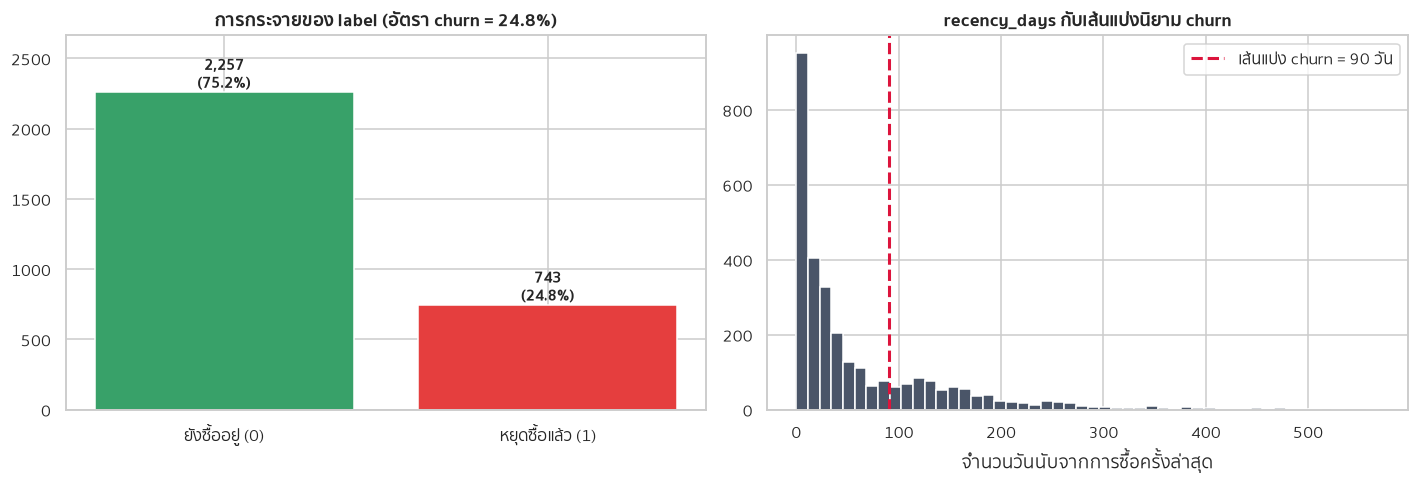

label ตรงกับนิยาม 'recency_days > 90' ทุกแถว: True
ถ้าทายว่าไม่มีใคร churn เลย จะได้ Accuracy = 75.2% ซึ่งสูงแต่ไร้ประโยชน์ -> จึงต้องใช้ PR-AUC และ Recall แทน


In [14]:
# The churn label: how imbalanced is it? This drives the choice of evaluation metric.
churn_rate = float(churn_raw.churn.mean())
rv("churn_rate", round(churn_rate, 4))
rv("churn_n_positive", int(churn_raw.churn.sum()))
rv("churn_n_negative", int((churn_raw.churn == 0).sum()))
rv("churn_majority_baseline_accuracy", round(1 - churn_rate, 4),
   "Accuracy ที่ได้จากการทายว่าไม่มีใคร churn เลย - แสดงว่าทำไม Accuracy ใช้ไม่ได้")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts = churn_raw.churn.value_counts().sort_index()
axes[0].bar(["ยังซื้ออยู่ (0)", "หยุดซื้อแล้ว (1)"], counts.values,
            color=["#38a169", "#e53e3e"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(churn_raw):.1%})", ha="center", va="bottom", fontweight="bold")
axes[0].set_title(f"การกระจายของ label (อัตรา churn = {churn_rate:.1%})")
axes[0].set_ylim(0, counts.max() * 1.18)

axes[1].hist(churn_raw.recency_days, bins=50, color="#4a5568", edgecolor="white")
axes[1].axvline(CHURN_HORIZON_DAYS, color="crimson", linestyle="--", linewidth=2,
                label=f"เส้นแบ่ง churn = {CHURN_HORIZON_DAYS} วัน")
axes[1].set_title("recency_days กับเส้นแบ่งนิยาม churn")
axes[1].set_xlabel("จำนวนวันนับจากการซื้อครั้งล่าสุด")
axes[1].legend()

fig.tight_layout()
save_fig(fig, "f04_churn_balance")
plt.show()

# Verify the label is exactly reproducible from the definition (a trust check on the data)
label_check = (churn_raw.recency_days > CHURN_HORIZON_DAYS).astype(int)
matches = bool((label_check == churn_raw.churn).all())
rv("churn_label_reproducible", matches)
print(f"label ตรงกับนิยาม 'recency_days > {CHURN_HORIZON_DAYS}' ทุกแถว: {matches}")
print(f"ถ้าทายว่าไม่มีใคร churn เลย จะได้ Accuracy = {1-churn_rate:.1%} "
      f"ซึ่งสูงแต่ไร้ประโยชน์ -> จึงต้องใช้ PR-AUC และ Recall แทน")

---
# §3 Data Preparation

ทำความสะอาดข้อมูลตามปัญหาที่ตรวจพบใน §2.2 แล้วสร้างชุดข้อมูล 3 ชุดสำหรับ 3 โจทย์

| ชุด | ใช้กับ | มุมมอง | วันอ้างอิง |
|---|---|---|---|
| **A. Basket matrix** | โจทย์ 1 | 1 แถว = 1 บิล | ทั้งช่วง 24 เดือน |
| **B. Customer features** | โจทย์ 2 | 1 แถว = 1 ลูกค้า | 2026-08-31 |
| **C. Churn features** | โจทย์ 3 | 1 แถว = 1 ลูกค้า | **2026-06-01 เท่านั้น** |

> ชุด B และ C ต่างกันที่วันอ้างอิง ไม่ใช่ความผิดพลาด — ชุด B อธิบายลูกค้า ณ ปัจจุบัน
> ส่วนชุด C ต้องย้อนไปยืนที่วันตัดเพื่อไม่ให้เห็นอนาคต (ดู §1.4)

## 3.1 ทำความสะอาดข้อมูล

หลักการที่ยึด: **ซ่อมดีกว่าทิ้ง** — ทุกครั้งที่เป็นไปได้จะแก้ค่าให้ถูกต้องแทนการลบแถว
เพราะการลบแถวทำให้เสียข้อมูลลูกค้าจริงและอาจสร้างอคติ (เช่น ถ้าคนไม่กรอกรายได้มีพฤติกรรมต่างจากคนที่กรอก)

In [15]:
# ---------- customers ----------
customers = customers_raw.drop_duplicates(subset="customer_id", keep="first").copy()

# gender: 8 spellings of 2 values -> take first letter of the lower-cased string
customers["gender"] = (customers.gender.str.strip().str.lower().str[0]
                       .map({"m": "Male", "f": "Female"}))

# age: values above 100 are impossible for a retail member -> treat as missing, then impute
n_age_fixed = int((customers.age > 100).sum())
customers.loc[customers.age > 100, "age"] = np.nan
age_median = float(customers.age.median())
n_age_imputed = int(customers.age.isna().sum())
customers["age"] = customers.age.fillna(age_median)

# region / income_bracket: keep the missingness as its own category instead of dropping rows,
# because "did not disclose" may itself carry signal
n_region_unknown = int(customers.region.isna().sum())
n_income_unknown = int(customers.income_bracket.isna().sum())
customers["region"] = customers.region.fillna("Unknown")
customers["income_bracket"] = customers.income_bracket.fillna("Unknown")

rv("clean_customers_removed_dupes", len(customers_raw) - len(customers))
rv("clean_n_customers", len(customers))
rv("clean_age_impossible_fixed", n_age_fixed)
rv("clean_age_imputed_total", n_age_imputed)
rv("clean_age_median", round(age_median, 1))
rv("clean_region_unknown", n_region_unknown)
rv("clean_income_unknown", n_income_unknown)

print(f"customers: {len(customers_raw):,} -> {len(customers):,} แถว "
      f"(ตัดซ้ำออก {len(customers_raw)-len(customers)})")
print(f"  gender  : รวม 8 รูปแบบการสะกดเหลือ {sorted(customers.gender.unique())}")
print(f"  age     : แก้ค่าเป็นไปไม่ได้ {n_age_fixed} ราย, เติมค่าว่างรวม {n_age_imputed} ราย "
      f"ด้วยมัธยฐาน {age_median:.0f} ปี")
print(f"  region  : เติม 'Unknown' {n_region_unknown} ราย")
print(f"  income  : เติม 'Unknown' {n_income_unknown} ราย")

customers: 3,015 -> 3,000 แถว (ตัดซ้ำออก 15)
  gender  : รวม 8 รูปแบบการสะกดเหลือ ['Female', 'Male']
  age     : แก้ค่าเป็นไปไม่ได้ 8 ราย, เติมค่าว่างรวม 132 ราย ด้วยมัธยฐาน 34 ปี
  region  : เติม 'Unknown' 68 ราย
  income  : เติม 'Unknown' 182 ราย


In [16]:
# ---------- transactions ----------
transactions = transactions_raw.drop_duplicates(subset="transaction_id", keep="first").copy()
n_tx_dupes = len(transactions_raw) - len(transactions)

# Split purchases from returns. Returns carry negative amounts and would corrupt RFM,
# churn features and basket analysis alike - the data dictionary says to exclude them.
returns = transactions[transactions.is_return == 1].copy()
purchases = transactions[transactions.is_return == 0].copy()

rv("clean_tx_removed_dupes", n_tx_dupes)
rv("clean_n_purchases", len(purchases))
rv("clean_n_returns", len(returns))
rv("clean_return_value_thb", round(float(returns.net_amount.sum()), 2))

print(f"transactions: {len(transactions_raw):,} -> {len(transactions):,} แถว (ตัดซ้ำออก {n_tx_dupes})")
print(f"  แยกเป็น: การซื้อ {len(purchases):,} บิล | การคืนสินค้า {len(returns):,} บิล")
print(f"  มูลค่าการคืนรวม: {returns.net_amount.sum():,.2f} บาท (ติดลบตามที่คาดไว้)")
print(f"  -> ใช้เฉพาะ 'การซื้อ' ในทุกการวิเคราะห์ต่อจากนี้")

transactions: 66,999 -> 66,732 แถว (ตัดซ้ำออก 267)
  แยกเป็น: การซื้อ 65,950 บิล | การคืนสินค้า 782 บิล
  มูลค่าการคืนรวม: -228,344.42 บาท (ติดลบตามที่คาดไว้)
  -> ใช้เฉพาะ 'การซื้อ' ในทุกการวิเคราะห์ต่อจากนี้


In [17]:
# ---------- transaction_items ----------
# Keep only line items belonging to (de-duplicated, non-return) purchase baskets
items = items_raw[items_raw.transaction_id.isin(set(purchases.transaction_id))].copy()

# --- Quantity outliers ---
# Inspect the shape of the distribution BEFORE choosing a treatment.
observed = np.sort(items.quantity.unique())

# Find where the distribution breaks. Use the RATIO between consecutive observed values,
# not their absolute difference: on a long-tailed variable the largest absolute gap always
# lands out in the sparse tail (here 144 -> 180, a mere 1.25x step) rather than at the real
# boundary between plausible and implausible quantities.
ratios = observed[1:] / observed[:-1]
gap_idx = int(np.argmax(ratios))
legit_max = int(observed[gap_idx])
outlier_min = int(observed[gap_idx + 1])

abs_gap_idx = int(np.argmax(np.diff(observed)))

print("การกระจายของ quantity (นับตามค่า):")
print(items.quantity.value_counts().sort_index().to_string())
print()
print(f"รอยแยกที่ชัดที่สุด (วัดด้วยอัตราส่วน): {legit_max} -> {outlier_min} ชิ้น "
      f"= กระโดด {outlier_min/legit_max:.1f} เท่า")
print(f"เทียบกับถ้าวัดด้วยผลต่างสัมบูรณ์จะได้ {observed[abs_gap_idx]} -> {observed[abs_gap_idx+1]} ชิ้น "
      f"(กระโดดแค่ {observed[abs_gap_idx+1]/observed[abs_gap_idx]:.2f} เท่า)")
print("ซึ่งเป็นจุดที่อยู่ในหางของการแจกแจงอยู่แล้ว ไม่ใช่เส้นแบ่งระหว่างค่าปกติกับค่าผิดปกติ")
print()
print(f"-> ค่าตั้งแต่ {outlier_min} ชิ้นขึ้นไปมี {int((items.quantity >= outlier_min).sum())} แถว "
      f"ซึ่งตรงกับที่ DATA_DICTIONARY ระบุว่ามีราว 25 แถวที่ผิดปกติ")

การกระจายของ quantity (นับตามค่า):
quantity
1      158105
2      135153
3       59116
4       17229
5        3875
6         685
7          99
8          19
32          1
40          1
44          1
48          1
52          1
76          1
78          1
80          2
81          1
82          1
86          1
90          1
94          1
96          1
98          2
100         2
102         1
105         1
116         1
144         1
180         1
216         1

รอยแยกที่ชัดที่สุด (วัดด้วยอัตราส่วน): 8 -> 32 ชิ้น = กระโดด 4.0 เท่า
เทียบกับถ้าวัดด้วยผลต่างสัมบูรณ์จะได้ 144 -> 180 ชิ้น (กระโดดแค่ 1.25 เท่า)
ซึ่งเป็นจุดที่อยู่ในหางของการแจกแจงอยู่แล้ว ไม่ใช่เส้นแบ่งระหว่างค่าปกติกับค่าผิดปกติ

-> ค่าตั้งแต่ 32 ชิ้นขึ้นไปมี 25 แถว ซึ่งตรงกับที่ DATA_DICTIONARY ระบุว่ามีราว 25 แถวที่ผิดปกติ


In [18]:
# The two groups are separated by an empty band, so they are not two ends of one
# continuum - they are different populations. That also rules out a percentile cap:
# the 99.5th percentile sits at just 5 units and would flatten hundreds of ordinary
# purchases while barely touching the real problem.
#
# Winsorise the implausible group down to the largest plausible value instead of
# deleting the rows, because the item WAS bought - only the recorded count is wrong,
# and deleting the line would silently shrink a real basket.
p995 = float(items.quantity.quantile(0.995))
n_would_hit_p995 = int((items.quantity > p995).sum())

qty_cap = float(legit_max)
n_capped = int((items.quantity > qty_cap).sum())
items["quantity_raw"] = items.quantity
items["quantity"] = items.quantity.clip(upper=qty_cap)

rv("clean_qty_legit_max", legit_max)
rv("clean_qty_outlier_min", outlier_min)
rv("clean_qty_cap", qty_cap)
rv("clean_qty_n_capped", n_capped)
rv("clean_qty_max_before", int(items.quantity_raw.max()))
rv("clean_qty_max_after", float(items.quantity.max()))
rv("clean_qty_p995", round(p995, 2))
rv("clean_qty_n_would_hit_p995", n_would_hit_p995,
   "จำนวนแถวที่จะถูกกระทบถ้าใช้เปอร์เซ็นไทล์ 99.5 - เหตุผลที่ไม่ใช้วิธีนั้น")
rv("clean_n_items", len(items))

print(f"transaction_items: เหลือ {len(items):,} แถว (เฉพาะบิลที่เป็นการซื้อ)")
print(f"  ค่าปกติสูงสุด    : {legit_max} ชิ้น")
print(f"  ค่าผิดปกติต่ำสุด : {outlier_min} ชิ้น")
print(f"  -> จำกัดค่าลงมาที่ {qty_cap:.0f} ชิ้น กระทบ {n_capped} แถว ({n_capped/len(items):.4%} ของทั้งหมด)")
print(f"  quantity สูงสุด  : {items.quantity_raw.max()} -> {items.quantity.max():.0f} ชิ้น")
print()
print(f"  เทียบวิธีที่ไม่ได้เลือก: เปอร์เซ็นไทล์ 99.5 = {p995:.0f} ชิ้น จะกระทบถึง {n_would_hit_p995:,} แถว")
print(f"  ซึ่งเกือบทั้งหมดเป็นการซื้อปกติ ไม่ใช่ค่าผิดปกติ")

transaction_items: เหลือ 374,306 แถว (เฉพาะบิลที่เป็นการซื้อ)
  ค่าปกติสูงสุด    : 8 ชิ้น
  ค่าผิดปกติต่ำสุด : 32 ชิ้น
  -> จำกัดค่าลงมาที่ 8 ชิ้น กระทบ 25 แถว (0.0067% ของทั้งหมด)
  quantity สูงสุด  : 216 -> 8 ชิ้น

  เทียบวิธีที่ไม่ได้เลือก: เปอร์เซ็นไทล์ 99.5 = 5 ชิ้น จะกระทบถึง 828 แถว
  ซึ่งเกือบทั้งหมดเป็นการซื้อปกติ ไม่ใช่ค่าผิดปกติ


In [19]:
# ---------- master analysis frame ----------
# One row per line item, enriched with product, basket and customer context.
items_full = (items
              .merge(products_raw, on="product_id", how="left")
              .merge(purchases[["transaction_id", "customer_id", "transaction_date",
                                "channel", "store_id", "payment_method"]],
                     on="transaction_id", how="left"))

assert items_full.customer_id.notna().all(), "line items ที่หา basket ไม่เจอ"
assert items_full.product_name.notna().all(), "line items ที่หา product ไม่เจอ"

rv("clean_n_items_full", len(items_full))
print(f"ตารางหลักสำหรับวิเคราะห์: {len(items_full):,} แถว x {items_full.shape[1]} คอลัมน์")
items_full.head(3)

ตารางหลักสำหรับวิเคราะห์: 374,306 แถว x 16 คอลัมน์


,transaction_id,line_no,product_id,quantity,unit_price_x,discount_amount,line_amount,quantity_raw,product_name,category,unit_price_y,customer_id,transaction_date,channel,store_id,payment_method
0,T200000,1,P1013,2,50.71,0.00,101.42,2,Spaghetti Pasta,Pantry,49,C10001,2025-08-10,Mobile App,ONLINE,e-Wallet
1,T200000,2,P1014,3,77.06,0.00,231.18,3,Pasta Sauce,Pantry,79,C10001,2025-08-10,Mobile App,ONLINE,e-Wallet
2,T200000,3,P1008,2,191.18,114.71,267.65,2,Parmesan Cheese,Dairy,189,C10001,2025-08-10,Mobile App,ONLINE,e-Wallet


## 3.2 ชุด A — Basket Matrix (สำหรับโจทย์ที่ 1)

หนึ่งตะกร้า = หนึ่ง `transaction_id` · หนึ่งไอเทม = `product_name`
ใช้ `TransactionEncoder` ของ `mlxtend` แปลงเป็นตาราง boolean แบบ one-hot ตามที่เรียนในสัปดาห์ที่ 9

In [20]:
from mlxtend.preprocessing import TransactionEncoder

# Build the list-of-baskets structure that TransactionEncoder expects
basket_lists = (items_full.groupby("transaction_id").product_name
                .apply(lambda s: list(set(s))).tolist())

te = TransactionEncoder()
basket_matrix = pd.DataFrame(te.fit_transform(basket_lists), columns=te.columns_)

# A category-level view as well: useful for department-level merchandising strategy
cat_lists = (items_full.groupby("transaction_id").category
             .apply(lambda s: list(set(s))).tolist())
te_cat = TransactionEncoder()
basket_matrix_cat = pd.DataFrame(te_cat.fit_transform(cat_lists), columns=te_cat.columns_)

rv("basket_n_transactions", int(basket_matrix.shape[0]))
rv("basket_n_products", int(basket_matrix.shape[1]))
rv("basket_n_categories", int(basket_matrix_cat.shape[1]))
rv("basket_mean_distinct_items", round(float(basket_matrix.sum(axis=1).mean()), 2))

print(f"Basket matrix (ระดับสินค้า) : {basket_matrix.shape[0]:,} บิล x {basket_matrix.shape[1]} สินค้า")
print(f"Basket matrix (ระดับหมวด)  : {basket_matrix_cat.shape[0]:,} บิล x {basket_matrix_cat.shape[1]} หมวด")
print(f"จำนวนสินค้าต่างชนิดเฉลี่ยต่อบิล: {basket_matrix.sum(axis=1).mean():.2f} ชนิด")
basket_matrix.iloc[:3, :6]

Basket matrix (ระดับสินค้า) : 65,950 บิล x 89 สินค้า
Basket matrix (ระดับหมวด)  : 65,950 บิล x 14 หมวด
จำนวนสินค้าต่างชนิดเฉลี่ยต่อบิล: 5.68 ชนิด


,Air Freshener,Apple 1kg,Baby Food Puree,Baby Formula,Baby Lotion,Baby Wipes
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False


## 3.3 ชุด B — Customer Features (สำหรับโจทย์ที่ 2)

RFM มาตรฐาน + อีก 5 มิติเชิงพฤติกรรม คำนวณ ณ วันอ้างอิง **2026-08-31**

In [21]:
def build_customer_features(purchase_df, item_df, as_of):
    # Build one row per customer describing purchase behaviour up to `as_of`.
    p = purchase_df[purchase_df.transaction_date <= as_of]
    it = item_df[item_df.transaction_date <= as_of]
    g = p.groupby("customer_id")

    feat = pd.DataFrame({
        # --- classic RFM ---
        "recency": (as_of - g.transaction_date.max()).dt.days,
        "frequency": g.size(),
        "monetary": g.net_amount.sum(),
        # --- extended behavioural features ---
        "avg_order_value": g.net_amount.mean(),
        "tenure_days": (as_of - g.transaction_date.min()).dt.days,
        "basket_depth": g.total_units.mean(),
        "items_per_basket": g.n_items.mean(),
    })

    # Discount sensitivity: what share of gross spend came off as promotion?
    gross = g.gross_amount.sum()
    feat["discount_ratio"] = (g.discount_amount.sum() / gross.where(gross > 0)).fillna(0.0)

    # Category breadth: how many different departments does this customer shop?
    feat["category_breadth"] = it.groupby("customer_id").category.nunique()

    # Channel diversity: single-channel vs omni-channel shopper
    feat["channel_diversity"] = g.channel.nunique()

    return feat.fillna(0.0)


customer_features = build_customer_features(purchases, items_full, REFERENCE_DATE)

rv("segfeat_n_customers", int(len(customer_features)))
rv("segfeat_n_features", int(customer_features.shape[1]))
rv("segfeat_feature_names", customer_features.columns.tolist())
save_table(customer_features.reset_index(), "t06_customer_features")

print(f"Customer features: {customer_features.shape[0]:,} ลูกค้า x {customer_features.shape[1]} ฟีเจอร์")
customer_features.describe().T.style.format("{:,.2f}")

Customer features: 3,000 ลูกค้า x 10 ฟีเจอร์


,count,mean,std,min,25%,50%,75%,max
recency,"3,000.00",61.28,80.07,0.00,8.00,28.00,90.00,569.00
frequency,"3,000.00",21.98,22.10,2.00,7.00,14.00,28.00,118.00
monetary,"3,000.00","37,466.51","60,925.37",43.44,"4,751.33","12,040.30","35,986.26","366,757.53"
avg_order_value,"3,000.00","1,179.40",712.01,21.72,623.69,"1,030.77","1,531.16","4,181.79"
tenure_days,"3,000.00",448.04,193.33,36.00,310.00,485.00,609.00,729.00
basket_depth,"3,000.00",8.41,3.40,1.00,5.77,7.80,10.65,20.67
items_per_basket,"3,000.00",4.50,1.80,1.00,3.07,4.20,5.67,10.51
discount_ratio,"3,000.00",0.04,0.03,0.00,0.02,0.03,0.06,0.30
category_breadth,"3,000.00",11.36,2.76,2.00,9.00,12.00,14.00,14.00
channel_diversity,"3,000.00",2.24,0.79,1.00,2.00,2.00,3.00,3.00


## 3.4 ชุด C — Churn Features (สำหรับโจทย์ที่ 3) ⚠️ จุดที่ต้องระวังการรั่วไหลของข้อมูล

ฟีเจอร์ทุกตัวคำนวณจากข้อมูล **ถึง 2026-06-01 เท่านั้น** และไม่แตะคอลัมน์ต้องห้ามใน `churn_labels.csv`

**ตระกูลฟีเจอร์ที่สร้าง**

| ตระกูล | ตัวแปร | เหตุผลเชิงธุรกิจ |
|---|---|---|
| RFM ณ วันตัด | recency, frequency, monetary, AOV | ฐานพฤติกรรมการซื้อ |
| **จังหวะการซื้อ** | ระยะห่างเฉลี่ยระหว่างบิล + ส่วนเบี่ยงเบน + อัตราส่วนช่องว่างล่าสุด | ลูกค้าแต่ละคนมีจังหวะของตัวเอง คนที่ซื้อทุก 7 วันแล้วหายไป 30 วัน น่ากังวลกว่าคนที่ซื้อทุก 60 วันแล้วหายไป 30 วัน |
| **แนวโน้ม** | จำนวนบิลใน 30/90/180/365 วัน + อัตราส่วนระหว่างช่วง | จับ "กำลังจะหาย" ไม่ใช่แค่ "หายแล้ว" ซึ่งเป็นหัวใจของการเตือนล่วงหน้า |
| ความผูกพัน | ความหลากหลายหมวด/ช่องทาง/ร้าน | ลูกค้าที่ผูกพันหลายมิติย้ายไปคู่แข่งยากกว่า |
| การพึ่งส่วนลด | สัดส่วนส่วนลดต่อยอดซื้อ | ลูกค้าที่ซื้อเมื่อมีโปรเท่านั้น มักไม่ภักดี |
| **บริการลูกค้า** | จำนวนเรื่องร้องเรียน, CSAT เฉลี่ย, เรื่องที่ยังไม่ปิด | ประสบการณ์แย่เป็นตัวเร่งการเลิกใช้ที่คลาสสิก |
| ข้อมูลประชากร | อายุ, เพศ, ภูมิภาค, ระดับสมาชิก, รายได้ | บริบทพื้นฐานของลูกค้า |

In [22]:
def build_churn_features(purchase_df, item_df, ticket_df, customer_df, cutoff):
    # Every feature below is computed strictly from data on or before `cutoff`.
    p = purchase_df[purchase_df.transaction_date <= cutoff].copy()
    it = item_df[item_df.transaction_date <= cutoff]
    tk = ticket_df[ticket_df.ticket_date <= cutoff]
    g = p.groupby("customer_id")

    f = pd.DataFrame({
        "recency": (cutoff - g.transaction_date.max()).dt.days,
        "frequency": g.size(),
        "monetary": g.net_amount.sum(),
        "avg_order_value": g.net_amount.mean(),
        "std_order_value": g.net_amount.std(),
        "tenure_days": (cutoff - g.transaction_date.min()).dt.days,
        "basket_depth": g.total_units.mean(),
        "items_per_basket": g.n_items.mean(),
        "channel_diversity": g.channel.nunique(),
        "store_diversity": g.store_id.nunique(),
    })

    # --- Purchase rhythm: personalised gap statistics ---
    p_sorted = p.sort_values(["customer_id", "transaction_date"])
    gaps = p_sorted.groupby("customer_id").transaction_date.diff().dt.days
    gap_stats = gaps.groupby(p_sorted.customer_id).agg(["mean", "std", "max"])
    f["gap_mean"] = gap_stats["mean"]
    f["gap_std"] = gap_stats["std"]
    f["gap_max"] = gap_stats["max"]
    # Is the current silence unusual FOR THIS CUSTOMER? (>1 means quieter than their own normal)
    f["recency_vs_gap"] = f.recency / f.gap_mean.replace(0, np.nan)

    # --- Trend: activity in recent windows, and whether it is accelerating or decaying ---
    for w in (30, 90, 180, 365):
        f[f"n_tx_{w}d"] = (p[p.transaction_date > cutoff - pd.Timedelta(days=w)]
                           .groupby("customer_id").size().reindex(f.index).fillna(0))
        f[f"spend_{w}d"] = (p[p.transaction_date > cutoff - pd.Timedelta(days=w)]
                            .groupby("customer_id").net_amount.sum().reindex(f.index).fillna(0))
    # Ratio of the most recent 90 days against the 90 days before that: <1 means slowing down
    f["trend_90_over_prev90"] = f.n_tx_90d / (f.n_tx_180d - f.n_tx_90d + 1)
    f["trend_180_over_prev180"] = f.n_tx_180d / (f.n_tx_365d - f.n_tx_180d + 1)

    # --- Discount dependence ---
    gross = g.gross_amount.sum()
    f["discount_ratio"] = (g.discount_amount.sum() / gross.where(gross > 0)).fillna(0.0)

    # --- Category engagement ---
    f["category_breadth"] = it.groupby("customer_id").category.nunique()

    # --- Support experience ---
    tg = tk.groupby("customer_id")
    f["n_tickets"] = tg.size().reindex(f.index).fillna(0)
    f["avg_satisfaction"] = tg.satisfaction_score.mean().reindex(f.index)
    f["n_unresolved_tickets"] = ((1 - tk.is_resolved).groupby(tk.customer_id).sum()
                                 .reindex(f.index).fillna(0))

    # --- Demographics (known at cutoff; signup_date precedes the window) ---
    demo = customer_df.set_index("customer_id")
    f["age"] = demo.age.reindex(f.index)
    f["days_since_signup"] = (cutoff - demo.signup_date.reindex(f.index)).dt.days
    f["marketing_optin"] = demo.marketing_optin.reindex(f.index)
    f["has_mobile_app"] = demo.has_mobile_app.reindex(f.index)
    for col in ("gender", "region", "membership_tier", "income_bracket", "preferred_channel"):
        f[col] = demo[col].reindex(f.index)
    f["city_tier"] = demo.city_tier.reindex(f.index)

    return f


churn_features = build_churn_features(purchases, items_full, tickets_raw, customers, FEATURE_CUTOFF)
print(f"Churn features: {churn_features.shape[0]:,} ลูกค้า x {churn_features.shape[1]} ฟีเจอร์")
churn_features.head(3)

Churn features: 2,876 ลูกค้า x 39 ฟีเจอร์


,recency,frequency,monetary,avg_order_value,std_order_value,tenure_days,basket_depth,items_per_basket,channel_diversity,store_diversity,gap_mean,gap_std,gap_max,recency_vs_gap,n_tx_30d,spend_30d,n_tx_90d,spend_90d,n_tx_180d,spend_180d,n_tx_365d,spend_365d,trend_90_over_prev90,trend_180_over_prev180,discount_ratio,category_breadth,n_tickets,avg_satisfaction,n_unresolved_tickets,age,days_since_signup,marketing_optin,has_mobile_app,gender,region,membership_tier,income_bracket,preferred_channel,city_tier
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
C10001,89,7,7401.33,1057.332857,499.719536,295,9.714286,5.000000,1,1,34.333333,29.991110,83.0,2.592233,0.0,0.00,1.0,1876.84,2.0,3403.37,7.0,7401.33,0.5,0.333333,0.039533,11,0.0,NaN,0.0,42.0,308,1,1,Male,South,Gold,>120k,Mobile App,3
C10002,1,7,3045.75,435.107143,259.401469,204,6.000000,3.142857,1,7,33.833333,29.654117,72.0,0.029557,1.0,264.23,5.0,1867.34,6.0,2664.22,7.0,3045.75,2.5,3.000000,0.094938,10,1.0,4.0,0.0,36.0,264,1,0,Female,East,Silver,20-40k,In-Store,1
C10003,63,4,3110.29,777.572500,688.655196,320,3.250000,1.750000,2,4,85.666667,7.234178,94.0,0.735409,0.0,0.00,1.0,1716.95,2.0,2322.13,4.0,3110.29,0.5,0.666667,0.000000,5,0.0,NaN,0.0,35.0,380,0,0,Female,Northeast,Bronze,70-120k,In-Store,2


In [23]:
# ============================================================================
# LEAKAGE GUARD - automated assertions, not just good intentions.
# If any of these fail the notebook stops here rather than producing a
# beautiful-looking but invalid result.
# ============================================================================
FORBIDDEN_COLUMNS = {"recency_days", "last_purchase_date", "total_transactions", "churn"}

# 1) No forbidden outcome column may appear among the features
leaked_cols = FORBIDDEN_COLUMNS & set(churn_features.columns)
assert not leaked_cols, f"LEAKAGE: พบคอลัมน์ต้องห้ามในชุดฟีเจอร์ -> {leaked_cols}"

# 2) No source row used to build features may fall after the cutoff
assert purchases[purchases.transaction_date <= FEATURE_CUTOFF].transaction_date.max() <= FEATURE_CUTOFF
assert items_full[items_full.transaction_date <= FEATURE_CUTOFF].transaction_date.max() <= FEATURE_CUTOFF
assert tickets_raw[tickets_raw.ticket_date <= FEATURE_CUTOFF].ticket_date.max() <= FEATURE_CUTOFF

# 3) Independent re-derivation: recency computed here must never be consistent with
#    the label's own recency (which is measured from a later reference date)
_lbl = churn_raw.set_index("customer_id")
_common = churn_features.index.intersection(_lbl.index)
_offset = (REFERENCE_DATE - FEATURE_CUTOFF).days
_expected_gap = (_lbl.loc[_common, "recency_days"] - churn_features.loc[_common, "recency"])
# For customers whose last purchase was before the cutoff, the gap must be exactly the
# distance between the two reference dates. Any other value means dates were mixed up.
_stable = _lbl.loc[_common, "last_purchase_date"] <= FEATURE_CUTOFF
assert (_expected_gap[_stable] == _offset).all(), "LEAKAGE: การคำนวณ recency ณ วันตัดไม่สอดคล้อง"

rv("leakage_guard_passed", True)
rv("leakage_forbidden_columns", sorted(FORBIDDEN_COLUMNS))
rv("leakage_feature_cutoff", str(FEATURE_CUTOFF.date()))
rv("leakage_reference_date", str(REFERENCE_DATE.date()))
rv("leakage_offset_days", int(_offset))

print("=" * 70)
print("ผ่านการตรวจสอบการรั่วไหลของข้อมูลทั้ง 3 ข้อ")
print("=" * 70)
print(f"  1. ไม่มีคอลัมน์ต้องห้าม {sorted(FORBIDDEN_COLUMNS)} ในชุดฟีเจอร์")
print(f"  2. ไม่มีข้อมูลต้นทางหลังวันตัด {FEATURE_CUTOFF.date()}")
print(f"  3. recency ที่คำนวณใหม่สอดคล้องกับ label พอดี {_offset} วัน "
      f"(= ระยะห่างระหว่างวันตัดกับวันอ้างอิง)")

ผ่านการตรวจสอบการรั่วไหลของข้อมูลทั้ง 3 ข้อ
  1. ไม่มีคอลัมน์ต้องห้าม ['churn', 'last_purchase_date', 'recency_days', 'total_transactions'] ในชุดฟีเจอร์
  2. ไม่มีข้อมูลต้นทางหลังวันตัด 2026-06-01
  3. recency ที่คำนวณใหม่สอดคล้องกับ label พอดี 91 วัน (= ระยะห่างระหว่างวันตัดกับวันอ้างอิง)


In [24]:
# --- Join features to the label and handle the "no purchase before cutoff" cohort ---
labels = churn_raw.set_index("customer_id").churn

modeling_df = labels.to_frame().join(churn_features, how="left")

# Customers with NO purchase at all in the feature window: every behavioural feature is
# undefined for them. They are flagged rather than silently imputed, because §5 reports
# results both with and without this cohort.
no_history_mask = modeling_df.frequency.isna()
n_no_history = int(no_history_mask.sum())
churn_rate_no_history = float(modeling_df.loc[no_history_mask, "churn"].mean()) if n_no_history else np.nan

modeling_df["has_purchase_history"] = (~no_history_mask).astype(int)

rv("model_n_rows", int(len(modeling_df)))
rv("cohort_no_history_n", n_no_history)
rv("cohort_no_history_churn_rate", round(churn_rate_no_history, 4))
rv("cohort_with_history_n", int((~no_history_mask).sum()))
rv("cohort_with_history_churn_rate",
   round(float(modeling_df.loc[~no_history_mask, "churn"].mean()), 4))

print(f"ชุดข้อมูลสำหรับสร้างโมเดล: {len(modeling_df):,} ลูกค้า")
print()
print(f"ลูกค้าที่ไม่มีประวัติซื้อก่อนวันตัด: {n_no_history} ราย "
      f"({n_no_history/len(modeling_df):.1%})")
print(f"  -> อัตรา churn ของกลุ่มนี้: {churn_rate_no_history:.1%}")
print(f"  -> อัตรา churn ของกลุ่มที่มีประวัติ: "
      f"{modeling_df.loc[~no_history_mask, 'churn'].mean():.1%}")
print()
print("ข้อสังเกต: กลุ่มแรกคือลูกค้าที่เพิ่งซื้อครั้งแรกหลังวันตัด จึงไม่มีทางเป็น churn ได้ตามนิยาม")
print("           §5.4 จะรายงานผลทั้งแบบรวมและแบบตัดกลุ่มนี้ออก")

ชุดข้อมูลสำหรับสร้างโมเดล: 3,000 ลูกค้า

ลูกค้าที่ไม่มีประวัติซื้อก่อนวันตัด: 124 ราย (4.1%)
  -> อัตรา churn ของกลุ่มนี้: 0.0%
  -> อัตรา churn ของกลุ่มที่มีประวัติ: 25.8%

ข้อสังเกต: กลุ่มแรกคือลูกค้าที่เพิ่งซื้อครั้งแรกหลังวันตัด จึงไม่มีทางเป็น churn ได้ตามนิยาม
           §5.4 จะรายงานผลทั้งแบบรวมและแบบตัดกลุ่มนี้ออก


In [25]:
# Split feature columns by type so the modelling pipeline can treat them correctly
TARGET = "churn"
CATEGORICAL = ["gender", "region", "membership_tier", "income_bracket", "preferred_channel"]
NUMERIC = [c for c in churn_features.columns if c not in CATEGORICAL]
FEATURE_COLS = NUMERIC + CATEGORICAL + ["has_purchase_history"]

rv("model_n_numeric_features", len(NUMERIC))
rv("model_n_categorical_features", len(CATEGORICAL))
rv("model_n_total_features", len(FEATURE_COLS))
rv("model_numeric_feature_names", NUMERIC)
rv("model_categorical_feature_names", CATEGORICAL)
save_table(modeling_df.reset_index(), "t07_churn_modeling_frame")

print(f"ฟีเจอร์เชิงตัวเลข : {len(NUMERIC)} ตัว")
print(f"ฟีเจอร์เชิงหมวดหมู่: {len(CATEGORICAL)} ตัว -> {CATEGORICAL}")
print(f"รวมทั้งหมด        : {len(FEATURE_COLS)} ตัว")

ฟีเจอร์เชิงตัวเลข : 34 ตัว
ฟีเจอร์เชิงหมวดหมู่: 5 ตัว -> ['gender', 'region', 'membership_tier', 'income_bracket', 'preferred_channel']
รวมทั้งหมด        : 40 ตัว


---
# §4 Modeling

---
## §4.1 โจทย์ที่ 1 — Increase Basket Size (Association Rule Mining)

> **คำถามผู้บริหาร:** *สินค้าใดมักถูกซื้อคู่กัน และควรนำมาจัดโปรโมชันร่วมกันเพื่อกระตุ้นยอดขายต่อบิล*

### ตัวชี้วัดที่ใช้ตัดสินกฎ

| ตัวชี้วัด | ความหมาย | ใช้ตอบคำถามว่า |
|---|---|---|
| **Support** | สัดส่วนบิลที่มีสินค้าชุดนี้ครบ | คุ้มที่จะทำโปรไหม? ถ้าเจอน้อยเกินก็ไม่มีผลต่อยอดขาย |
| **Confidence** | ซื้อ A แล้วซื้อ B ด้วยกี่ % | ความน่าเชื่อถือของกฎ **แต่ถูกหลอกด้วยสินค้าขายดีได้** |
| **Lift** | ซื้อ A แล้วโอกาสซื้อ B เพิ่มขึ้นกี่เท่า | **มีความสัมพันธ์จริงหรือแค่บังเอิญ** — Lift > 1 เท่านั้นจึงมีความหมาย |

**ค่าเริ่มต้นที่ใช้:** `min_support = 0.01` (กฎต้องปรากฏอย่างน้อย 1% ของบิล มิฉะนั้นเล็กเกินกว่าจะทำโปร)
และ `min_confidence = 0.3` ตามที่ `DATA_DICTIONARY.md` แนะนำ

In [26]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.3
MAX_LEN = 3  # rules of up to 3 items stay interpretable and actionable for merchandising

rv("ar_min_support", MIN_SUPPORT)
rv("ar_min_confidence", MIN_CONFIDENCE)
rv("ar_max_len", MAX_LEN)

# --- Benchmark: Apriori vs FP-Growth ---
# Both algorithms are guaranteed to return the SAME frequent itemsets; they differ only
# in how they search. Time each over several repeats, because a single run at this data
# size is dominated by noise.
N_REPEATS = 5


def time_miner(fn, **kwargs):
    fn(basket_matrix, **kwargs)  # warm-up: keep first-call overhead out of the comparison
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        out = fn(basket_matrix, **kwargs)
        times.append(time.perf_counter() - t0)
    return out, float(np.median(times)), float(np.std(times))


itemsets_apriori, time_apriori, sd_apriori = time_miner(
    apriori, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
itemsets_fp, time_fpgrowth, sd_fpgrowth = time_miner(
    fpgrowth, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)

# Verify the two algorithms really do agree - this is the point of the comparison
set_apriori = set(itemsets_apriori.itemsets.apply(frozenset))
set_fp = set(itemsets_fp.itemsets.apply(frozenset))
identical = set_apriori == set_fp

faster = "FP-Growth" if time_fpgrowth < time_apriori else "Apriori"
ratio = max(time_apriori, time_fpgrowth) / min(time_apriori, time_fpgrowth)

rv("ar_n_itemsets", int(len(itemsets_fp)))
rv("ar_time_apriori_sec", round(time_apriori, 4))
rv("ar_time_fpgrowth_sec", round(time_fpgrowth, 4))
rv("ar_benchmark_repeats", N_REPEATS)
rv("ar_faster_algorithm", faster)
rv("ar_speed_ratio", round(ratio, 2))
rv("ar_algorithms_agree", bool(identical))

print(f"จำนวน frequent itemsets ที่พบ: {len(itemsets_fp):,} ชุด")
print(f"(วัดเวลา {N_REPEATS} รอบ รายงานค่ามัธยฐาน)")
print(f"  Apriori   : {time_apriori:7.4f} วินาที  (SD {sd_apriori:.4f})")
print(f"  FP-Growth : {time_fpgrowth:7.4f} วินาที  (SD {sd_fpgrowth:.4f})")
print(f"  -> ได้ itemsets ชุดเดียวกันทุกประการ: {identical}")
print(f"  -> ในชุดข้อมูลนี้ {faster} เร็วกว่า {ratio:.2f} เท่า")
print()
print("ข้อสังเกตที่ต้องรายงานตามจริง:")
print("  ตำราระบุว่า FP-Growth ควรเร็วกว่า Apriori เพราะไม่ต้องสร้าง candidate itemset")
print("  แต่ข้อได้เปรียบนั้นจะเห็นผลเมื่อจำนวนไอเทมมากและ min_support ต่ำ")
print(f"  ชุดข้อมูลนี้มีเพียง {basket_matrix.shape[1]} สินค้า และจำกัด max_len={MAX_LEN}")
print("  พื้นที่การค้นหาจึงเล็กเกินกว่าที่ความต่างเชิงอัลกอริทึมจะแสดงผล")
print("  -> ทั้งสองตัวใช้ได้เท่ากันในงานนี้ เลือกตัวใดก็ได้ผลลัพธ์เดียวกัน")
print("  -> ใช้ FP-Growth ต่อไป เพราะรองรับการขยายขนาดข้อมูลในอนาคตได้ดีกว่า")

จำนวน frequent itemsets ที่พบ: 410 ชุด
(วัดเวลา 5 รอบ รายงานค่ามัธยฐาน)
  Apriori   :  0.0929 วินาที  (SD 0.0097)
  FP-Growth :  0.4951 วินาที  (SD 0.0324)
  -> ได้ itemsets ชุดเดียวกันทุกประการ: True
  -> ในชุดข้อมูลนี้ Apriori เร็วกว่า 5.33 เท่า

ข้อสังเกตที่ต้องรายงานตามจริง:
  ตำราระบุว่า FP-Growth ควรเร็วกว่า Apriori เพราะไม่ต้องสร้าง candidate itemset
  แต่ข้อได้เปรียบนั้นจะเห็นผลเมื่อจำนวนไอเทมมากและ min_support ต่ำ
  ชุดข้อมูลนี้มีเพียง 89 สินค้า และจำกัด max_len=3
  พื้นที่การค้นหาจึงเล็กเกินกว่าที่ความต่างเชิงอัลกอริทึมจะแสดงผล
  -> ทั้งสองตัวใช้ได้เท่ากันในงานนี้ เลือกตัวใดก็ได้ผลลัพธ์เดียวกัน
  -> ใช้ FP-Growth ต่อไป เพราะรองรับการขยายขนาดข้อมูลในอนาคตได้ดีกว่า


In [27]:
# Generate rules from the frequent itemsets, then rank by lift
rules = association_rules(itemsets_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)


def fmt_itemset(s):
    # Render a frozenset as a readable comma-separated string
    return ", ".join(sorted(s))


rules["antecedents_str"] = rules.antecedents.apply(fmt_itemset)
rules["consequents_str"] = rules.consequents.apply(fmt_itemset)

rv("ar_n_rules", int(len(rules)))
rv("ar_max_lift", round(float(rules.lift.max()), 2))
rv("ar_min_lift", round(float(rules.lift.min()), 2))
rv("ar_n_rules_lift_gt_2", int((rules.lift > 2).sum()))
rv("ar_n_rules_lift_gt_5", int((rules.lift > 5).sum()))
rv("ar_n_rules_lift_gt_10", int((rules.lift > 10).sum()))

print(f"จำนวนกฎที่ผ่านเกณฑ์ (support>={MIN_SUPPORT}, confidence>={MIN_CONFIDENCE}): {len(rules)} กฎ")
print(f"  Lift สูงสุด : {rules.lift.max():.2f} เท่า")
print(f"  Lift ต่ำสุด : {rules.lift.min():.2f} เท่า")
print(f"  กฎที่ Lift > 2  : {(rules.lift > 2).sum()} กฎ")
print(f"  กฎที่ Lift > 5  : {(rules.lift > 5).sum()} กฎ")
print(f"  กฎที่ Lift > 10 : {(rules.lift > 10).sum()} กฎ")

จำนวนกฎที่ผ่านเกณฑ์ (support>=0.01, confidence>=0.3): 96 กฎ
  Lift สูงสุด : 22.55 เท่า
  Lift ต่ำสุด : 1.97 เท่า
  กฎที่ Lift > 2  : 95 กฎ
  กฎที่ Lift > 5  : 79 กฎ
  กฎที่ Lift > 10 : 43 กฎ


In [28]:
# Top rules by lift, formatted for the report
top_rules = rules.head(15)[["antecedents_str", "consequents_str",
                            "support", "confidence", "lift"]].copy()
top_rules.columns = ["ถ้าซื้อ (Antecedent)", "มักซื้อด้วย (Consequent)",
                     "Support", "Confidence", "Lift"]
top_rules.insert(0, "อันดับ", range(1, len(top_rules) + 1))
top_rules["ตีความ"] = top_rules["Lift"].apply(
    lambda x: f"โอกาสซื้อเพิ่มขึ้น {x:.1f} เท่าจากปกติ")

save_table(rules[["antecedents_str", "consequents_str", "support",
                  "confidence", "lift", "leverage", "conviction"]], "t08_association_rules_all")
save_table(top_rules, "t09_association_rules_top15")

rv("ar_top1_antecedent", str(top_rules.iloc[0, 1]))
rv("ar_top1_consequent", str(top_rules.iloc[0, 2]))
rv("ar_top1_lift", round(float(top_rules.iloc[0, 5]), 2))
rv("ar_top1_confidence", round(float(top_rules.iloc[0, 4]), 4))
rv("ar_top1_support", round(float(top_rules.iloc[0, 3]), 4))

top_rules.style.format({"Support": "{:.4f}", "Confidence": "{:.3f}", "Lift": "{:.2f}"}).hide(axis="index")

อันดับ,ถ้าซื้อ (Antecedent),มักซื้อด้วย (Consequent),Support,Confidence,Lift,ตีความ
1,"Dog Food 3kg, Pet Shampoo",Dog Treats,0.0122,0.963,22.55,โอกาสซื้อเพิ่มขึ้น 22.6 เท่าจากปกติ
2,"Dog Food 3kg, Dog Treats",Pet Shampoo,0.0122,0.524,20.77,โอกาสซื้อเพิ่มขึ้น 20.8 เท่าจากปกติ
3,Pet Shampoo,"Dog Food 3kg, Dog Treats",0.0122,0.485,20.77,โอกาสซื้อเพิ่มขึ้น 20.8 เท่าจากปกติ
4,"Baby Wipes, Diapers Pack",Baby Lotion,0.0212,0.673,20.75,โอกาสซื้อเพิ่มขึ้น 20.7 เท่าจากปกติ
5,Baby Lotion,"Baby Wipes, Diapers Pack",0.0212,0.652,20.75,โอกาสซื้อเพิ่มขึ้น 20.7 เท่าจากปกติ
6,"Coffee Beans 250g, Coffee Creamer",Coffee Filter Paper,0.0298,0.975,17.47,โอกาสซื้อเพิ่มขึ้น 17.5 เท่าจากปกติ
7,Coffee Filter Paper,"Coffee Beans 250g, Coffee Creamer",0.0298,0.534,17.47,โอกาสซื้อเพิ่มขึ้น 17.5 เท่าจากปกติ
8,"Dog Treats, Pet Shampoo",Dog Food 3kg,0.0122,0.976,17.30,โอกาสซื้อเพิ่มขึ้น 17.3 เท่าจากปกติ
9,"Coffee Beans 250g, Coffee Filter Paper",Coffee Creamer,0.0298,0.742,16.07,โอกาสซื้อเพิ่มขึ้น 16.1 เท่าจากปกติ
10,Coffee Creamer,"Coffee Beans 250g, Coffee Filter Paper",0.0298,0.645,16.07,โอกาสซื้อเพิ่มขึ้น 16.1 เท่าจากปกติ


In [29]:
# Identify natural product bundles: connected groups of items that co-occur strongly.
# Rather than reading 90+ rules one by one, group the items that appear together in
# high-lift rules - those groups ARE the promotion bundles the business can launch.
STRONG_LIFT = 5.0
strong = rules[rules.lift >= STRONG_LIFT]

# Union-Find to merge overlapping item groups into bundles
parent = {}


def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb


for _, r in strong.iterrows():
    members = list(r.antecedents | r.consequents)
    for m in members[1:]:
        union(members[0], m)

bundles = {}
for item in parent:
    bundles.setdefault(find(item), []).append(item)
bundles = {k: sorted(v) for k, v in bundles.items() if len(v) >= 2}

# Measure each bundle's business footprint
bundle_rows = []
for i, (_, members) in enumerate(sorted(bundles.items(), key=lambda kv: -len(kv[1])), 1):
    mask = basket_matrix[members].all(axis=1)
    n_baskets = int(mask.sum())
    member_lifts = strong[strong.apply(
        lambda r: bool((r.antecedents | r.consequents) & set(members)), axis=1)].lift
    cat = products_raw[products_raw.product_name.isin(members)].category.mode()
    bundle_rows.append({
        "ชุดที่": i,
        "หมวดสินค้า": cat.iloc[0] if len(cat) else "-",
        "สินค้าในชุด": ", ".join(members),
        "จำนวนสินค้า": len(members),
        "บิลที่ซื้อครบชุด": n_baskets,
        "% ของบิลทั้งหมด": round(n_baskets / len(basket_matrix) * 100, 2),
        "Lift สูงสุดในชุด": round(float(member_lifts.max()), 2) if len(member_lifts) else np.nan,
    })

bundle_df = pd.DataFrame(bundle_rows)
save_table(bundle_df, "t10_product_bundles")

rv("ar_strong_lift_threshold", STRONG_LIFT)
rv("ar_n_bundles", int(len(bundle_df)))
rv("ar_bundle_names", bundle_df["หมวดสินค้า"].tolist())
rv("ar_bundle_sizes", bundle_df["จำนวนสินค้า"].tolist())

print(f"พบชุดสินค้าที่ซื้อร่วมกันแน่นแฟ้น (Lift >= {STRONG_LIFT}) จำนวน {len(bundle_df)} ชุด:")
print()
bundle_df

พบชุดสินค้าที่ซื้อร่วมกันแน่นแฟ้น (Lift >= 5.0) จำนวน 10 ชุด:



,ชุดที่,หมวดสินค้า,สินค้าในชุด,จำนวนสินค้า,บิลที่ซื้อครบชุด,% ของบิลทั้งหมด,Lift สูงสุดในชุด
0,1,Pet,"Dog Food 3kg, Dog Treats, Pet Shampoo",3,807,1.22,22.55
1,2,Baby,"Baby Lotion, Baby Wipes, Diapers Pack",3,1395,2.12,20.75
2,3,Coffee & Tea,"Coffee Beans 250g, Coffee Creamer, Coffee Filt...",3,1965,2.98,17.47
3,4,Personal Care,"Conditioner, Hair Treatment Mask, Shampoo",3,1494,2.27,15.40
4,5,Coffee & Tea,"Green Tea Bags, Honey Jar, Lemon 500g",3,870,1.32,14.37
5,6,Personal Care,"Mouthwash, Toothbrush, Toothpaste",3,1374,2.08,13.96
6,7,Snacks,"Beer 6pk, Potato Chips, Salsa Dip",3,1680,2.55,13.19
7,8,Dairy,"Fresh Berries Pack, Granola, Yogurt Cup",3,1316,2.00,11.50
8,9,Pantry,"Parmesan Cheese, Pasta Sauce, Spaghetti Pasta",3,1944,2.95,11.39
9,10,Bakery,"Butter, Sandwich Bread, Strawberry Jam",3,2940,4.46,9.49


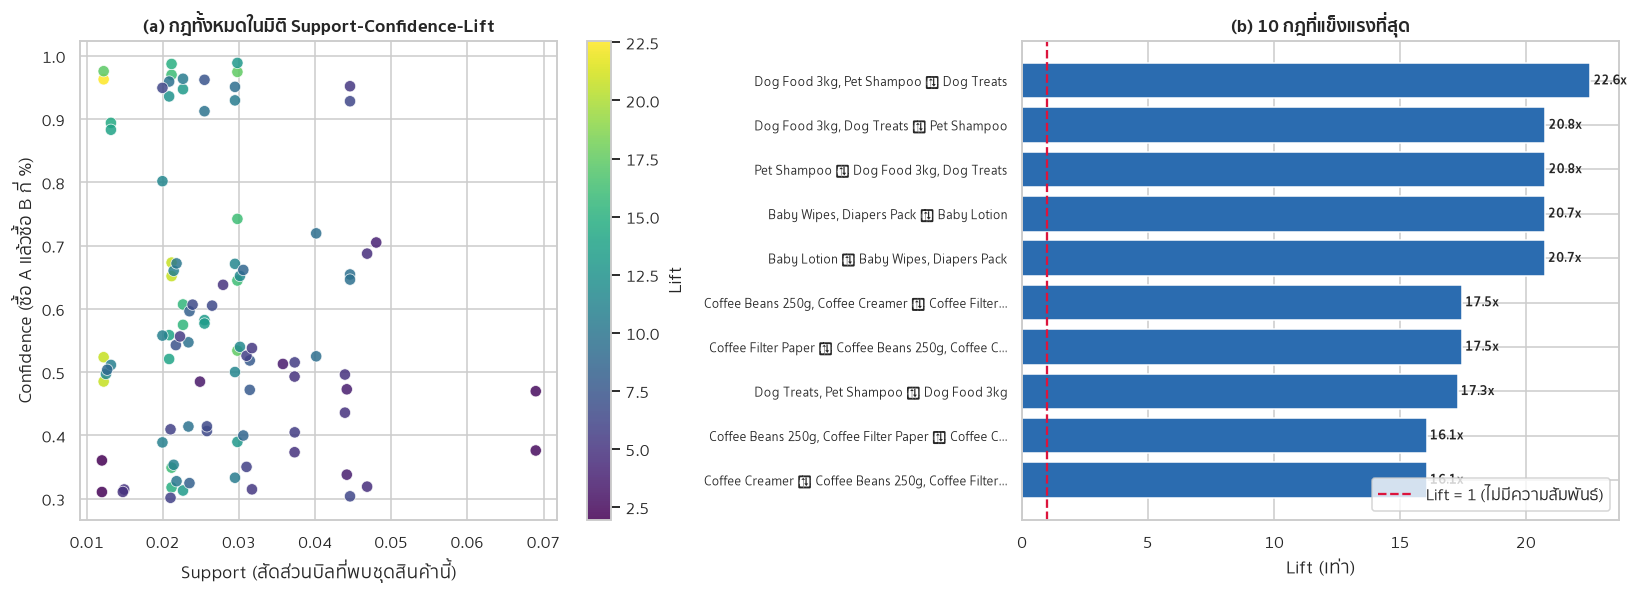

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) The classic support-confidence scatter, coloured by lift
sc = axes[0].scatter(rules.support, rules.confidence, c=rules.lift,
                     s=55, cmap="viridis", alpha=0.85, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Support (สัดส่วนบิลที่พบชุดสินค้านี้)")
axes[0].set_ylabel("Confidence (ซื้อ A แล้วซื้อ B กี่ %)")
axes[0].set_title("(a) กฎทั้งหมดในมิติ Support-Confidence-Lift")
plt.colorbar(sc, ax=axes[0], label="Lift")

# (b) Top rules ranked by lift
top10 = rules.head(10).iloc[::-1]
lbl = [f"{a} → {c}" for a, c in zip(top10.antecedents_str, top10.consequents_str)]
lbl = [x if len(x) <= 52 else x[:49] + "..." for x in lbl]
bars = axes[1].barh(range(len(top10)), top10.lift.values, color="#2b6cb0")
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(lbl, fontsize=8.5)
axes[1].axvline(1.0, color="crimson", linestyle="--", linewidth=1.5,
                label="Lift = 1 (ไม่มีความสัมพันธ์)")
axes[1].set_xlabel("Lift (เท่า)")
axes[1].set_title("(b) 10 กฎที่แข็งแรงที่สุด")
axes[1].legend(loc="lower right")
for b, v in zip(bars, top10.lift.values):
    axes[1].text(v, b.get_y() + b.get_height() / 2, f" {v:.1f}x",
                 va="center", fontsize=8.5, fontweight="bold")

fig.tight_layout()
save_fig(fig, "f05_association_rules")
plt.show()

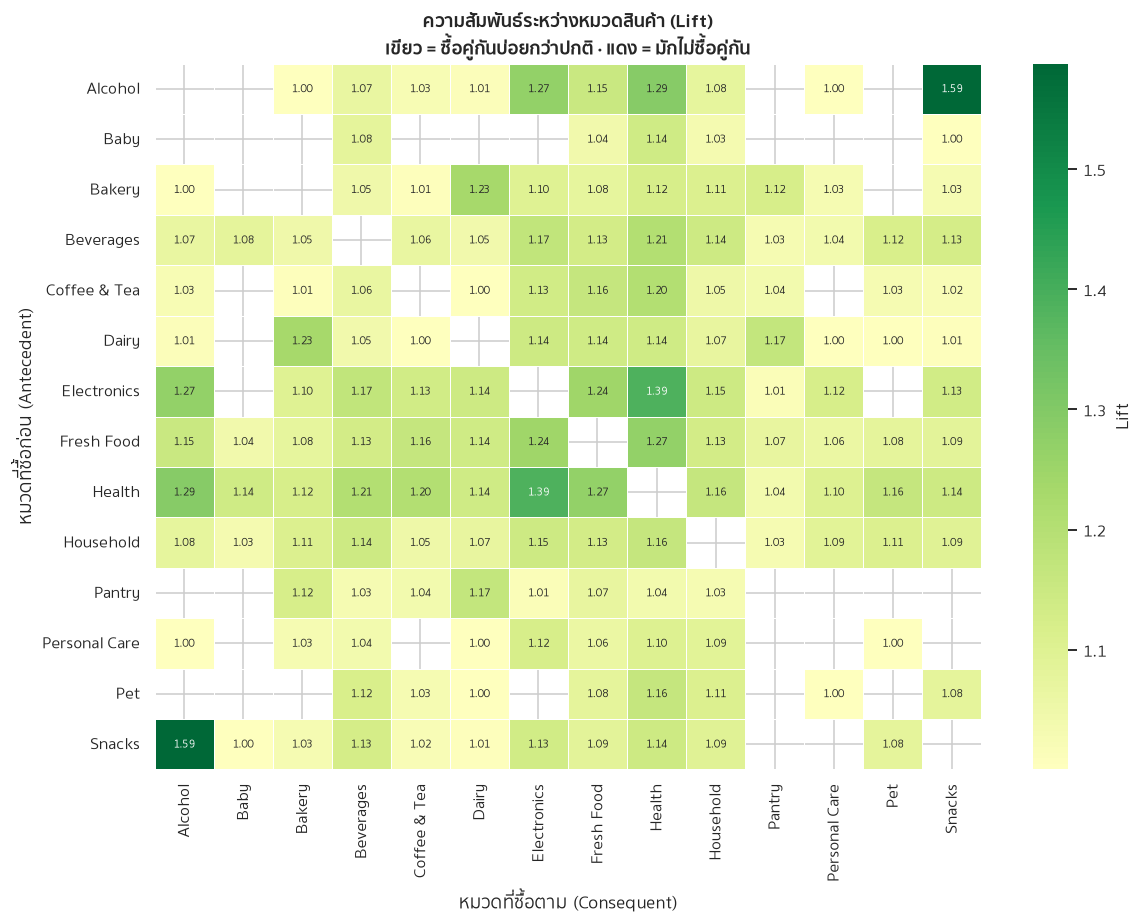

คู่หมวดสินค้า,support,confidence,lift
Snacks → Alcohol,0.0778,0.223,1.59
Alcohol → Snacks,0.0778,0.554,1.59
Health → Electronics,0.0321,0.176,1.39
Electronics → Health,0.0321,0.253,1.39
Health → Alcohol,0.0331,0.181,1.29
Alcohol → Health,0.0331,0.235,1.29
Fresh Food → Health,0.1170,0.232,1.27
Health → Fresh Food,0.1170,0.641,1.27


In [31]:
# Category-level co-occurrence: which departments pull each other into the same basket?
# This drives store-layout and cross-department campaign decisions.
cat_itemsets = fpgrowth(basket_matrix_cat, min_support=0.02, use_colnames=True, max_len=2)
cat_rules = association_rules(cat_itemsets, metric="lift", min_threshold=1.0)
cat_rules = cat_rules[(cat_rules.antecedents.apply(len) == 1)
                      & (cat_rules.consequents.apply(len) == 1)]

lift_matrix = pd.DataFrame(
    np.nan, index=basket_matrix_cat.columns, columns=basket_matrix_cat.columns, dtype=float)
for _, r in cat_rules.iterrows():
    lift_matrix.loc[list(r.antecedents)[0], list(r.consequents)[0]] = r.lift

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(lift_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Lift"},
            annot_kws={"fontsize": 7.5})
ax.set_title("ความสัมพันธ์ระหว่างหมวดสินค้า (Lift)\n"
             "เขียว = ซื้อคู่กันบ่อยกว่าปกติ · แดง = มักไม่ซื้อคู่กัน",
             fontweight="bold")
ax.set_xlabel("หมวดที่ซื้อตาม (Consequent)")
ax.set_ylabel("หมวดที่ซื้อก่อน (Antecedent)")
fig.tight_layout()
save_fig(fig, "f06_category_lift_heatmap")
plt.show()

cat_top = cat_rules.nlargest(8, "lift").copy()
cat_top["คู่หมวดสินค้า"] = [f"{list(a)[0]} → {list(c)[0]}"
                            for a, c in zip(cat_top.antecedents, cat_top.consequents)]
cat_out = cat_top[["คู่หมวดสินค้า", "support", "confidence", "lift"]]
save_table(cat_out, "t11_category_rules_top")

rv("ar_cat_n_rules", int(len(cat_rules)))
rv("ar_cat_top_pair", str(cat_top["คู่หมวดสินค้า"].iloc[0]))
rv("ar_cat_top_lift", round(float(cat_top.lift.iloc[0]), 2))
cat_out.style.format({"support": "{:.4f}", "confidence": "{:.3f}", "lift": "{:.2f}"}).hide(axis="index")

In [32]:
# Quantify the revenue opportunity: for the strongest rules, how much money is sitting
# in baskets that contain the antecedent but NOT the consequent? That is the gap a
# cross-sell promotion is designed to close.
opportunity = []
for _, r in rules.head(20).iterrows():
    ante = list(r.antecedents)
    cons = list(r.consequents)
    has_ante = basket_matrix[ante].all(axis=1)
    has_cons = basket_matrix[cons].all(axis=1)
    missed = int((has_ante & ~has_cons).sum())
    cons_price = products_raw.set_index("product_name").unit_price.reindex(cons).sum()
    opportunity.append({
        "ถ้าซื้อ": ", ".join(sorted(ante)),
        "ควรเสนอ": ", ".join(sorted(cons)),
        "Lift": round(float(r.lift), 2),
        "Confidence": round(float(r.confidence), 3),
        "บิลที่ซื้อ A แต่ไม่ซื้อ B": missed,
        "มูลค่า B (บาท)": float(cons_price),
        "โอกาสรายได้ (บาท)": round(missed * float(cons_price), 0),
    })

opp_df = (pd.DataFrame(opportunity)
          .sort_values("โอกาสรายได้ (บาท)", ascending=False)
          .reset_index(drop=True))
save_table(opp_df, "t12_crosssell_opportunity")

total_opp = float(opp_df["โอกาสรายได้ (บาท)"].sum())
rv("ar_crosssell_total_opportunity_thb", round(total_opp, 0))
rv("ar_crosssell_top_opportunity_thb", round(float(opp_df["โอกาสรายได้ (บาท)"].iloc[0]), 0))
rv("ar_crosssell_top_pair",
   f"{opp_df['ถ้าซื้อ'].iloc[0]} -> {opp_df['ควรเสนอ'].iloc[0]}")

print("โอกาสทางรายได้จากการขายพ่วง (คิดจาก 20 กฎที่แข็งแรงที่สุด)")
print(f"มูลค่ารวมสูงสุดตามทฤษฎี: {total_opp:,.0f} บาท")
print()
print("หมายเหตุ: ตัวเลขนี้คือเพดานบน สมมติว่าปิดการขายได้ 100% ซึ่งเป็นไปไม่ได้จริง")
print("          ใช้เพื่อ 'จัดลำดับความสำคัญ' ว่าควรทำโปรคู่ไหนก่อน ไม่ใช่พยากรณ์รายได้")
opp_df.head(10)

โอกาสทางรายได้จากการขายพ่วง (คิดจาก 20 กฎที่แข็งแรงที่สุด)
มูลค่ารวมสูงสุดตามทฤษฎี: 6,143,271 บาท

หมายเหตุ: ตัวเลขนี้คือเพดานบน สมมติว่าปิดการขายได้ 100% ซึ่งเป็นไปไม่ได้จริง
          ใช้เพื่อ 'จัดลำดับความสำคัญ' ว่าควรทำโปรคู่ไหนก่อน ไม่ใช่พยากรณ์รายได้


,ถ้าซื้อ,ควรเสนอ,Lift,Confidence,บิลที่ซื้อ A แต่ไม่ซื้อ B,มูลค่า B (บาท),โอกาสรายได้ (บาท)
0,Baby Wipes,"Baby Lotion, Diapers Pack",16.01,0.349,2601,698.0,1815498.0
1,Diapers Pack,"Baby Lotion, Baby Wipes",14.83,0.318,2994,288.0,862272.0
2,Coffee Filter Paper,"Coffee Beans 250g, Coffee Creamer",17.47,0.534,1714,395.0,677030.0
3,Pet Shampoo,"Dog Food 3kg, Dog Treats",20.77,0.485,856,598.0,511888.0
4,Coffee Creamer,"Coffee Beans 250g, Coffee Filter Paper",16.07,0.645,1082,405.0,438210.0
5,Baby Lotion,"Baby Wipes, Diapers Pack",20.75,0.652,745,588.0,438060.0
6,Hair Treatment Mask,"Conditioner, Shampoo",15.40,0.575,1105,378.0,417690.0
7,"Conditioner, Shampoo",Hair Treatment Mask,15.40,0.607,967,259.0,250453.0
8,Mouthwash,"Toothbrush, Toothpaste",13.96,0.521,1264,148.0,187072.0
9,"Toothbrush, Toothpaste",Mouthwash,13.96,0.559,1086,139.0,150954.0


---
## §4.2 โจทย์ที่ 2 — Customer Segmentation (Clustering)

> **คำถามผู้บริหาร:** *พฤติกรรมการซื้อแบ่งลูกค้าได้กี่กลุ่ม แต่ละกลุ่มมีลักษณะเด่นอย่างไร*

### แผนการทำงาน
1. แปลงตัวแปรที่เบ้ด้วย `log1p` แล้วปรับสเกลด้วย `StandardScaler` (เหตุผลใน §2.4)
2. หาจำนวนกลุ่มที่เหมาะสมด้วย Elbow + Silhouette + Davies-Bouldin
3. **ตรวจสอบด้วย DBSCAN** ว่ากลุ่มที่ได้มีอยู่จริงตามธรรมชาติหรือเป็นเส้นที่เราลากเอง
4. สร้าง persona และกลยุทธ์รายกลุ่ม

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Features used for segmentation, and which of them need a log transform first
SEG_FEATURES = ["recency", "frequency", "monetary", "avg_order_value",
                "tenure_days", "basket_depth", "discount_ratio",
                "category_breadth", "channel_diversity"]
SKEWED = ["recency", "frequency", "monetary", "avg_order_value", "basket_depth"]

seg_raw = customer_features[SEG_FEATURES].copy()
seg_log = seg_raw.copy()
seg_log[SKEWED] = np.log1p(seg_log[SKEWED])

scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(seg_log)

rv("seg_features_used", SEG_FEATURES)
rv("seg_features_log_transformed", SKEWED)
rv("seg_n_customers", int(X_seg.shape[0]))
rv("seg_n_features", int(X_seg.shape[1]))

print(f"ข้อมูลสำหรับ clustering: {X_seg.shape[0]:,} ลูกค้า x {X_seg.shape[1]} ฟีเจอร์")
print(f"ฟีเจอร์ที่แปลง log1p: {SKEWED}")

ข้อมูลสำหรับ clustering: 3,000 ลูกค้า x 9 ฟีเจอร์
ฟีเจอร์ที่แปลง log1p: ['recency', 'frequency', 'monetary', 'avg_order_value', 'basket_depth']


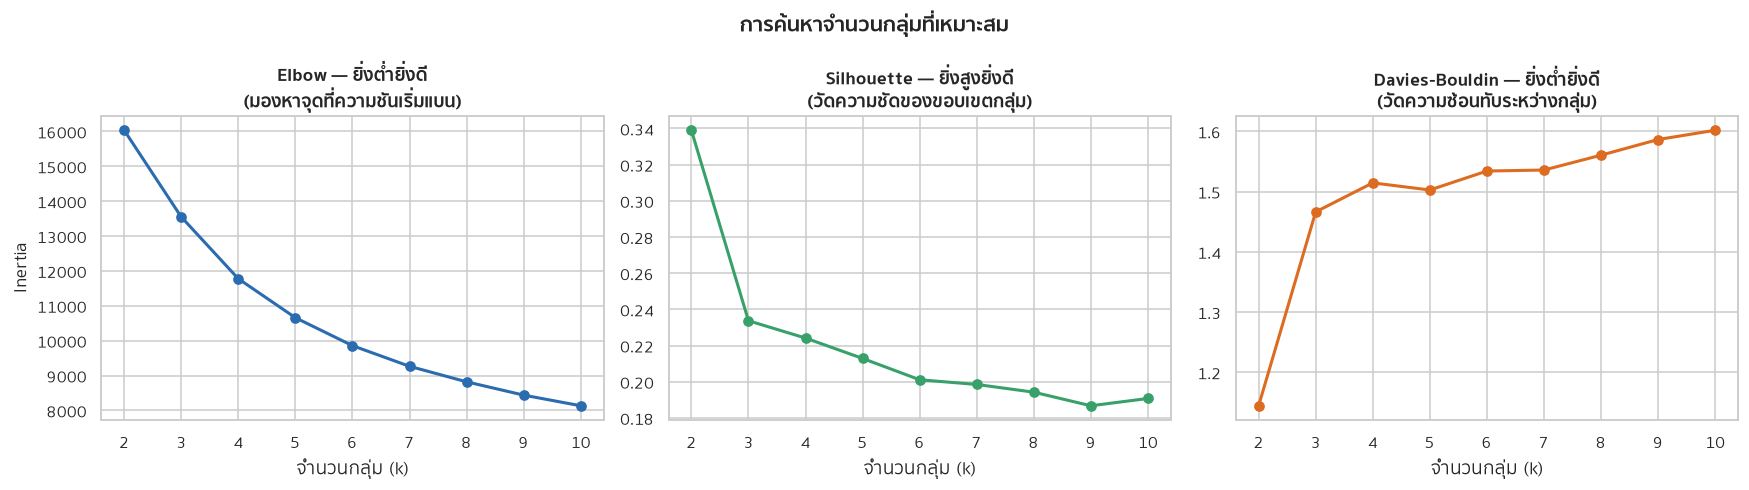

k,inertia,silhouette,davies_bouldin,calinski_harabasz
2,"16,033",0.3390,1.1443,"2,050.8"
3,"13,547",0.2337,1.4662,"1,488.1"
4,"11,775",0.2241,1.5144,"1,291.4"
5,"10,658",0.2128,1.5026,"1,148.1"
6,"9,856",0.2011,1.5340,"1,041.6"
7,"9,264",0.1985,1.5357,955.0
8,"8,819",0.1942,1.5603,881.2
9,"8,438",0.1867,1.5864,822.5
10,"8,132",0.1907,1.6017,770.8


In [34]:
# Search for the number of clusters using three independent criteria.
# Using several criteria matters because they disagree - and the disagreement itself
# is informative about whether real clusters exist.
K_RANGE = range(2, 11)
search = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_seg)
    search.append({
        "k": k,
        "inertia": float(km.inertia_),
        "silhouette": float(silhouette_score(X_seg, km.labels_)),
        "davies_bouldin": float(davies_bouldin_score(X_seg, km.labels_)),
        "calinski_harabasz": float(calinski_harabasz_score(X_seg, km.labels_)),
    })

search_df = pd.DataFrame(search)
save_table(search_df, "t13_kmeans_k_search")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(search_df.k, search_df.inertia, marker="o", linewidth=2, color="#2b6cb0")
axes[0].set_title("Elbow — ยิ่งต่ำยิ่งดี\n(มองหาจุดที่ความชันเริ่มแบน)")
axes[0].set_xlabel("จำนวนกลุ่ม (k)"); axes[0].set_ylabel("Inertia")

axes[1].plot(search_df.k, search_df.silhouette, marker="o", linewidth=2, color="#38a169")
axes[1].set_title("Silhouette — ยิ่งสูงยิ่งดี\n(วัดความชัดของขอบเขตกลุ่ม)")
axes[1].set_xlabel("จำนวนกลุ่ม (k)")

axes[2].plot(search_df.k, search_df.davies_bouldin, marker="o", linewidth=2, color="#dd6b20")
axes[2].set_title("Davies-Bouldin — ยิ่งต่ำยิ่งดี\n(วัดความซ้อนทับระหว่างกลุ่ม)")
axes[2].set_xlabel("จำนวนกลุ่ม (k)")

fig.suptitle("การค้นหาจำนวนกลุ่มที่เหมาะสม", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f07_k_selection")
plt.show()

best_sil_k = int(search_df.loc[search_df.silhouette.idxmax(), "k"])
rv("seg_best_silhouette_k", best_sil_k)
rv("seg_best_silhouette_value", round(float(search_df.silhouette.max()), 4))
rv("seg_k_search_table", search_df.round(4).to_dict("records"))
search_df.style.format({"inertia": "{:,.0f}", "silhouette": "{:.4f}",
                        "davies_bouldin": "{:.4f}", "calinski_harabasz": "{:,.1f}"}).hide(axis="index")

### ตรวจสอบสมมติฐาน: กลุ่มเหล่านี้มีอยู่จริงตามธรรมชาติหรือไม่?

K-Means **บังคับให้เกิด k กลุ่มเสมอ แม้ข้อมูลจะไม่มีกลุ่มอยู่จริง** — ถ้าโยนข้อมูลสุ่มเข้าไป
มันก็ยังคืนกลุ่มมาให้ ดังนั้นก่อนจะนำ segment ไปเสนอผู้บริหาร ต้องตอบให้ได้ก่อนว่า
*นี่คือกลุ่มที่มีอยู่จริง หรือเป็นเส้นที่เราลากขึ้นมาเอง?*

**DBSCAN ตอบคำถามนี้ได้** เพราะแบ่งกลุ่มตามความหนาแน่นและ **ปฏิเสธที่จะแบ่งได้**
ถ้าไม่พบช่องว่างระหว่างกลุ่ม — ต่างจาก K-Means ที่แบ่งเสมอไม่ว่าอย่างไร

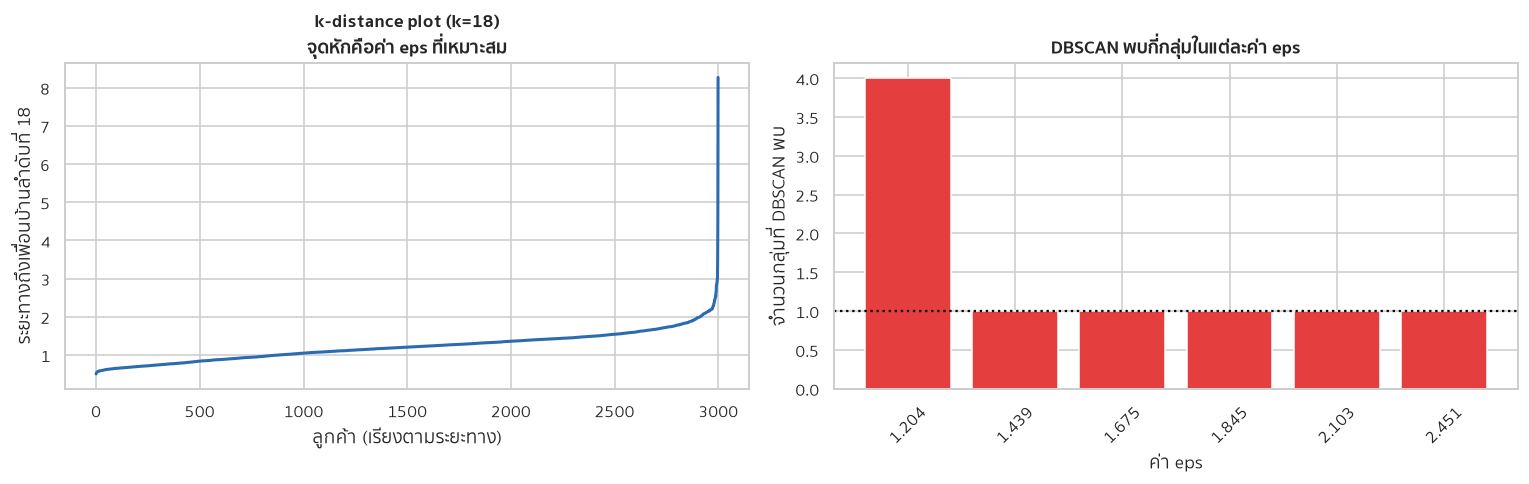

,eps,จำนวนกลุ่มที่พบ,จุดที่เป็น noise,% noise
0,1.204,4,704,23.5
1,1.439,1,172,5.7
2,1.675,1,49,1.6
3,1.845,1,18,0.6
4,2.103,1,7,0.2
5,2.451,1,2,0.1


In [35]:
# Choose eps the standard way: the knee of the sorted k-distance curve
MIN_SAMPLES = 2 * X_seg.shape[1]  # rule of thumb: 2 x number of dimensions
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_seg)
distances, _ = nn.kneighbors(X_seg)
k_dist = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(k_dist, linewidth=2, color="#2b6cb0")
axes[0].set_title(f"k-distance plot (k={MIN_SAMPLES})\nจุดหักคือค่า eps ที่เหมาะสม")
axes[0].set_xlabel("ลูกค้า (เรียงตามระยะทาง)")
axes[0].set_ylabel(f"ระยะทางถึงเพื่อนบ้านลำดับที่ {MIN_SAMPLES}")

# Scan a range of eps around the knee and record how many clusters emerge
eps_grid = np.round(np.quantile(k_dist, [0.50, 0.75, 0.90, 0.95, 0.98, 0.995]), 3)
dbscan_rows = []
for eps in eps_grid:
    lab = DBSCAN(eps=float(eps), min_samples=MIN_SAMPLES).fit_predict(X_seg)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    dbscan_rows.append({
        "eps": float(eps),
        "จำนวนกลุ่มที่พบ": n_clusters,
        "จุดที่เป็น noise": n_noise,
        "% noise": round(n_noise / len(lab) * 100, 1),
    })

dbscan_df = pd.DataFrame(dbscan_rows)
axes[1].bar(range(len(dbscan_df)), dbscan_df["จำนวนกลุ่มที่พบ"], color="#e53e3e")
axes[1].set_xticks(range(len(dbscan_df)))
axes[1].set_xticklabels([f"{e}" for e in dbscan_df.eps], rotation=45)
axes[1].set_xlabel("ค่า eps")
axes[1].set_ylabel("จำนวนกลุ่มที่ DBSCAN พบ")
axes[1].set_title("DBSCAN พบกี่กลุ่มในแต่ละค่า eps")
axes[1].axhline(1, color="black", linestyle=":", linewidth=1.5)

fig.tight_layout()
save_fig(fig, "f08_dbscan_check")
plt.show()

save_table(dbscan_df, "t14_dbscan_scan")

# A multi-cluster result only counts as evidence of natural structure if it is also
# STABLE and does not throw most of the data away as noise. Judge on both, not on
# "the largest number of clusters seen anywhere in the sweep".
MAX_ACCEPTABLE_NOISE_PCT = 10.0
robust = dbscan_df[(dbscan_df["จำนวนกลุ่มที่พบ"] > 1)
                   & (dbscan_df["% noise"] <= MAX_ACCEPTABLE_NOISE_PCT)]

max_clusters_any = int(dbscan_df["จำนวนกลุ่มที่พบ"].max())
n_eps_multi = int((dbscan_df["จำนวนกลุ่มที่พบ"] > 1).sum())

rv("seg_dbscan_min_samples", MIN_SAMPLES)
rv("seg_dbscan_max_clusters_any", max_clusters_any)
rv("seg_dbscan_n_eps_tested", int(len(dbscan_df)))
rv("seg_dbscan_n_eps_multicluster", n_eps_multi)
rv("seg_dbscan_n_eps_robust", int(len(robust)))
rv("seg_dbscan_noise_threshold_pct", MAX_ACCEPTABLE_NOISE_PCT)
rv("seg_dbscan_scan_table", dbscan_df.to_dict("records"))
rv("seg_dbscan_found_natural_clusters", bool(len(robust) > 0))
dbscan_df

In [36]:
# State the conclusion from the numbers above rather than from expectation.
if len(robust) == 0:
    verdict = "\n".join([
        f"ทดสอบ eps ทั้งหมด {len(dbscan_df)} ค่า พบว่าไม่มีค่าใดเลยที่ให้ผลการแบ่งกลุ่มที่ 'เชื่อถือได้'",
        f"(นิยาม: ได้มากกว่า 1 กลุ่ม โดยทิ้งข้อมูลเป็น noise ไม่เกิน {MAX_ACCEPTABLE_NOISE_PCT:.0f}%)",
        "",
        f"รายละเอียด: มี eps เพียง {n_eps_multi} ค่าที่ให้มากกว่า 1 กลุ่ม คือค่าที่เล็กที่สุด",
        f"(eps={dbscan_df.eps.iloc[0]}) ซึ่งได้ {max_clusters_any} กลุ่ม "
        f"แต่ต้องทิ้งข้อมูลถึง {dbscan_df['% noise'].iloc[0]:.1f}% เป็น noise",
        "และเมื่อขยับ eps ขึ้นเพียงเล็กน้อย กลุ่มทั้งหมดก็ยุบรวมเป็นกลุ่มเดียวทันที",
        "",
        "รูปแบบนี้คือลายเซ็นของ 'ก้อนข้อมูลต่อเนื่องที่มีแกนกลางหนาแน่น' ไม่ใช่กลุ่มที่แยกจากกันจริง",
        "— ที่ eps เล็ก DBSCAN เพียงแค่ซอยแกนกลางออกเป็นเสี่ยง ๆ แล้วโยนส่วนที่เหลือทิ้งเป็น noise",
    ])
    implication = "\n".join([
        "K-Means ในงานนี้จึงทำหน้าที่เป็น 'เครื่องมือแบ่งความต่อเนื่องออกเป็นกลุ่มที่บริหารจัดการได้'",
        "ไม่ใช่ 'การค้นพบกลุ่มที่ซ่อนอยู่' — ซึ่งยังมีคุณค่าทางธุรกิจเต็มที่ เพราะทีมการตลาด",
        "ต้องการกลุ่มที่ยิงแคมเปญได้จริง ไม่ได้ต้องการความจริงเชิงภววิทยา",
        "",
        "แต่มีนัยสำคัญ 3 ข้อที่ต้องบอกผู้บริหารพร้อมกับผลลัพธ์:",
        "  1. เส้นแบ่งระหว่างกลุ่มเป็นเส้นที่เราเลือกลากเอง จึงต้องเลือกจำนวนกลุ่มด้วยเหตุผล",
        "     ทางธุรกิจ (จำนวนแคมเปญที่ทีมบริหารไหว) ไม่ใช่ไล่หาค่าสถิติที่สูงที่สุดอย่างเดียว",
        "  2. ค่า Silhouette ที่ไม่สูงไม่ได้แปลว่าโมเดลแย่ แต่สะท้อนธรรมชาติของข้อมูลที่ต่อเนื่อง",
        "     — เป็นข้อเท็จจริงที่ต้องรายงาน ไม่ใช่ข้อบกพร่องที่ต้องซ่อน",
        "  3. ลูกค้าที่อยู่ใกล้เส้นแบ่งอาจสลับกลุ่มได้เมื่อ retrain จึงไม่ควรผูกสิทธิประโยชน์",
        "     ที่ถอนคืนยากไว้กับหมายเลข segment โดยตรง",
    ])
else:
    verdict = "\n".join([
        f"พบการแบ่งกลุ่มที่เชื่อถือได้ {len(robust)} ค่า eps "
        f"(มากกว่า 1 กลุ่ม และ noise ไม่เกิน {MAX_ACCEPTABLE_NOISE_PCT:.0f}%)",
        f"จำนวนกลุ่มที่พบ: {sorted(robust['จำนวนกลุ่มที่พบ'].unique().tolist())}",
    ])
    implication = "\n".join([
        "มีโครงสร้างกลุ่มตามธรรมชาติอยู่จริงในข้อมูล",
        "จึงควรเทียบจำนวนกลุ่มที่ DBSCAN พบกับค่า k ที่เลือกให้ K-Means",
    ])

rv("seg_dbscan_verdict", verdict.replace("\n", " "))
print("=" * 78)
print("ผลการตรวจสอบด้วย DBSCAN: กลุ่มเหล่านี้มีอยู่จริงตามธรรมชาติหรือไม่?")
print("=" * 78)
print(verdict)
print()
print("-" * 78)
print("นัยต่อการตีความผลลัพธ์")
print("-" * 78)
print(implication)

ผลการตรวจสอบด้วย DBSCAN: กลุ่มเหล่านี้มีอยู่จริงตามธรรมชาติหรือไม่?
ทดสอบ eps ทั้งหมด 6 ค่า พบว่าไม่มีค่าใดเลยที่ให้ผลการแบ่งกลุ่มที่ 'เชื่อถือได้'
(นิยาม: ได้มากกว่า 1 กลุ่ม โดยทิ้งข้อมูลเป็น noise ไม่เกิน 10%)

รายละเอียด: มี eps เพียง 1 ค่าที่ให้มากกว่า 1 กลุ่ม คือค่าที่เล็กที่สุด
(eps=1.204) ซึ่งได้ 4 กลุ่ม แต่ต้องทิ้งข้อมูลถึง 23.5% เป็น noise
และเมื่อขยับ eps ขึ้นเพียงเล็กน้อย กลุ่มทั้งหมดก็ยุบรวมเป็นกลุ่มเดียวทันที

รูปแบบนี้คือลายเซ็นของ 'ก้อนข้อมูลต่อเนื่องที่มีแกนกลางหนาแน่น' ไม่ใช่กลุ่มที่แยกจากกันจริง
— ที่ eps เล็ก DBSCAN เพียงแค่ซอยแกนกลางออกเป็นเสี่ยง ๆ แล้วโยนส่วนที่เหลือทิ้งเป็น noise

------------------------------------------------------------------------------
นัยต่อการตีความผลลัพธ์
------------------------------------------------------------------------------
K-Means ในงานนี้จึงทำหน้าที่เป็น 'เครื่องมือแบ่งความต่อเนื่องออกเป็นกลุ่มที่บริหารจัดการได้'
ไม่ใช่ 'การค้นพบกลุ่มที่ซ่อนอยู่' — ซึ่งยังมีคุณค่าทางธุรกิจเต็มที่ เพราะทีมการตลาด
ต้องการกลุ่มที่ยิงแคมเปญได้จริง 

In [37]:
# Final choice of k, made on business grounds and justified against the metrics.
K_CHOSEN = 4

kmeans = KMeans(n_clusters=K_CHOSEN, n_init=25, random_state=RANDOM_STATE)
seg_labels = kmeans.fit_predict(X_seg)
customer_features["segment"] = seg_labels

sil_chosen = float(silhouette_score(X_seg, seg_labels))
rv("seg_k_chosen", K_CHOSEN)
rv("seg_silhouette_chosen", round(sil_chosen, 4))
rv("seg_inertia_chosen", round(float(kmeans.inertia_), 1))
rv("seg_cluster_sizes", pd.Series(seg_labels).value_counts().sort_index().tolist())

print(f"เลือก k = {K_CHOSEN} กลุ่ม")
print(f"  Silhouette = {sil_chosen:.4f}")
print()
print("เหตุผลในการเลือก:")
print(f"  - Elbow: ความชันของ inertia เริ่มแบนราบแถว k=4")
print(f"  - Silhouette สูงสุดอยู่ที่ k={best_sil_k} "
      f"({search_df.silhouette.max():.4f}) แต่ให้กลุ่มที่หยาบเกินกว่าจะออกแบบแคมเปญที่ต่างกันได้")
if len(robust) == 0:
    print(f"  - DBSCAN ยืนยันว่าไม่มีกลุ่มธรรมชาติที่เสถียร การไล่หา silhouette สูงสุด")
    print(f"    จึงไม่ใช่เกณฑ์ที่ถูกต้อง เพราะไม่มี 'คำตอบที่ถูก' ให้ค้นหาตั้งแต่แรก")
print(f"  - k=4 ให้จำนวน persona ที่ทีมการตลาดออกแบบแคมเปญแยกกันได้จริง")
print()
print("ขนาดของแต่ละกลุ่ม:")
for c, n in pd.Series(seg_labels).value_counts().sort_index().items():
    print(f"  กลุ่ม {c}: {n:,} ราย ({n/len(seg_labels):.1%})")

เลือก k = 4 กลุ่ม
  Silhouette = 0.2241

เหตุผลในการเลือก:
  - Elbow: ความชันของ inertia เริ่มแบนราบแถว k=4
  - Silhouette สูงสุดอยู่ที่ k=2 (0.3390) แต่ให้กลุ่มที่หยาบเกินกว่าจะออกแบบแคมเปญที่ต่างกันได้
  - DBSCAN ยืนยันว่าไม่มีกลุ่มธรรมชาติที่เสถียร การไล่หา silhouette สูงสุด
    จึงไม่ใช่เกณฑ์ที่ถูกต้อง เพราะไม่มี 'คำตอบที่ถูก' ให้ค้นหาตั้งแต่แรก
  - k=4 ให้จำนวน persona ที่ทีมการตลาดออกแบบแคมเปญแยกกันได้จริง

ขนาดของแต่ละกลุ่ม:
  กลุ่ม 0: 924 ราย (30.8%)
  กลุ่ม 1: 749 ราย (25.0%)
  กลุ่ม 2: 720 ราย (24.0%)
  กลุ่ม 3: 607 ราย (20.2%)


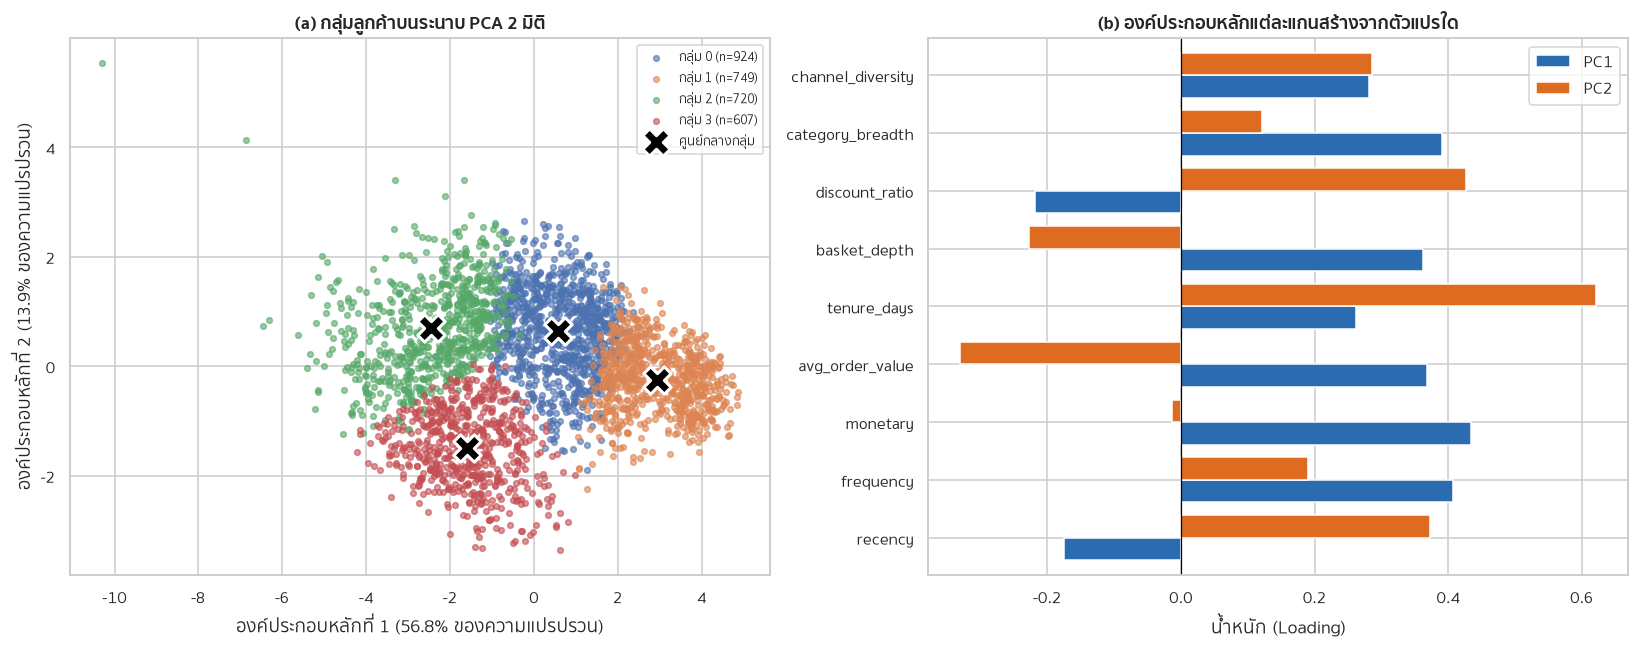

PCA 2 องค์ประกอบแรกอธิบายความแปรปรวนได้รวม 70.7%


In [38]:
# Visualise the segments in 2D via PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_seg)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = sns.color_palette("deep", K_CHOSEN)
for c in range(K_CHOSEN):
    m = seg_labels == c
    axes[0].scatter(coords[m, 0], coords[m, 1], s=14, alpha=0.6,
                    color=palette[c], label=f"กลุ่ม {c} (n={m.sum():,})")
centroids_2d = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=320,
                c="black", edgecolors="white", linewidth=2, label="ศูนย์กลางกลุ่ม", zorder=5)
axes[0].set_xlabel(f"องค์ประกอบหลักที่ 1 ({var_explained[0]:.1%} ของความแปรปรวน)")
axes[0].set_ylabel(f"องค์ประกอบหลักที่ 2 ({var_explained[1]:.1%} ของความแปรปรวน)")
axes[0].set_title("(a) กลุ่มลูกค้าบนระนาบ PCA 2 มิติ")
axes[0].legend(fontsize=8.5)

# What each principal component actually means, so the scatter is interpretable
loadings = pd.DataFrame(pca.components_.T, index=SEG_FEATURES, columns=["PC1", "PC2"])
loadings.plot(kind="barh", ax=axes[1], color=["#2b6cb0", "#dd6b20"], width=0.78)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("(b) องค์ประกอบหลักแต่ละแกนสร้างจากตัวแปรใด")
axes[1].set_xlabel("น้ำหนัก (Loading)")
axes[1].legend(title="")

fig.tight_layout()
save_fig(fig, "f09_segments_pca")
plt.show()

rv("seg_pca_var_pc1", round(float(var_explained[0]), 4))
rv("seg_pca_var_pc2", round(float(var_explained[1]), 4))
rv("seg_pca_var_total", round(float(var_explained.sum()), 4))
save_table(loadings.reset_index().rename(columns={"index": "feature"}), "t15_pca_loadings")
print(f"PCA 2 องค์ประกอบแรกอธิบายความแปรปรวนได้รวม {var_explained.sum():.1%}")

In [39]:
# Build the persona table in ORIGINAL units - scaled values mean nothing to an executive.
profile = customer_features.groupby("segment")[SEG_FEATURES].mean()
profile["n_customers"] = customer_features.groupby("segment").size()
profile["pct_customers"] = profile.n_customers / len(customer_features)
profile["total_revenue"] = customer_features.groupby("segment").monetary.sum()
profile["pct_revenue"] = profile.total_revenue / customer_features.monetary.sum()

# Attach churn rate so segmentation connects to the retention question
seg_churn = (customer_features[["segment"]]
             .join(churn_raw.set_index("customer_id").churn, how="left")
             .groupby("segment").churn.mean())
profile["churn_rate"] = seg_churn

# Dominant category per segment
cust_seg = customer_features[["segment"]]
top_cat = (items_full.merge(cust_seg, left_on="customer_id", right_index=True)
           .groupby(["segment", "category"]).line_amount.sum()
           .groupby(level=0, group_keys=False).nlargest(1).reset_index())
profile["top_category"] = top_cat.set_index("segment").category

save_table(profile.reset_index(), "t16_segment_profile_raw")
rv("seg_profile_table", profile.round(3).reset_index().to_dict("records"))

display_cols = ["n_customers", "pct_customers", "pct_revenue", "recency", "frequency",
                "monetary", "avg_order_value", "discount_ratio", "category_breadth",
                "churn_rate", "top_category"]
profile[display_cols].style.format({
    "n_customers": "{:,.0f}", "pct_customers": "{:.1%}", "pct_revenue": "{:.1%}",
    "recency": "{:.0f} วัน", "frequency": "{:.1f} ครั้ง", "monetary": "{:,.0f} บาท",
    "avg_order_value": "{:,.0f} บาท", "discount_ratio": "{:.1%}",
    "category_breadth": "{:.1f} หมวด", "churn_rate": "{:.1%}",
}).background_gradient(subset=["monetary", "churn_rate"], cmap="RdYlGn_r")

,n_customers,pct_customers,pct_revenue,recency,frequency,monetary,avg_order_value,discount_ratio,category_breadth,churn_rate,top_category
segment,,,,,,,,,,,
0,924,30.8%,17.6%,95 วัน,19.4 ครั้ง,"21,446 บาท","1,108 บาท",4.0%,12.8 หมวด,45.2%,Personal Care
1,749,25.0%,76.5%,12 วัน,51.5 ครั้ง,"114,841 บาท","2,029 บาท",1.7%,13.9 หมวด,1.2%,Fresh Food
2,720,24.0%,2.5%,84 วัน,8.0 ครั้ง,"3,869 บาท",488 บาท,6.9%,8.5 หมวด,28.3%,Pantry
3,607,20.2%,3.4%,44 วัน,6.0 ครั้ง,"6,231 บาท","1,059 บาท",3.1%,9.4 หมวด,18.5%,Personal Care


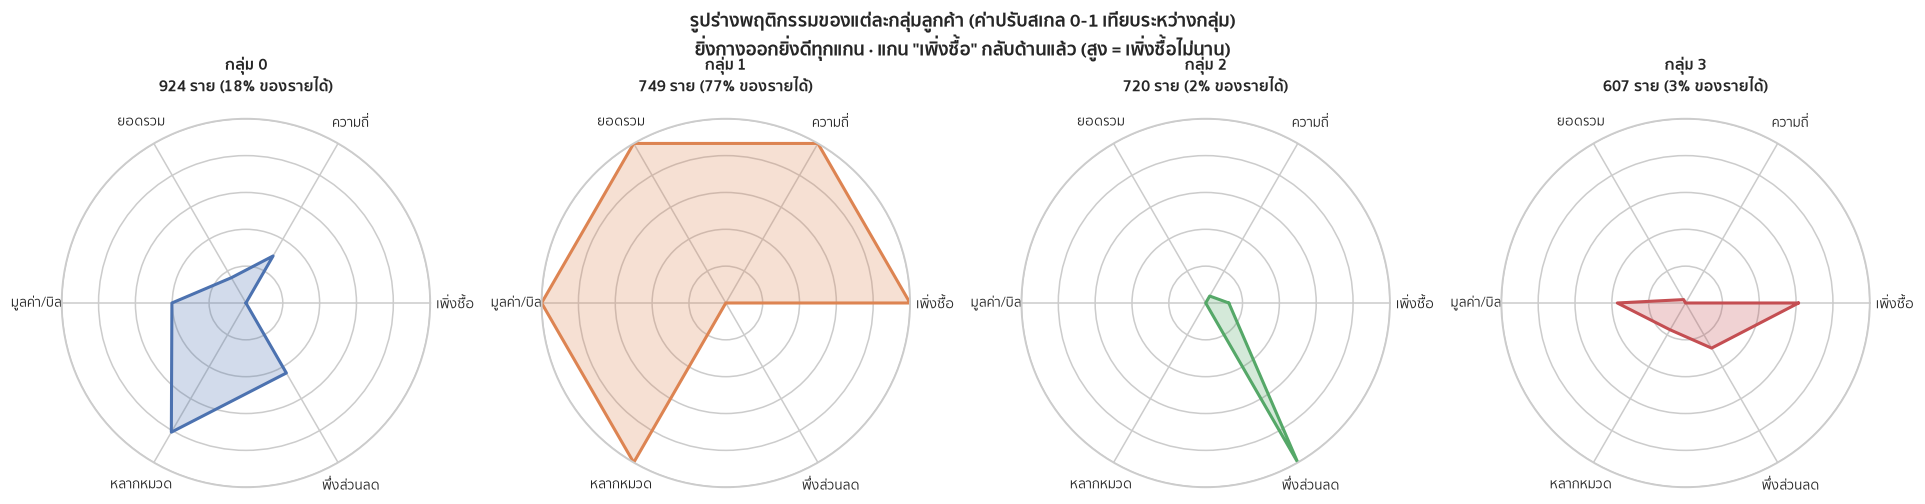

In [40]:
# Radar chart: the shape of each persona at a glance
radar_feats = ["recency", "frequency", "monetary", "avg_order_value",
               "category_breadth", "discount_ratio"]
# Keep labels short: long text collides with the polygon on a small polar axes.
# The full meaning is spelled out in the figure caption instead.
radar_labels = ["เพิ่งซื้อ", "ความถี่", "ยอดรวม",
                "มูลค่า/บิล", "หลากหมวด", "พึ่งส่วนลด"]

norm = profile[radar_feats].copy()
norm["recency"] = -norm["recency"]  # flip so that "higher is better" everywhere
norm = (norm - norm.min()) / (norm.max() - norm.min())

angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4.4 * K_CHOSEN, 4.6),
                         subplot_kw={"projection": "polar"})
for c in range(K_CHOSEN):
    vals = norm.loc[c].tolist() + [norm.loc[c].iloc[0]]
    ax = axes[c]
    ax.plot(angles, vals, linewidth=2, color=palette[c])
    ax.fill(angles, vals, alpha=0.25, color=palette[c])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(f"กลุ่ม {c}\n{profile.loc[c,'n_customers']:,.0f} ราย "
                 f"({profile.loc[c,'pct_revenue']:.0%} ของรายได้)",
                 fontweight="bold", pad=18, fontsize=10)

fig.suptitle("รูปร่างพฤติกรรมของแต่ละกลุ่มลูกค้า (ค่าปรับสเกล 0-1 เทียบระหว่างกลุ่ม)\n"
             "ยิ่งกางออกยิ่งดีทุกแกน · แกน \"เพิ่งซื้อ\" กลับด้านแล้ว (สูง = เพิ่งซื้อไม่นาน)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f10_segment_radar")
plt.show()

In [41]:
# Turn the statistical profile into named personas.
# Names are DERIVED from each segment's position against population medians, not hand-
# assigned, so they stay correct if the clustering shifts on a re-run. Using medians of
# the whole customer base (rather than ranks among 4 segments) avoids the trap of calling
# a segment "low value" merely because three other segments happen to rank above it.
med_monetary = float(customer_features.monetary.median())
med_recency = float(customer_features.recency.median())
med_tenure = float(customer_features.tenure_days.median())
med_frequency = float(customer_features.frequency.median())
med_discount = float(customer_features.discount_ratio.median())

rv("seg_pop_median_monetary", round(med_monetary, 2))
rv("seg_pop_median_recency", round(med_recency, 1))
rv("seg_pop_median_tenure", round(med_tenure, 1))
rv("seg_pop_median_frequency", round(med_frequency, 1))

personas = {}
for c in profile.index:
    monetary = float(profile.loc[c, "monetary"])
    recency = float(profile.loc[c, "recency"])
    tenure = float(profile.loc[c, "tenure_days"])
    discount = float(profile.loc[c, "discount_ratio"])

    is_new = tenure < med_tenure * 0.5          # joined recently: still building history
    is_valuable = monetary >= med_monetary      # spends more than the typical customer
    is_lapsing = recency > med_recency          # quieter than the typical customer

    if is_new:
        name = "ลูกค้าใหม่กำลังก่อตัว (New / Developing)"
        desc = (f"เพิ่งเป็นสมาชิกเฉลี่ย {tenure:.0f} วัน (ค่ากลางทั้งฐาน {med_tenure:.0f} วัน) "
                f"ยอดสะสมยังน้อยเพราะเวลายังสั้น ไม่ใช่เพราะคุณภาพต่ำ")
        action = ("โปรแกรม onboarding · แนะนำหมวดสินค้าที่ยังไม่เคยซื้อเพื่อสร้างความผูกพัน · "
                  "วัดผลด้วยความถี่ในการซื้อซ้ำ ไม่ใช่ยอดสะสม")
    elif is_valuable and not is_lapsing:
        name = "ลูกค้าชั้นยอด (Champions)"
        desc = (f"ซื้อบ่อย ใช้จ่ายสูง และยังซื้ออยู่สม่ำเสมอ "
                f"(ซื้อล่าสุด {recency:.0f} วันก่อน · ยอดสะสม {monetary:,.0f} บาท)")
        action = ("โปรแกรม VIP · สิทธิ์เข้าถึงสินค้าใหม่ก่อน · "
                  "ห้ามยิงส่วนลดทั่วไป เพราะกลุ่มนี้ซื้ออยู่แล้ว การลดราคาจึงกัดกำไรโดยเปล่าประโยชน์")
    elif is_valuable and is_lapsing:
        name = "ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value)"
        desc = (f"ใช้จ่ายสูงกว่าค่ากลาง ({monetary:,.0f} บาท) แต่เงียบไปแล้ว {recency:.0f} วัน "
                f"— กลุ่มที่เสียไปแล้วเจ็บที่สุด")
        action = ("ติดต่อเชิงรุกทันที · ข้อเสนอเฉพาะบุคคลจากประวัติการซื้อ · "
                  "จัดเป็นลำดับความสำคัญสูงสุดของงบ retention")
    elif is_lapsing:
        name = "ลูกค้าห่างหายมูลค่าต่ำ (Dormant / Low-Value)"
        desc = (f"ซื้อไม่บ่อย ยอดต่อบิลต่ำ และเงียบไป {recency:.0f} วัน"
                + (f" · พึ่งส่วนลดสูงถึง {discount:.1%} ของยอดซื้อ" if discount > med_discount else ""))
        action = ("แคมเปญต้นทุนต่ำแบบอัตโนมัติเท่านั้น · อย่าทุ่มงบ เพราะมูลค่าที่จะได้คืนไม่คุ้ม")
    else:
        name = "ลูกค้าประจำมูลค่าปานกลาง (Loyal Regulars)"
        desc = f"ซื้อสม่ำเสมอ (ล่าสุด {recency:.0f} วันก่อน) แต่ยอดต่อบิลยังไม่สูง"
        action = ("ขายพ่วงตามกฎใน §4.1 · ตั้งเป้าเพิ่ม 'ขนาดตะกร้า' ไม่ใช่ 'ความถี่' "
                  "เพราะความถี่ดีอยู่แล้ว")

    personas[c] = {
        "กลุ่ม": c,
        "ชื่อ Persona": name,
        "ลักษณะเด่น": desc,
        "จำนวนลูกค้า": int(profile.loc[c, "n_customers"]),
        "% ของลูกค้า": f"{profile.loc[c,'pct_customers']:.1%}",
        "% ของรายได้": f"{profile.loc[c,'pct_revenue']:.1%}",
        "ซื้อล่าสุด (วัน)": round(recency),
        "ความถี่ (ครั้ง)": round(float(profile.loc[c, "frequency"]), 1),
        "ยอดรวม (บาท)": round(monetary),
        "อายุสมาชิก (วัน)": round(tenure),
        "อัตรา churn": f"{profile.loc[c,'churn_rate']:.1%}",
        "กลยุทธ์ที่แนะนำ": action,
    }

persona_df = pd.DataFrame(personas).T.reset_index(drop=True)

# Guard: the naming rule must not collapse two segments into the same label, which would
# make the personas useless for campaign design.
dup_names = persona_df["ชื่อ Persona"].duplicated().sum()
rv("seg_persona_duplicate_names", int(dup_names))
if dup_names:
    print(f"คำเตือน: มี persona ซ้ำชื่อ {dup_names} กลุ่ม -> เกณฑ์ตั้งชื่อยังแยกกลุ่มได้ไม่ครบ")

save_table(persona_df, "t17_segment_personas")
rv("seg_personas", persona_df.to_dict("records"))
rv("seg_persona_names", persona_df["ชื่อ Persona"].tolist())

for _, row in persona_df.iterrows():
    print("=" * 78)
    print(f"กลุ่ม {row['กลุ่ม']} — {row['ชื่อ Persona']}")
    print("=" * 78)
    print(f"  ลักษณะเด่น  : {row['ลักษณะเด่น']}")
    print(f"  ขนาดกลุ่ม   : {row['จำนวนลูกค้า']:,} ราย ({row['% ของลูกค้า']} ของลูกค้าทั้งหมด) "
          f"สร้างรายได้ {row['% ของรายได้']}")
    print(f"  พฤติกรรม    : ซื้อล่าสุด {row['ซื้อล่าสุด (วัน)']} วันก่อน · "
          f"ซื้อเฉลี่ย {row['ความถี่ (ครั้ง)']} ครั้ง · ยอดรวม {row['ยอดรวม (บาท)']:,} บาท · "
          f"อายุสมาชิก {row['อายุสมาชิก (วัน)']} วัน")
    print(f"  อัตรา churn : {row['อัตรา churn']}")
    print(f"  กลยุทธ์     : {row['กลยุทธ์ที่แนะนำ']}")
    print()

กลุ่ม 0 — ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value)
  ลักษณะเด่น  : ใช้จ่ายสูงกว่าค่ากลาง (21,446 บาท) แต่เงียบไปแล้ว 95 วัน — กลุ่มที่เสียไปแล้วเจ็บที่สุด
  ขนาดกลุ่ม   : 924 ราย (30.8% ของลูกค้าทั้งหมด) สร้างรายได้ 17.6%
  พฤติกรรม    : ซื้อล่าสุด 95 วันก่อน · ซื้อเฉลี่ย 19.4 ครั้ง · ยอดรวม 21,446 บาท · อายุสมาชิก 545 วัน
  อัตรา churn : 45.2%
  กลยุทธ์     : ติดต่อเชิงรุกทันที · ข้อเสนอเฉพาะบุคคลจากประวัติการซื้อ · จัดเป็นลำดับความสำคัญสูงสุดของงบ retention

กลุ่ม 1 — ลูกค้าชั้นยอด (Champions)
  ลักษณะเด่น  : ซื้อบ่อย ใช้จ่ายสูง และยังซื้ออยู่สม่ำเสมอ (ซื้อล่าสุด 12 วันก่อน · ยอดสะสม 114,841 บาท)
  ขนาดกลุ่ม   : 749 ราย (25.0% ของลูกค้าทั้งหมด) สร้างรายได้ 76.5%
  พฤติกรรม    : ซื้อล่าสุด 12 วันก่อน · ซื้อเฉลี่ย 51.5 ครั้ง · ยอดรวม 114,841 บาท · อายุสมาชิก 579 วัน
  อัตรา churn : 1.2%
  กลยุทธ์     : โปรแกรม VIP · สิทธิ์เข้าถึงสินค้าใหม่ก่อน · ห้ามยิงส่วนลดทั่วไป เพราะกลุ่มนี้ซื้ออยู่แล้ว การลดราคาจึงกัดกำไรโดยเปล่าประโยชน์

กลุ่ม 2 — ลูกค้าห่างหายมูลค่าต่ำ (Dormant / Low-

---
## §4.3 โจทย์ที่ 3 — Customer Retention (Churn Prediction)

> **คำถามผู้บริหาร:** *ลูกค้ารายใดมีแนวโน้มจะหยุดซื้อ และพฤติกรรมใดเป็นสัญญาณเตือน*

### กลยุทธ์: ใช้โมเดล 2 บทบาท

คำถามนี้ซ่อนคำถาม 2 ข้อที่ต้องการคุณสมบัติคนละแบบ จึงใช้โมเดลคนละกลุ่มตอบ

| บทบาท | ตอบคำถามว่า | ต้องการคุณสมบัติ |
|---|---|---|
| **แชมป์** | *ลูกค้ารายใด* จะหยุดซื้อ | จัดอันดับความเสี่ยงได้แม่นที่สุด |
| **ผู้อธิบาย** | *พฤติกรรมใด* เป็นสัญญาณเตือน | อธิบายเป็นภาษาที่ผู้บริหารเข้าใจได้ |

เราจะเทียบโมเดลทั้ง 9 ตัวที่เรียนมาด้วยเงื่อนไขเดียวกัน แล้วเลือกตัวแทนของแต่ละบทบาทจากผลจริง

In [42]:
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              StackingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report, f1_score, recall_score,
                             precision_score, accuracy_score)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

X_all = modeling_df[FEATURE_COLS].copy()
y_all = modeling_df[TARGET].copy()

# Hold out a test set that no model sees until §5. Stratified to preserve the churn rate.
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rv("churn_n_train", int(len(X_train)))
rv("churn_n_test", int(len(X_test)))
rv("churn_train_churn_rate", round(float(y_train.mean()), 4))
rv("churn_test_churn_rate", round(float(y_test.mean()), 4))
rv("churn_cv_folds", 5)

print(f"ชุดฝึก  : {len(X_train):,} ราย (อัตรา churn {y_train.mean():.1%})")
print(f"ชุดทดสอบ: {len(X_test):,} ราย (อัตรา churn {y_test.mean():.1%})")
print(f"ตรวจสอบไขว้: Stratified {cv.get_n_splits()}-Fold บนชุดฝึกเท่านั้น")
print()
print("ชุดทดสอบจะไม่ถูกแตะจนกว่าจะถึง §5 เพื่อให้ผลประเมินสะท้อนความสามารถจริง")

ชุดฝึก  : 2,400 ราย (อัตรา churn 24.8%)
ชุดทดสอบ: 600 ราย (อัตรา churn 24.8%)
ตรวจสอบไขว้: Stratified 5-Fold บนชุดฝึกเท่านั้น

ชุดทดสอบจะไม่ถูกแตะจนกว่าจะถึง §5 เพื่อให้ผลประเมินสะท้อนความสามารถจริง


In [43]:
# One preprocessing pipeline shared by every model, so the comparison is fair:
# any difference in score comes from the algorithm, not from different preparation.
def make_preprocessor(scale=True):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), NUMERIC + ["has_purchase_history"]),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CATEGORICAL),
    ])


# Class imbalance is handled with class weights rather than synthetic oversampling:
# these predictions are used to send coupons to real people, so learning from
# fabricated customers is a risk we do not need to take.
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
rv("churn_scale_pos_weight", round(pos_weight, 3))

MODELS = {
    "Logistic Regression": (LogisticRegression(max_iter=3000, class_weight="balanced",
                                               random_state=RANDOM_STATE), True),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=15), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                             random_state=RANDOM_STATE), False),
    "Random Forest": (RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1), False),
    "Extra Trees": (ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1), False),
    "AdaBoost": (AdaBoostClassifier(random_state=RANDOM_STATE), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "XGBoost": (XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                              scale_pos_weight=pos_weight, eval_metric="logloss",
                              random_state=RANDOM_STATE, n_jobs=-1), False),
    "Neural Network (MLP)": (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                                           random_state=RANDOM_STATE), True),
}

rv("churn_models_compared", list(MODELS.keys()))
print(f"เตรียมเทียบโมเดล {len(MODELS)} ตัวด้วยเงื่อนไขเดียวกัน:")
for i, name in enumerate(MODELS, 1):
    print(f"  {i}. {name}")
print()
print(f"อัตราส่วนถ่วงน้ำหนักคลาส (scale_pos_weight) = {pos_weight:.2f}")

เตรียมเทียบโมเดล 9 ตัวด้วยเงื่อนไขเดียวกัน:
  1. Logistic Regression
  2. K-Nearest Neighbors
  3. Decision Tree
  4. Random Forest
  5. Extra Trees
  6. AdaBoost
  7. Gradient Boosting
  8. XGBoost
  9. Neural Network (MLP)

อัตราส่วนถ่วงน้ำหนักคลาส (scale_pos_weight) = 3.04


In [44]:
# Compare every model under identical cross-validation
SCORING = ["roc_auc", "average_precision", "recall", "precision", "f1", "accuracy"]

results = []
fitted_pipelines = {}
for name, (estimator, needs_scaling) in MODELS.items():
    pipe = Pipeline([("prep", make_preprocessor(scale=needs_scaling)),
                     ("model", estimator)])
    t0 = time.perf_counter()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    elapsed = time.perf_counter() - t0

    row = {"model": name}
    for s in SCORING:
        row[s] = float(scores[f"test_{s}"].mean())
        row[f"{s}_std"] = float(scores[f"test_{s}"].std())
    row["fit_time_sec"] = elapsed
    results.append(row)
    fitted_pipelines[name] = pipe
    print(f"  {name:<22} PR-AUC={row['average_precision']:.4f}  "
          f"ROC-AUC={row['roc_auc']:.4f}  Recall={row['recall']:.4f}  ({elapsed:.1f}s)")

cv_results = (pd.DataFrame(results)
              .sort_values("average_precision", ascending=False)
              .reset_index(drop=True))
save_table(cv_results, "t18_model_comparison_cv")
rv("churn_cv_results", cv_results.round(4).to_dict("records"))
print()
print("เรียงลำดับตาม PR-AUC เสร็จแล้ว")

  Logistic Regression    PR-AUC=0.7352  ROC-AUC=0.8801  Recall=0.7811  (1.2s)


  K-Nearest Neighbors    PR-AUC=0.7070  ROC-AUC=0.8737  Recall=0.4378  (0.8s)
  Decision Tree          PR-AUC=0.6018  ROC-AUC=0.8314  Recall=0.7456  (0.1s)


  Random Forest          PR-AUC=0.7878  ROC-AUC=0.9090  Recall=0.7187  (1.2s)


  Extra Trees            PR-AUC=0.7887  ROC-AUC=0.9096  Recall=0.5118  (1.2s)


  AdaBoost               PR-AUC=0.7168  ROC-AUC=0.8805  Recall=0.5656  (0.3s)


  Gradient Boosting      PR-AUC=0.7979  ROC-AUC=0.9119  Recall=0.6228  (1.5s)


  XGBoost                PR-AUC=0.7914  ROC-AUC=0.9095  Recall=0.7188  (0.3s)


  Neural Network (MLP)   PR-AUC=0.7117  ROC-AUC=0.8696  Recall=0.6162  (0.6s)

เรียงลำดับตาม PR-AUC เสร็จแล้ว


In [45]:
# Present the comparison in report-ready form
disp = cv_results[["model", "roc_auc", "average_precision", "recall",
                   "precision", "f1", "accuracy", "fit_time_sec"]].copy()
disp.columns = ["โมเดล", "ROC-AUC", "PR-AUC", "Recall", "Precision", "F1",
                "Accuracy", "เวลา (วินาที)"]
disp.insert(0, "อันดับ", range(1, len(disp) + 1))

best_model_name = cv_results.model.iloc[0]
best_prauc = float(cv_results.average_precision.iloc[0])
rv("churn_best_model_cv", best_model_name)
rv("churn_best_prauc_cv", round(best_prauc, 4))
rv("churn_best_rocauc_cv", round(float(cv_results.roc_auc.iloc[0]), 4))

# Which model is best at RECALL specifically? Often not the same one - worth surfacing.
best_recall_row = cv_results.loc[cv_results.recall.idxmax()]
rv("churn_best_recall_model", str(best_recall_row.model))
rv("churn_best_recall_value", round(float(best_recall_row.recall), 4))

print(f"โมเดลที่ PR-AUC สูงสุด: {best_model_name} ({best_prauc:.4f})")
print(f"โมเดลที่ Recall สูงสุด: {best_recall_row.model} ({best_recall_row.recall:.4f})")
print()
print("ข้อสังเกต: สองอันนี้มักไม่ใช่โมเดลเดียวกัน เพราะ Recall ที่วัดตรงนี้ใช้เกณฑ์ 0.5")
print("           ซึ่งไม่ใช่เกณฑ์ที่เหมาะกับธุรกิจ — จะปรับเกณฑ์ตามต้นทุนจริงในขั้นถัดไป")

disp.style.format({"ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}", "Recall": "{:.4f}",
                   "Precision": "{:.4f}", "F1": "{:.4f}", "Accuracy": "{:.4f}",
                   "เวลา (วินาที)": "{:.1f}"}).background_gradient(
    subset=["PR-AUC", "ROC-AUC"], cmap="Greens").hide(axis="index")

โมเดลที่ PR-AUC สูงสุด: Gradient Boosting (0.7979)
โมเดลที่ Recall สูงสุด: Logistic Regression (0.7811)

ข้อสังเกต: สองอันนี้มักไม่ใช่โมเดลเดียวกัน เพราะ Recall ที่วัดตรงนี้ใช้เกณฑ์ 0.5
           ซึ่งไม่ใช่เกณฑ์ที่เหมาะกับธุรกิจ — จะปรับเกณฑ์ตามต้นทุนจริงในขั้นถัดไป


อันดับ,โมเดล,ROC-AUC,PR-AUC,Recall,Precision,F1,Accuracy,เวลา (วินาที)
1,Gradient Boosting,0.9119,0.7979,0.6228,0.7791,0.6919,0.8629,1.5
2,XGBoost,0.9095,0.7914,0.7188,0.7105,0.7138,0.8575,0.3
3,Extra Trees,0.9096,0.7887,0.5118,0.8104,0.6267,0.8496,1.2
4,Random Forest,0.9090,0.7878,0.7187,0.6821,0.6983,0.8471,1.2
5,Logistic Regression,0.8801,0.7352,0.7811,0.5706,0.6587,0.7996,1.2
6,AdaBoost,0.8805,0.7168,0.5656,0.7292,0.6362,0.8404,0.3
7,Neural Network (MLP),0.8696,0.7117,0.6162,0.6519,0.6334,0.8233,0.6
8,K-Nearest Neighbors,0.8737,0.7070,0.4378,0.7838,0.5613,0.8308,0.8
9,Decision Tree,0.8314,0.6018,0.7456,0.5547,0.6325,0.7858,0.1


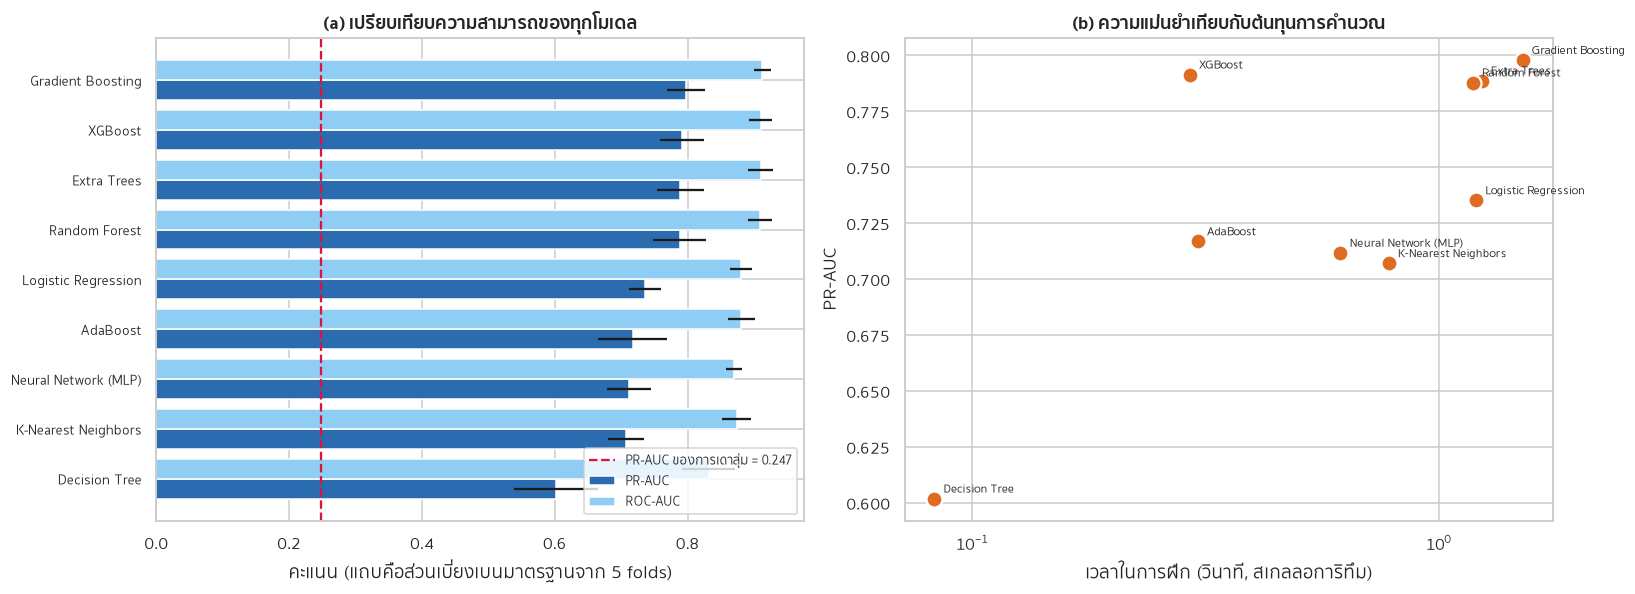

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = cv_results.sort_values("average_precision")
ypos = np.arange(len(order))
axes[0].barh(ypos - 0.2, order.average_precision, height=0.4,
             xerr=order.average_precision_std, color="#2b6cb0", label="PR-AUC")
axes[0].barh(ypos + 0.2, order.roc_auc, height=0.4,
             xerr=order.roc_auc_std, color="#90cdf4", label="ROC-AUC")
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(order.model, fontsize=9)
axes[0].axvline(float(y_train.mean()), color="crimson", linestyle="--", linewidth=1.5,
                label=f"PR-AUC ของการเดาสุ่ม = {y_train.mean():.3f}")
axes[0].set_xlabel("คะแนน (แถบคือส่วนเบี่ยงเบนมาตรฐานจาก 5 folds)")
axes[0].set_title("(a) เปรียบเทียบความสามารถของทุกโมเดล")
axes[0].legend(loc="lower right", fontsize=8.5)

axes[1].scatter(cv_results.fit_time_sec, cv_results.average_precision,
                s=110, color="#dd6b20", edgecolors="white", linewidth=1.5, zorder=3)
for _, r in cv_results.iterrows():
    axes[1].annotate(r.model, (r.fit_time_sec, r.average_precision),
                     fontsize=8, xytext=(6, 4), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set_xlabel("เวลาในการฝึก (วินาที, สเกลลอการิทึม)")
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("(b) ความแม่นยำเทียบกับต้นทุนการคำนวณ")

fig.tight_layout()
save_fig(fig, "f11_model_comparison")
plt.show()

### ปรับจูนพารามิเตอร์ (Hyperparameter Tuning)

จูนเฉพาะ 3 โมเดลที่ทำคะแนนดีที่สุด เพราะการจูนทุกตัวใช้เวลาโดยไม่เพิ่มคุณค่า
ใช้ `RandomizedSearchCV` ซึ่งสุ่มตัวอย่างจากพื้นที่พารามิเตอร์ — คุ้มกว่า Grid Search
เมื่อพารามิเตอร์บางตัวไม่มีผลมากนัก และให้ผลใกล้เคียงกันในเวลาที่น้อยกว่ามาก

In [47]:
# Tune only the top performers; scoring on average_precision to stay aligned with
# the metric that matters for an imbalanced problem.
PARAM_SPACES = {
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300, 400],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.8, 0.9, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "Extra Trees": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 8],
    },
}

top3 = [m for m in cv_results.model.head(3) if m in PARAM_SPACES]
tuned = {}
tuning_rows = []

for name in top3:
    base_est, needs_scaling = MODELS[name]
    pipe = Pipeline([("prep", make_preprocessor(scale=needs_scaling)),
                     ("model", base_est)])
    search = RandomizedSearchCV(pipe, PARAM_SPACES[name], n_iter=25, cv=cv,
                                scoring="average_precision", n_jobs=-1,
                                random_state=RANDOM_STATE)
    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    before = float(cv_results.loc[cv_results.model == name, "average_precision"].iloc[0])
    tuned[name] = search.best_estimator_
    tuning_rows.append({
        "โมเดล": name,
        "PR-AUC ก่อนจูน": round(before, 4),
        "PR-AUC หลังจูน": round(float(search.best_score_), 4),
        "เปลี่ยนแปลง": round(float(search.best_score_) - before, 4),
        "เวลาที่ใช้ (วินาที)": round(elapsed, 1),
    })
    print(f"{name}: {before:.4f} -> {search.best_score_:.4f} "
          f"({search.best_score_ - before:+.4f}) ใน {elapsed:.0f} วินาที")
    print(f"  พารามิเตอร์ที่ดีที่สุด: "
          f"{ {k.replace('model__',''): v for k, v in search.best_params_.items()} }")

tuning_df = pd.DataFrame(tuning_rows)
save_table(tuning_df, "t19_tuning_results")
rv("churn_tuned_models", top3)
rv("churn_tuning_results", tuning_df.to_dict("records"))
tuning_df

Gradient Boosting: 0.7979 -> 0.8047 (+0.0068) ใน 34 วินาที
  พารามิเตอร์ที่ดีที่สุด: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.03}


XGBoost: 0.7914 -> 0.8101 (+0.0187) ใน 7 วินาที
  พารามิเตอร์ที่ดีที่สุด: {'subsample': 0.85, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


Extra Trees: 0.7887 -> 0.7858 (-0.0029) ใน 10 วินาที
  พารามิเตอร์ที่ดีที่สุด: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': None}


,โมเดล,PR-AUC ก่อนจูน,PR-AUC หลังจูน,เปลี่ยนแปลง,เวลาที่ใช้ (วินาที)
0,Gradient Boosting,0.7979,0.8047,0.0068,34.0
1,XGBoost,0.7914,0.8101,0.0187,6.8
2,Extra Trees,0.7887,0.7858,-0.0029,10.2


In [48]:
# Stacking: can combining the tuned models beat the best single one?
# Report the answer honestly either way - a negative result is still a result.
stack_bases = [(n.lower().replace(" ", "_")[:12], tuned[n]) for n in top3]
stacking = StackingClassifier(
    estimators=stack_bases,
    final_estimator=LogisticRegression(max_iter=3000, class_weight="balanced",
                                       random_state=RANDOM_STATE),
    cv=cv, n_jobs=-1)

t0 = time.perf_counter()
stack_scores = cross_validate(stacking, X_train, y_train, cv=cv,
                              scoring=SCORING, n_jobs=-1)
stack_time = time.perf_counter() - t0
stack_prauc = float(stack_scores["test_average_precision"].mean())

best_tuned_name = max(tuned, key=lambda n: tuning_df.set_index("โมเดล").loc[n, "PR-AUC หลังจูน"])
best_tuned_prauc = float(tuning_df.set_index("โมเดล").loc[best_tuned_name, "PR-AUC หลังจูน"])
stack_gain = stack_prauc - best_tuned_prauc
stack_helps = stack_gain > 0.005  # meaningful improvement threshold

rv("churn_stacking_prauc", round(stack_prauc, 4))
rv("churn_stacking_gain", round(stack_gain, 4))
rv("churn_stacking_helps", bool(stack_helps))
rv("churn_stacking_time_sec", round(stack_time, 1))
rv("churn_best_tuned_model", best_tuned_name)
rv("churn_best_tuned_prauc", round(best_tuned_prauc, 4))

print(f"โมเดลเดี่ยวที่ดีที่สุดหลังจูน: {best_tuned_name} — PR-AUC {best_tuned_prauc:.4f}")
print(f"Stacking ({len(stack_bases)} โมเดล)            — PR-AUC {stack_prauc:.4f}")
print(f"ส่วนต่าง: {stack_gain:+.4f}   (ใช้เวลาฝึก {stack_time:.0f} วินาที)")
print()
if stack_helps:
    print("สรุป: Stacking ช่วยได้จริงอย่างมีนัยสำคัญ -> เลือก Stacking เป็นแชมป์")
else:
    print("สรุป: Stacking ไม่ได้ช่วยอย่างมีนัยสำคัญ (เกณฑ์ที่ตั้งไว้คือต้องดีขึ้นเกิน 0.005)")
    print()
    print("เหตุผลที่อธิบายได้: โมเดลฐานทั้งสามเป็นตระกูล tree-based ที่เรียนรู้จาก")
    print("ฟีเจอร์ชุดเดียวกัน จึงทำนายผิดที่ 'ลูกค้ากลุ่มเดียวกัน' — Stacking ได้ประโยชน์")
    print("เมื่อโมเดลฐานผิดคนละแบบและมาเติมเต็มกัน ซึ่งไม่ใช่กรณีนี้")
    print()
    print("-> เลือกโมเดลเดี่ยวเป็นแชมป์ เพราะได้ความแม่นเท่ากันแต่เร็วกว่า")
    print("   อธิบายง่ายกว่า และดูแลรักษาในระบบจริงง่ายกว่ามาก")

โมเดลเดี่ยวที่ดีที่สุดหลังจูน: XGBoost — PR-AUC 0.8101
Stacking (3 โมเดล)            — PR-AUC 0.8104
ส่วนต่าง: +0.0003   (ใช้เวลาฝึก 12 วินาที)

สรุป: Stacking ไม่ได้ช่วยอย่างมีนัยสำคัญ (เกณฑ์ที่ตั้งไว้คือต้องดีขึ้นเกิน 0.005)

เหตุผลที่อธิบายได้: โมเดลฐานทั้งสามเป็นตระกูล tree-based ที่เรียนรู้จาก
ฟีเจอร์ชุดเดียวกัน จึงทำนายผิดที่ 'ลูกค้ากลุ่มเดียวกัน' — Stacking ได้ประโยชน์
เมื่อโมเดลฐานผิดคนละแบบและมาเติมเต็มกัน ซึ่งไม่ใช่กรณีนี้

-> เลือกโมเดลเดี่ยวเป็นแชมป์ เพราะได้ความแม่นเท่ากันแต่เร็วกว่า
   อธิบายง่ายกว่า และดูแลรักษาในระบบจริงง่ายกว่ามาก


In [49]:
# Lock in the champion (best predictive ranking) and the explainers (interpretability)
if stack_helps:
    champion_name = "Stacking Ensemble"
    champion = stacking
else:
    champion_name = best_tuned_name
    champion = tuned[best_tuned_name]

champion.fit(X_train, y_train)

# Explainers are trained on the same data so their story matches the champion's world
explainer_lr = Pipeline([("prep", make_preprocessor(scale=True)),
                         ("model", LogisticRegression(max_iter=3000,
                                                      class_weight="balanced",
                                                      random_state=RANDOM_STATE))])
explainer_lr.fit(X_train, y_train)

explainer_dt = Pipeline([("prep", make_preprocessor(scale=False)),
                         ("model", DecisionTreeClassifier(max_depth=4,
                                                          class_weight="balanced",
                                                          min_samples_leaf=30,
                                                          random_state=RANDOM_STATE))])
explainer_dt.fit(X_train, y_train)

rv("churn_champion_model", champion_name)
print(f"แชมป์ (ใช้ทำนาย)     : {champion_name}")
print(f"ผู้อธิบาย (ใช้ตีความ) : Logistic Regression + Decision Tree (max_depth=4)")
print()
print("ทั้งสามโมเดลฝึกบนข้อมูลชุดเดียวกัน เพื่อให้คำอธิบายสอดคล้องกับตัวที่ใช้ทำนายจริง")

แชมป์ (ใช้ทำนาย)     : XGBoost
ผู้อธิบาย (ใช้ตีความ) : Logistic Regression + Decision Tree (max_depth=4)

ทั้งสามโมเดลฝึกบนข้อมูลชุดเดียวกัน เพื่อให้คำอธิบายสอดคล้องกับตัวที่ใช้ทำนายจริง


---
# §5 Evaluation

ประเมินผลบนชุดทดสอบที่โมเดลไม่เคยเห็น แล้วตอบคำถามผู้บริหารทั้ง 3 ข้อ
พร้อมระบุข้อจำกัดที่ต้องรู้ก่อนนำไปใช้จริง

## 5.1 ประสิทธิภาพของแชมป์บนชุดทดสอบ

In [50]:
# First look at the held-out test set - the honest estimate of real-world performance
y_proba = champion.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

test_roc = float(roc_auc_score(y_test, y_proba))
test_pr = float(average_precision_score(y_test, y_proba))

rv("eval_test_roc_auc", round(test_roc, 4))
rv("eval_test_pr_auc", round(test_pr, 4))
rv("eval_test_recall_at_050", round(float(recall_score(y_test, y_pred_default)), 4))
rv("eval_test_precision_at_050", round(float(precision_score(y_test, y_pred_default)), 4))
rv("eval_test_f1_at_050", round(float(f1_score(y_test, y_pred_default)), 4))
rv("eval_test_accuracy_at_050", round(float(accuracy_score(y_test, y_pred_default)), 4))
rv("eval_random_baseline_pr_auc", round(float(y_test.mean()), 4))

print(f"ผลของ {champion_name} บนชุดทดสอบ {len(X_test):,} ราย (ไม่เคยเห็นมาก่อน)")
print("=" * 70)
print(f"  ROC-AUC : {test_roc:.4f}")
print(f"  PR-AUC  : {test_pr:.4f}   (การเดาสุ่มได้ {y_test.mean():.4f})")
print(f"  -> ดีกว่าการเดาสุ่ม {test_pr/y_test.mean():.1f} เท่า")
print()
print(f"ที่เกณฑ์เริ่มต้น 0.5:")
print(f"  Recall    : {recall_score(y_test, y_pred_default):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_default):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_default):.4f}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_default):.4f}")

ผลของ XGBoost บนชุดทดสอบ 600 ราย (ไม่เคยเห็นมาก่อน)
  ROC-AUC : 0.9217
  PR-AUC  : 0.8069   (การเดาสุ่มได้ 0.2483)
  -> ดีกว่าการเดาสุ่ม 3.2 เท่า

ที่เกณฑ์เริ่มต้น 0.5:
  Recall    : 0.7852
  Precision : 0.6964
  F1        : 0.7382
  Accuracy  : 0.8617


## 5.2 เลือกเกณฑ์ตัดสิน (Threshold) จากต้นทุนทางธุรกิจ ไม่ใช่ค่าเริ่มต้น 0.5

เกณฑ์ 0.5 เป็นค่าเริ่มต้นทางคณิตศาสตร์ ไม่ใช่ค่าที่เหมาะกับธุรกิจ เพราะ **ความผิดพลาด 2 แบบมีต้นทุนไม่เท่ากัน**

| ความผิดพลาด | เกิดอะไรขึ้น | ต้นทุน |
|---|---|---|
| **False Positive** — ทายว่าจะหาย แต่จริง ๆ ยังอยู่ | ส่งคูปองให้คนที่ไม่ได้จะไปไหน | **ต่ำ** — เสียแค่ค่าคูปอง |
| **False Negative** — ทายว่ายังอยู่ แต่จริง ๆ กำลังจะหาย | ไม่ได้ทำอะไรเลย แล้วลูกค้าหายไปจริง | **สูง** — เสียกำไรทั้งอนาคตของลูกค้ารายนั้น |

ยิ่ง FN แพงกว่า FP มากเท่าไร เกณฑ์ที่เหมาะสมยิ่งควรต่ำลง เพื่อยอมรับ FP เพิ่มขึ้นแลกกับการพลาด FN น้อยลง
เราจะ **คำนวณหาเกณฑ์จากตัวเลขจริง** ไม่ใช่กำหนดล่วงหน้า แล้วทดสอบว่าคำตอบไวต่อสมมติฐานแค่ไหน

In [51]:
# Business assumptions - stated explicitly so a reader can challenge or replace them
COST_COUPON = 150.0            # THB spent per customer we choose to contact
MARGIN_RATE = 0.25             # gross margin on retail revenue
CAMPAIGN_SUCCESS_RATE = 0.30   # share of genuinely at-risk customers a campaign wins back
RETENTION_HORIZON_QUARTERS = 4 # losing a customer costs their FUTURE value, not one quarter

# Value of saving one at-risk customer = margin on the revenue they would still generate
# over the retention horizon. Use the median 90-day spend of retained customers as a
# conservative per-quarter proxy.
active_customers = modeling_df[modeling_df[TARGET] == 0]
median_90d_spend = float(active_customers.spend_90d.median())
VALUE_SAVED = (median_90d_spend * RETENTION_HORIZON_QUARTERS
               * MARGIN_RATE * CAMPAIGN_SUCCESS_RATE)

rv("eval_cost_coupon_thb", COST_COUPON)
rv("eval_margin_rate", MARGIN_RATE)
rv("eval_campaign_success_rate", CAMPAIGN_SUCCESS_RATE)
rv("eval_retention_horizon_quarters", RETENTION_HORIZON_QUARTERS)
rv("eval_median_90d_spend_thb", round(median_90d_spend, 2))
rv("eval_value_per_saved_customer_thb", round(VALUE_SAVED, 2))
rv("eval_fn_fp_cost_ratio", round(VALUE_SAVED / COST_COUPON, 2))

print("สมมติฐานทางธุรกิจที่ใช้ (ปรับได้ตามข้อมูลจริงของบริษัท):")
print(f"  ต้นทุนคูปองต่อคนที่ติดต่อ         : {COST_COUPON:,.0f} บาท")
print(f"  อัตรากำไรขั้นต้น                 : {MARGIN_RATE:.0%}")
print(f"  อัตราความสำเร็จของแคมเปญ         : {CAMPAIGN_SUCCESS_RATE:.0%}")
print(f"  ยอดซื้อ 90 วันของลูกค้าที่ยังอยู่  : {median_90d_spend:,.0f} บาท (มัธยฐาน)")
print(f"  ระยะเวลาที่นับมูลค่าอนาคต         : {RETENTION_HORIZON_QUARTERS} ไตรมาส (1 ปี)")
print()
print(f"  -> มูลค่าที่ได้จากการรักษาลูกค้าไว้ 1 ราย = {VALUE_SAVED:,.0f} บาท")
print(f"  -> อัตราส่วนต้นทุน FN : FP = {VALUE_SAVED/COST_COUPON:.1f} : 1")
print()
print("หมายเหตุสำคัญเรื่องการเลือกระยะเวลา:")
print("  ถ้านับมูลค่าเพียง 1 ไตรมาส จะได้อัตราส่วนเพียง "
      f"{median_90d_spend*MARGIN_RATE*CAMPAIGN_SUCCESS_RATE/COST_COUPON:.1f} : 1")
print("  ซึ่งจะทำให้โมเดลระมัดระวังเกินไปและปล่อยลูกค้าหลุดจำนวนมาก")
print("  แต่การเสียลูกค้าคือการเสียรายได้ 'ทั้งอนาคต' ไม่ใช่แค่ไตรมาสเดียว")
print("  จึงนับที่ 1 ปีซึ่งยังถือว่าอนุรักษ์นิยม -- §5.2.1 จะทดสอบความไวต่อสมมติฐานนี้"
      )

สมมติฐานทางธุรกิจที่ใช้ (ปรับได้ตามข้อมูลจริงของบริษัท):
  ต้นทุนคูปองต่อคนที่ติดต่อ         : 150 บาท
  อัตรากำไรขั้นต้น                 : 25%
  อัตราความสำเร็จของแคมเปญ         : 30%
  ยอดซื้อ 90 วันของลูกค้าที่ยังอยู่  : 3,108 บาท (มัธยฐาน)
  ระยะเวลาที่นับมูลค่าอนาคต         : 4 ไตรมาส (1 ปี)

  -> มูลค่าที่ได้จากการรักษาลูกค้าไว้ 1 ราย = 932 บาท
  -> อัตราส่วนต้นทุน FN : FP = 6.2 : 1

หมายเหตุสำคัญเรื่องการเลือกระยะเวลา:
  ถ้านับมูลค่าเพียง 1 ไตรมาส จะได้อัตราส่วนเพียง 1.6 : 1
  ซึ่งจะทำให้โมเดลระมัดระวังเกินไปและปล่อยลูกค้าหลุดจำนวนมาก
  แต่การเสียลูกค้าคือการเสียรายได้ 'ทั้งอนาคต' ไม่ใช่แค่ไตรมาสเดียว
  จึงนับที่ 1 ปีซึ่งยังถือว่าอนุรักษ์นิยม -- §5.2.1 จะทดสอบความไวต่อสมมติฐานนี้


In [52]:
# Sweep every threshold and compute the expected net value of the campaign
thresholds = np.linspace(0.05, 0.95, 181)
rows = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    contacted = tp + fp
    net_value = tp * VALUE_SAVED - contacted * COST_COUPON
    rows.append({
        "threshold": float(t),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "contacted": int(contacted),
        "recall": tp / (tp + fn) if (tp + fn) else 0.0,
        "precision": tp / contacted if contacted else 0.0,
        "f1": float(f1_score(y_test, pred, zero_division=0)),
        "net_value": float(net_value),
    })

thr_df = pd.DataFrame(rows)
save_table(thr_df, "t20_threshold_sweep")

best_value_row = thr_df.loc[thr_df.net_value.idxmax()]
best_f1_row = thr_df.loc[thr_df.f1.idxmax()]
default_row = thr_df.iloc[(thr_df.threshold - 0.5).abs().idxmin()]

THRESHOLD = float(best_value_row.threshold)

rv("eval_threshold_chosen", round(THRESHOLD, 3))
rv("eval_threshold_best_f1", round(float(best_f1_row.threshold), 3))
rv("eval_net_value_at_chosen", round(float(best_value_row.net_value), 0))
rv("eval_net_value_at_050", round(float(default_row.net_value), 0))
rv("eval_net_value_gain_vs_050", round(float(best_value_row.net_value - default_row.net_value), 0))
rv("eval_recall_at_chosen", round(float(best_value_row.recall), 4))
rv("eval_precision_at_chosen", round(float(best_value_row.precision), 4))
rv("eval_contacted_at_chosen", int(best_value_row.contacted))
rv("eval_contacted_at_050", int(default_row.contacted))

comparison = pd.DataFrame([
    {"เกณฑ์": "ค่าเริ่มต้น 0.5", "threshold": float(default_row.threshold),
     "ติดต่อ (ราย)": int(default_row.contacted), "จับได้ (TP)": int(default_row.tp),
     "พลาด (FN)": int(default_row.fn), "Recall": float(default_row.recall),
     "Precision": float(default_row.precision), "มูลค่าสุทธิ (บาท)": float(default_row.net_value)},
    {"เกณฑ์": "F1 สูงสุด", "threshold": float(best_f1_row.threshold),
     "ติดต่อ (ราย)": int(best_f1_row.contacted), "จับได้ (TP)": int(best_f1_row.tp),
     "พลาด (FN)": int(best_f1_row.fn), "Recall": float(best_f1_row.recall),
     "Precision": float(best_f1_row.precision), "มูลค่าสุทธิ (บาท)": float(best_f1_row.net_value)},
    {"เกณฑ์": "มูลค่าสุทธิสูงสุด (เลือกใช้)", "threshold": THRESHOLD,
     "ติดต่อ (ราย)": int(best_value_row.contacted), "จับได้ (TP)": int(best_value_row.tp),
     "พลาด (FN)": int(best_value_row.fn), "Recall": float(best_value_row.recall),
     "Precision": float(best_value_row.precision), "มูลค่าสุทธิ (บาท)": float(best_value_row.net_value)},
])
save_table(comparison, "t21_threshold_comparison")

print(f"เกณฑ์ที่เลือกใช้: {THRESHOLD:.3f} (จากการหาค่ามูลค่าสุทธิสูงสุด)")
print()
comparison.style.format({"threshold": "{:.3f}", "Recall": "{:.1%}",
                         "Precision": "{:.1%}", "มูลค่าสุทธิ (บาท)": "{:,.0f}"}).hide(axis="index")

เกณฑ์ที่เลือกใช้: 0.345 (จากการหาค่ามูลค่าสุทธิสูงสุด)



เกณฑ์,threshold,ติดต่อ (ราย),จับได้ (TP),พลาด (FN),Recall,Precision,มูลค่าสุทธิ (บาท)
ค่าเริ่มต้น 0.5,0.500,168,117,32,78.5%,69.6%,"83,886"
F1 สูงสุด,0.455,178,123,26,82.6%,69.1%,"87,980"
มูลค่าสุทธิสูงสุด (เลือกใช้),0.345,213,132,17,88.6%,62.0%,"91,122"


### 5.2.1 ทดสอบความไวต่อสมมติฐาน (Sensitivity Analysis)

เกณฑ์ที่เลือกขึ้นอยู่กับสมมติฐานต้นทุนที่เราตั้งขึ้นเอง จึงต้องตอบให้ได้ว่า
**ถ้าสมมติฐานผิด คำตอบจะเปลี่ยนไปมากแค่ไหน** — ถ้าเปลี่ยนน้อยก็เชื่อถือได้ ถ้าเปลี่ยนมากต้องระวัง

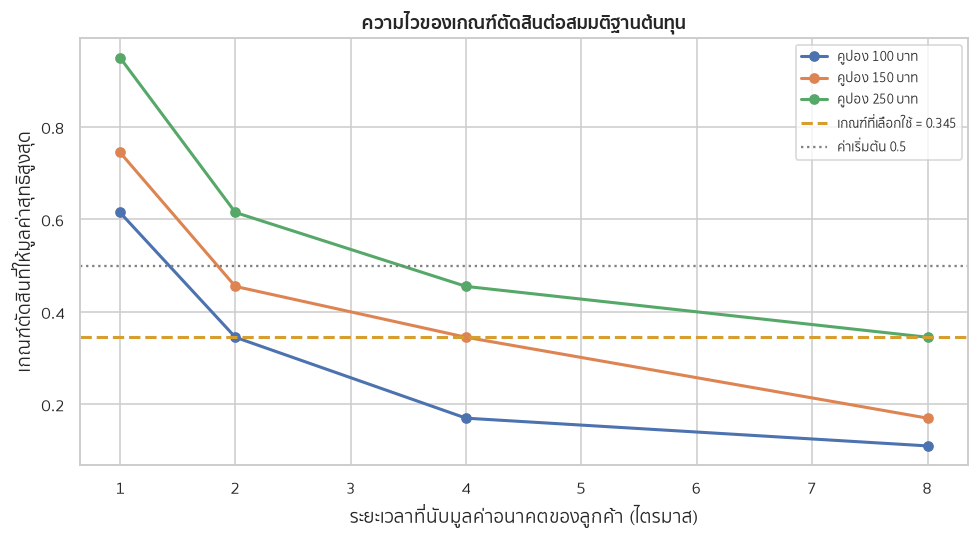

เกณฑ์ที่เหมาะสมเคลื่อนไหวอยู่ในช่วง 0.110 - 0.950 ตามสมมติฐานที่ทดสอบ 12 ชุด

ข้อสรุปที่ต้องบอกผู้บริหาร: เกณฑ์ไม่ใช่ค่าคงที่ทางเทคนิค แต่เป็น 'ปุ่มปรับเชิงนโยบาย'
ยิ่งประเมินมูลค่าลูกค้าในระยะยาวสูงเท่าไร ยิ่งควรหว่านแหกว้างขึ้นเท่านั้น
ตัวเลขจริงจากฝ่ายการเงินจะเป็นตัวกำหนดเกณฑ์สุดท้าย ไม่ใช่ค่าที่เราสมมติในสมุดเล่มนี้


,ระยะเวลา (ไตรมาส),ค่าคูปอง (บาท),มูลค่าต่อรายที่รักษาได้,อัตราส่วน FN:FP,เกณฑ์ที่เหมาะสม,Recall ที่ได้,มูลค่าสุทธิ (บาท)
0,1,100.0,233.0,2.3,0.615,0.725,11274.0
1,1,150.0,233.0,1.6,0.745,0.577,5046.0
2,1,250.0,233.0,0.9,0.950,0.168,-923.0
3,2,100.0,466.0,4.7,0.345,0.886,40236.0
4,2,150.0,466.0,3.1,0.455,0.826,30640.0
5,2,250.0,466.0,1.9,0.615,0.725,15597.0
6,4,100.0,932.0,9.3,0.170,0.953,101995.0
7,4,150.0,932.0,6.2,0.345,0.886,91122.0
8,4,250.0,932.0,3.7,0.455,0.826,70180.0
9,8,100.0,1865.0,18.6,0.110,0.973,236185.0


In [53]:
# How much does the recommended threshold move if our cost assumptions are wrong?
sens_rows = []
for horizon in (1, 2, 4, 8):
    for coupon in (100.0, 150.0, 250.0):
        value = median_90d_spend * horizon * MARGIN_RATE * CAMPAIGN_SUCCESS_RATE
        best_t, best_v, best_recall = None, -np.inf, None
        for t in thresholds:
            pred = (y_proba >= t).astype(int)
            tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
            net = tp_ * value - (tp_ + fp_) * coupon
            if net > best_v:
                best_t, best_v = float(t), float(net)
                best_recall = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0
        sens_rows.append({
            "ระยะเวลา (ไตรมาส)": horizon,
            "ค่าคูปอง (บาท)": coupon,
            "มูลค่าต่อรายที่รักษาได้": round(value, 0),
            "อัตราส่วน FN:FP": round(value / coupon, 1),
            "เกณฑ์ที่เหมาะสม": round(best_t, 3),
            "Recall ที่ได้": round(best_recall, 3),
            "มูลค่าสุทธิ (บาท)": round(best_v, 0),
        })

sens_df = pd.DataFrame(sens_rows)
save_table(sens_df, "t21b_threshold_sensitivity")
rv("eval_sensitivity_table", sens_df.to_dict("records"))
rv("eval_sensitivity_threshold_min", round(float(sens_df["เกณฑ์ที่เหมาะสม"].min()), 3))
rv("eval_sensitivity_threshold_max", round(float(sens_df["เกณฑ์ที่เหมาะสม"].max()), 3))

fig, ax = plt.subplots(figsize=(9, 5))
for coupon, grp in sens_df.groupby("ค่าคูปอง (บาท)"):
    ax.plot(grp["ระยะเวลา (ไตรมาส)"], grp["เกณฑ์ที่เหมาะสม"], marker="o",
            linewidth=2, label=f"คูปอง {coupon:,.0f} บาท")
ax.axhline(THRESHOLD, color="#d69e2e", linestyle="--", linewidth=2,
           label=f"เกณฑ์ที่เลือกใช้ = {THRESHOLD:.3f}")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.5, label="ค่าเริ่มต้น 0.5")
ax.set_xlabel("ระยะเวลาที่นับมูลค่าอนาคตของลูกค้า (ไตรมาส)")
ax.set_ylabel("เกณฑ์ตัดสินที่ให้มูลค่าสุทธิสูงสุด")
ax.set_title("ความไวของเกณฑ์ตัดสินต่อสมมติฐานต้นทุน", fontweight="bold")
ax.legend(fontsize=8.5)
fig.tight_layout()
save_fig(fig, "f12b_threshold_sensitivity")
plt.show()

print(f"เกณฑ์ที่เหมาะสมเคลื่อนไหวอยู่ในช่วง "
      f"{sens_df['เกณฑ์ที่เหมาะสม'].min():.3f} - {sens_df['เกณฑ์ที่เหมาะสม'].max():.3f} "
      f"ตามสมมติฐานที่ทดสอบ {len(sens_df)} ชุด")
print()
print("ข้อสรุปที่ต้องบอกผู้บริหาร: เกณฑ์ไม่ใช่ค่าคงที่ทางเทคนิค แต่เป็น 'ปุ่มปรับเชิงนโยบาย'")
print("ยิ่งประเมินมูลค่าลูกค้าในระยะยาวสูงเท่าไร ยิ่งควรหว่านแหกว้างขึ้นเท่านั้น")
print("ตัวเลขจริงจากฝ่ายการเงินจะเป็นตัวกำหนดเกณฑ์สุดท้าย ไม่ใช่ค่าที่เราสมมติในสมุดเล่มนี้")
sens_df

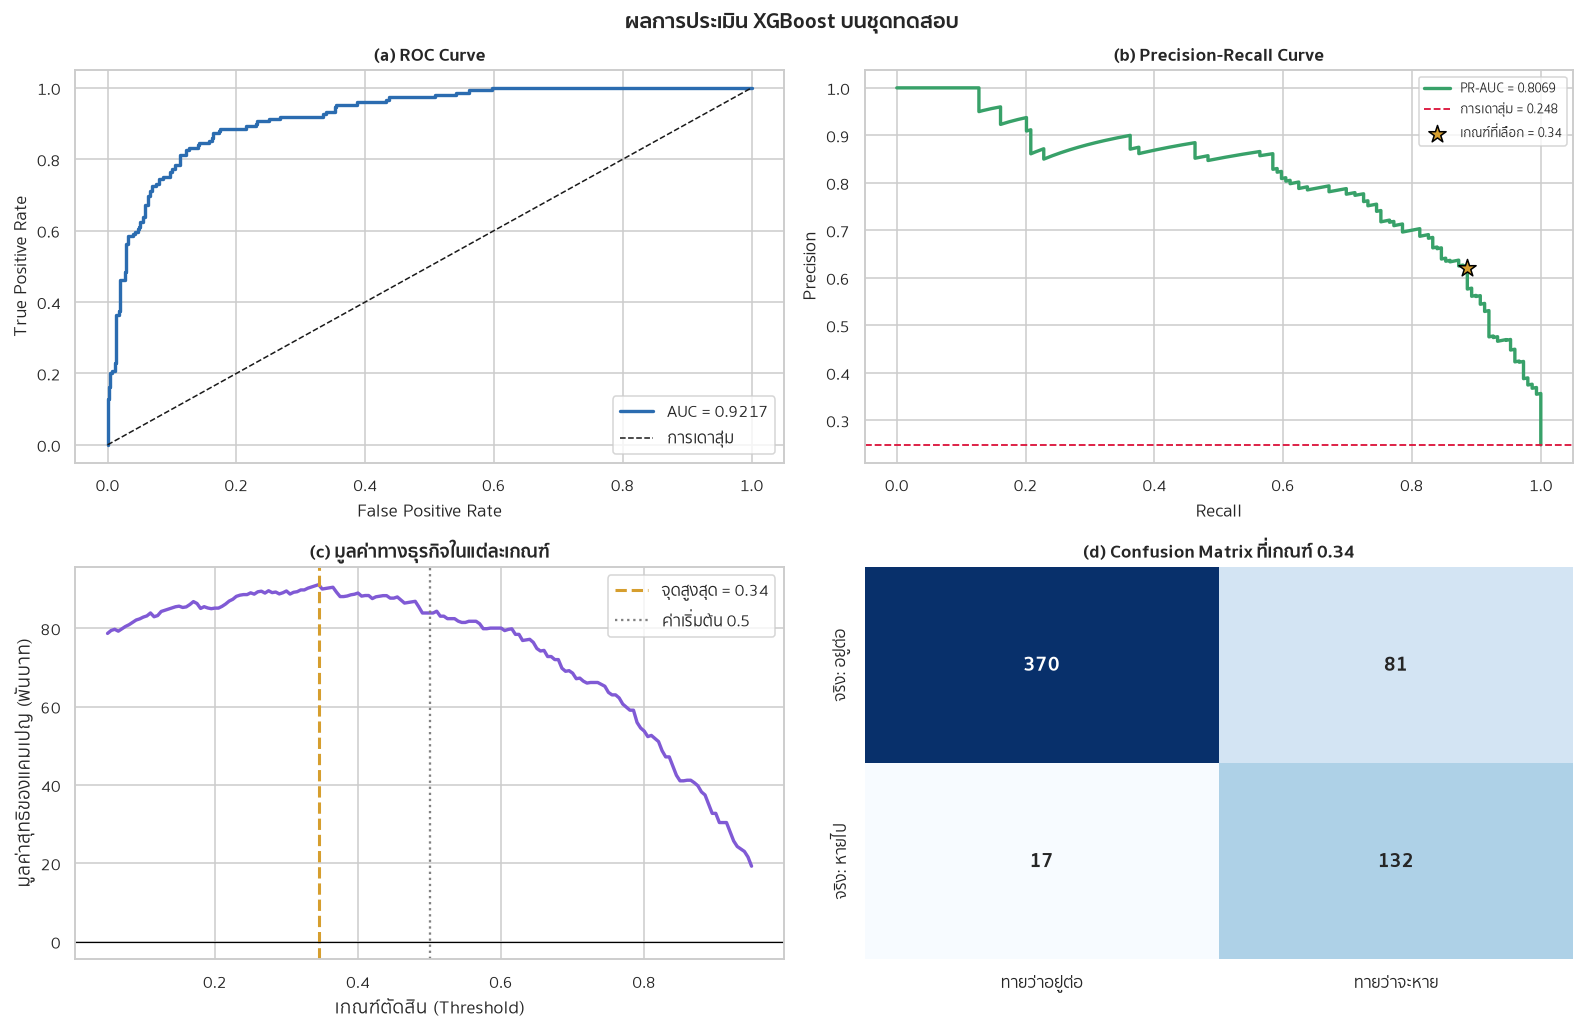

ที่เกณฑ์ 0.345: จับลูกค้าที่กำลังจะหายได้ 132 จาก 149 ราย (88.6%) โดยติดต่อทั้งหมด 213 ราย


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.5))

# (a) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, linewidth=2.2, color="#2b6cb0", label=f"AUC = {test_roc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", linewidth=1, label="การเดาสุ่ม")
axes[0, 0].set_xlabel("False Positive Rate"); axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("(a) ROC Curve"); axes[0, 0].legend()

# (b) Precision-Recall curve - the more informative view for imbalanced data
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec, linewidth=2.2, color="#38a169", label=f"PR-AUC = {test_pr:.4f}")
axes[0, 1].axhline(float(y_test.mean()), color="crimson", linestyle="--", linewidth=1.2,
                   label=f"การเดาสุ่ม = {y_test.mean():.3f}")
axes[0, 1].scatter([best_value_row.recall], [best_value_row.precision], s=140, marker="*",
                   color="#d69e2e", edgecolors="black", zorder=5,
                   label=f"เกณฑ์ที่เลือก = {THRESHOLD:.2f}")
axes[0, 1].set_xlabel("Recall"); axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("(b) Precision-Recall Curve"); axes[0, 1].legend(fontsize=8.5)

# (c) Net business value across thresholds
axes[1, 0].plot(thr_df.threshold, thr_df.net_value / 1000, linewidth=2.2, color="#805ad5")
axes[1, 0].axvline(THRESHOLD, color="#d69e2e", linestyle="--", linewidth=2,
                   label=f"จุดสูงสุด = {THRESHOLD:.2f}")
axes[1, 0].axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="ค่าเริ่มต้น 0.5")
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_xlabel("เกณฑ์ตัดสิน (Threshold)")
axes[1, 0].set_ylabel("มูลค่าสุทธิของแคมเปญ (พันบาท)")
axes[1, 0].set_title("(c) มูลค่าทางธุรกิจในแต่ละเกณฑ์")
axes[1, 0].legend()

# (d) Confusion matrix at the chosen threshold
y_pred_final = (y_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1],
            xticklabels=["ทายว่าอยู่ต่อ", "ทายว่าจะหาย"],
            yticklabels=["จริง: อยู่ต่อ", "จริง: หายไป"], cbar=False,
            annot_kws={"fontsize": 13, "fontweight": "bold"})
axes[1, 1].set_title(f"(d) Confusion Matrix ที่เกณฑ์ {THRESHOLD:.2f}")

fig.suptitle(f"ผลการประเมิน {champion_name} บนชุดทดสอบ", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f12_evaluation")
plt.show()

tn, fp, fn, tp = cm.ravel()
rv("eval_cm_tn", int(tn)); rv("eval_cm_fp", int(fp))
rv("eval_cm_fn", int(fn)); rv("eval_cm_tp", int(tp))
print(f"ที่เกณฑ์ {THRESHOLD:.3f}: จับลูกค้าที่กำลังจะหายได้ {tp} จาก {tp+fn} ราย "
      f"({tp/(tp+fn):.1%}) โดยติดต่อทั้งหมด {tp+fp} ราย")

## 5.3 พฤติกรรมใดเป็นสัญญาณเตือน — คำตอบครึ่งหลังของโจทย์ที่ 3

ใช้ 3 มุมมองที่เป็นอิสระต่อกัน ถ้าทั้งสามชี้ไปทางเดียวกัน ความมั่นใจก็สูงขึ้นมาก

1. **Permutation Importance** บนแชมป์ — วัดว่าถ้าสลับค่าฟีเจอร์นั้นแบบสุ่ม โมเดลแย่ลงแค่ไหน
2. **Logistic Regression Coefficients** — บอก**ทิศทาง** ว่าฟีเจอร์นั้นเพิ่มหรือลดความเสี่ยง
3. **Decision Tree** — ให้**กฎที่อ่านออก**และเอาไปเขียนเป็นนโยบายได้

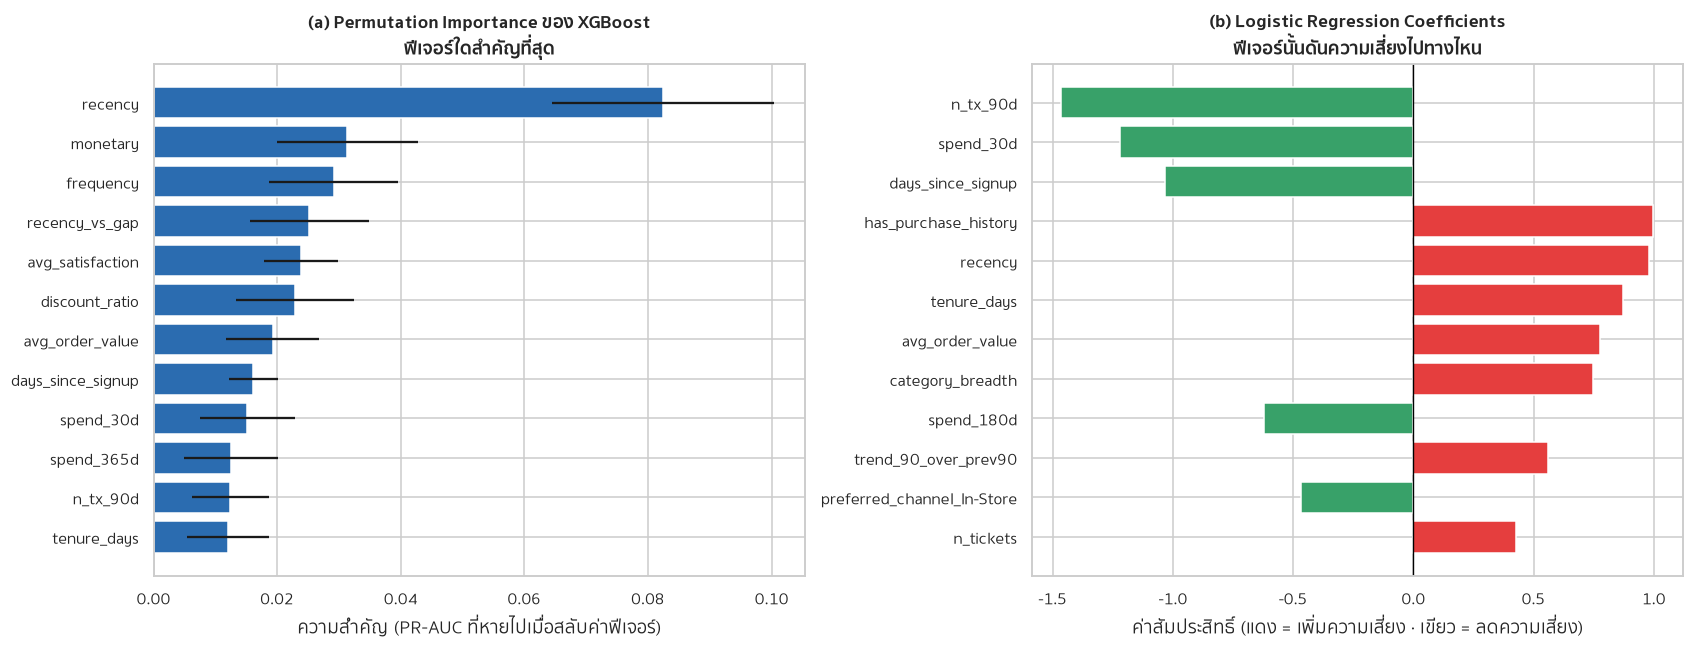

In [55]:
# 1) Permutation importance on the champion, scored on the metric we actually care about
perm = permutation_importance(champion, X_test, y_test, n_repeats=15,
                              random_state=RANDOM_STATE, scoring="average_precision",
                              n_jobs=-1)
perm_df = (pd.DataFrame({"feature": FEATURE_COLS,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False)
           .reset_index(drop=True))
save_table(perm_df, "t22_permutation_importance")

# 2) Logistic regression coefficients give the DIRECTION of each effect
lr_model = explainer_lr.named_steps["model"]
lr_feature_names = explainer_lr.named_steps["prep"].get_feature_names_out()
coef_df = (pd.DataFrame({"feature": [f.split("__", 1)[-1] for f in lr_feature_names],
                         "coefficient": lr_model.coef_[0]})
           .assign(abs_coef=lambda d: d.coefficient.abs(),
                   odds_ratio=lambda d: np.exp(d.coefficient))
           .sort_values("abs_coef", ascending=False)
           .reset_index(drop=True))
save_table(coef_df, "t23_logreg_coefficients")

rv("eval_top_features_permutation", perm_df.head(10).feature.tolist())
rv("eval_top_feature", str(perm_df.feature.iloc[0]))
rv("eval_top_feature_importance", round(float(perm_df.importance.iloc[0]), 4))

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))

top_perm = perm_df.head(12).iloc[::-1]
axes[0].barh(top_perm.feature, top_perm.importance, xerr=top_perm["std"], color="#2b6cb0")
axes[0].set_xlabel("ความสำคัญ (PR-AUC ที่หายไปเมื่อสลับค่าฟีเจอร์)")
axes[0].set_title(f"(a) Permutation Importance ของ {champion_name}\nฟีเจอร์ใดสำคัญที่สุด")

top_coef = coef_df.head(12).iloc[::-1]
colors = ["#e53e3e" if c > 0 else "#38a169" for c in top_coef.coefficient]
axes[1].barh(top_coef.feature, top_coef.coefficient, color=colors)
axes[1].axvline(0, color="black", linewidth=0.9)
axes[1].set_xlabel("ค่าสัมประสิทธิ์ (แดง = เพิ่มความเสี่ยง · เขียว = ลดความเสี่ยง)")
axes[1].set_title("(b) Logistic Regression Coefficients\nฟีเจอร์นั้นดันความเสี่ยงไปทางไหน")

fig.tight_layout()
save_fig(fig, "f13_feature_importance")
plt.show()

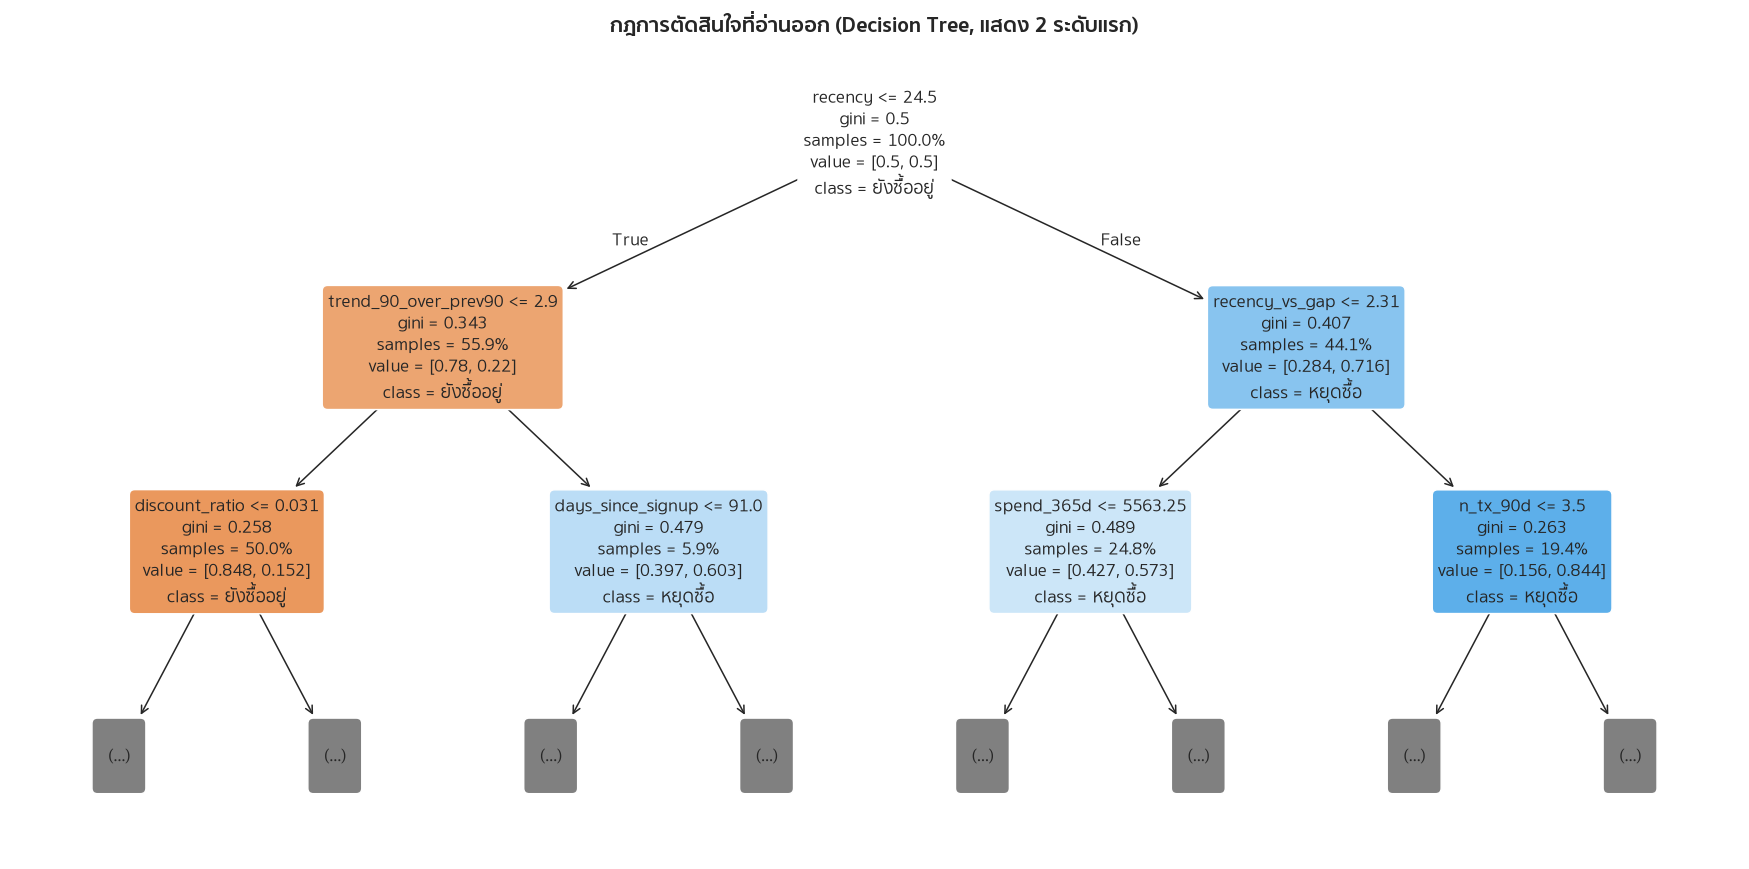

Decision Tree ที่ใช้เป็นผู้อธิบาย: ลึก 4 ระดับ · Recall บนชุดทดสอบ 73.8%
ต้นไม้นี้ไม่ได้ใช้ทำนายจริง แต่ใช้แปลงโมเดลให้เป็นกฎที่สื่อสารกับทีมธุรกิจได้


In [56]:
# 3) The decision tree turns the model into rules a manager can read and act on
fig, ax = plt.subplots(figsize=(16, 8))
dt_model = explainer_dt.named_steps["model"]
dt_features = [f.split("__", 1)[-1]
               for f in explainer_dt.named_steps["prep"].get_feature_names_out()]
# Show only the first two levels: at depth 3 the boxes shrink until they are
# unreadable once the figure is scaled into a document. The deeper rules remain
# available in the fitted model and are printed as text in the next cell.
plot_tree(dt_model, feature_names=dt_features, class_names=["ยังซื้ออยู่", "หยุดซื้อ"],
          filled=True, rounded=True, fontsize=12, max_depth=2, ax=ax, proportion=True)
ax.set_title("กฎการตัดสินใจที่อ่านออก (Decision Tree, แสดง 2 ระดับแรก)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "f14_decision_tree_rules")
plt.show()

dt_test_recall = float(recall_score(y_test, explainer_dt.predict(X_test)))
rv("eval_explainer_dt_recall", round(dt_test_recall, 4))
rv("eval_explainer_dt_depth", int(dt_model.get_depth()))
print(f"Decision Tree ที่ใช้เป็นผู้อธิบาย: ลึก {dt_model.get_depth()} ระดับ "
      f"· Recall บนชุดทดสอบ {dt_test_recall:.1%}")
print("ต้นไม้นี้ไม่ได้ใช้ทำนายจริง แต่ใช้แปลงโมเดลให้เป็นกฎที่สื่อสารกับทีมธุรกิจได้")

In [57]:
# The same tree as plain text: every rule at full depth, in a form that can be
# pasted straight into a document or handed to the business team as a checklist.
from sklearn.tree import export_text

tree_rules = export_text(dt_model, feature_names=list(dt_features),
                         decimals=2, show_weights=False)

# Translate the leaf labels into business language
tree_rules_th = (tree_rules
                 .replace("class: 1", "class: เสี่ยงหยุดซื้อ")
                 .replace("class: 0", "class: ยังซื้ออยู่"))

with open(TBL_DIR / "t24b_decision_tree_rules.txt", "w", encoding="utf-8") as fh:
    fh.write(tree_rules_th)
REPORT_VALUES.setdefault("_tables", []).append(
    {"path": str(TBL_DIR / "t24b_decision_tree_rules.txt"),
     "rows": tree_rules_th.count(chr(10))})

rv("eval_tree_rules_text", tree_rules_th)
rv("eval_tree_n_leaves", int(dt_model.get_n_leaves()))

print("กฎทั้งหมดจาก Decision Tree (ครบทุกระดับ):")
print("=" * 78)
print(tree_rules_th)
print("=" * 78)
print(f"รวม {dt_model.get_n_leaves()} เงื่อนไขปลายทาง (leaf)")
print("บันทึกเป็นไฟล์ข้อความไว้ที่ outputs/tables/t24b_decision_tree_rules.txt")

กฎทั้งหมดจาก Decision Tree (ครบทุกระดับ):
|--- recency <= 24.50
|   |--- trend_90_over_prev90 <= 2.90
|   |   |--- discount_ratio <= 0.03
|   |   |   |--- gap_std <= 29.04
|   |   |   |   |--- class: ยังซื้ออยู่
|   |   |   |--- gap_std >  29.04
|   |   |   |   |--- class: ยังซื้ออยู่
|   |   |--- discount_ratio >  0.03
|   |   |   |--- monetary <= 9113.60
|   |   |   |   |--- class: ยังซื้ออยู่
|   |   |   |--- monetary >  9113.60
|   |   |   |   |--- class: ยังซื้ออยู่
|   |--- trend_90_over_prev90 >  2.90
|   |   |--- days_since_signup <= 91.00
|   |   |   |--- days_since_signup <= 49.50
|   |   |   |   |--- class: เสี่ยงหยุดซื้อ
|   |   |   |--- days_since_signup >  49.50
|   |   |   |   |--- class: เสี่ยงหยุดซื้อ
|   |   |--- days_since_signup >  91.00
|   |   |   |--- discount_ratio <= 0.03
|   |   |   |   |--- class: ยังซื้ออยู่
|   |   |   |--- discount_ratio >  0.03
|   |   |   |   |--- class: ยังซื้ออยู่
|--- recency >  24.50
|   |--- recency_vs_gap <= 2.31
|   |   |--- spend

In [58]:
# Cross-check the three views and translate them into business language.
# Direction comes from the model's own coefficient sign - never from an assumption
# written in advance. The notes below describe WHAT each feature measures, neutrally,
# so they cannot contradict whatever direction the data turns out to show.
top_feats = perm_df.head(10).feature.tolist()
coef_lookup = coef_df.set_index("feature").coefficient.to_dict()

FEATURE_MEANING = {
    "recency": "จำนวนวันนับจากการซื้อครั้งล่าสุด (ณ วันตัด)",
    "recency_vs_gap": "ความเงียบปัจจุบันเทียบกับจังหวะการซื้อปกติของลูกค้ารายนั้นเอง",
    "gap_mean": "ระยะห่างเฉลี่ยระหว่างการซื้อแต่ละครั้ง",
    "gap_std": "ความสม่ำเสมอของจังหวะการซื้อ (ยิ่งสูงยิ่งไม่สม่ำเสมอ)",
    "gap_max": "ช่วงที่เคยหายไปนานที่สุด",
    "trend_90_over_prev90": "ความถี่ 90 วันล่าสุด หารด้วย 90 วันก่อนหน้า",
    "trend_180_over_prev180": "ความถี่ 180 วันล่าสุด หารด้วยช่วงก่อนหน้า",
    "n_tx_30d": "จำนวนบิลใน 30 วันก่อนวันตัด",
    "n_tx_90d": "จำนวนบิลใน 90 วันก่อนวันตัด",
    "n_tx_180d": "จำนวนบิลใน 180 วันก่อนวันตัด",
    "n_tx_365d": "จำนวนบิลใน 365 วันก่อนวันตัด",
    "spend_30d": "ยอดใช้จ่ายใน 30 วันก่อนวันตัด",
    "spend_90d": "ยอดใช้จ่ายใน 90 วันก่อนวันตัด",
    "spend_180d": "ยอดใช้จ่ายใน 180 วันก่อนวันตัด",
    "spend_365d": "ยอดใช้จ่ายใน 365 วันก่อนวันตัด",
    "frequency": "จำนวนครั้งที่ซื้อทั้งหมดในช่วงฟีเจอร์",
    "monetary": "ยอดใช้จ่ายสะสมทั้งหมดในช่วงฟีเจอร์",
    "tenure_days": "จำนวนวันนับจากการซื้อครั้งแรก",
    "days_since_signup": "จำนวนวันนับจากวันสมัครสมาชิก",
    "discount_ratio": "สัดส่วนส่วนลดต่อยอดซื้อรวม",
    "category_breadth": "จำนวนหมวดสินค้าที่เคยซื้อ",
    "channel_diversity": "จำนวนช่องทางที่ใช้ซื้อ",
    "store_diversity": "จำนวนสาขาที่เคยไปซื้อ",
    "avg_satisfaction": "คะแนนความพึงพอใจเฉลี่ยจากการติดต่อฝ่ายบริการ",
    "n_tickets": "จำนวนเรื่องที่ติดต่อฝ่ายบริการ",
    "n_unresolved_tickets": "จำนวนเรื่องร้องเรียนที่ยังไม่ถูกแก้ไข",
    "avg_order_value": "มูลค่าเฉลี่ยต่อบิล",
    "std_order_value": "ความผันผวนของมูลค่าต่อบิล",
    "basket_depth": "จำนวนชิ้นเฉลี่ยต่อตะกร้า",
    "items_per_basket": "จำนวนรายการสินค้าเฉลี่ยต่อตะกร้า",
    "has_purchase_history": "มีประวัติการซื้อก่อนวันตัดหรือไม่ (0/1)",
    "age": "อายุลูกค้า",
    "city_tier": "ระดับเมืองที่อยู่อาศัย",
    "marketing_optin": "ยินยอมรับการติดต่อทางการตลาด (0/1)",
    "has_mobile_app": "ติดตั้งแอปพลิเคชันหรือไม่ (0/1)",
}

# A genuine independent check: compare each group's mean directly in the data.
# This is univariate (ignores other features) whereas the coefficient is conditional
# (holds other features constant) - so agreement is real evidence, and disagreement
# is a finding worth reporting rather than hiding.
train_df = X_train.join(y_train)
signal_rows = []
for i, feat in enumerate(top_feats, 1):
    coef = coef_lookup.get(feat)

    if feat in NUMERIC + ["has_purchase_history"]:
        mean_churn = float(train_df.loc[train_df[TARGET] == 1, feat].mean())
        mean_stay = float(train_df.loc[train_df[TARGET] == 0, feat].mean())
        uni_dir = "สูงขึ้น" if mean_churn > mean_stay else "ต่ำลง"
    else:
        mean_churn = mean_stay = np.nan
        uni_dir = "-"

    if coef is None or np.isnan(coef):
        model_dir, agreement = "-", "-"
    else:
        model_dir = "เสี่ยงมากขึ้น" if coef > 0 else "เสี่ยงน้อยลง"
        if uni_dir == "-":
            agreement = "-"
        else:
            same = (coef > 0) == (uni_dir == "สูงขึ้น")
            agreement = "สอดคล้อง" if same else "สวนทาง (ดูหมายเหตุ)"

    signal_rows.append({
        "อันดับ": i,
        "ฟีเจอร์": feat,
        "ฟีเจอร์นี้วัดอะไร": FEATURE_MEANING.get(feat, "-"),
        "ความสำคัญ": round(float(perm_df.set_index("feature").importance[feat]), 4),
        "ค่าเฉลี่ยกลุ่มที่ churn": round(mean_churn, 2) if not np.isnan(mean_churn) else None,
        "ค่าเฉลี่ยกลุ่มที่อยู่ต่อ": round(mean_stay, 2) if not np.isnan(mean_stay) else None,
        "ข้อมูลดิบชี้ว่า": f"ผู้ที่ churn มีค่านี้{uni_dir}",
        "โมเดลเชิงเส้นชี้ว่า": f"ค่าสูง -> {model_dir}",
        "การตรวจสอบไขว้": agreement,
    })

signals_df = pd.DataFrame(signal_rows)
save_table(signals_df, "t24_warning_signals")
rv("eval_warning_signals", signals_df.to_dict("records"))
rv("eval_n_signals_consistent", int((signals_df["การตรวจสอบไขว้"] == "สอดคล้อง").sum()))
rv("eval_n_signals_conflicting",
   int(signals_df["การตรวจสอบไขว้"].str.startswith("สวนทาง").sum()))

print("สัญญาณเตือน 10 อันดับแรก (เรียงตาม Permutation Importance)")
print("=" * 78)
for _, r in signals_df.iterrows():
    flag = "  <-- ต้องอธิบายเพิ่ม" if r["การตรวจสอบไขว้"].startswith("สวนทาง") else ""
    print(f"{r['อันดับ']:>2}. {r['ฟีเจอร์']}  (ความสำคัญ {r['ความสำคัญ']:.4f}){flag}")
    print(f"    วัดอะไร      : {r['ฟีเจอร์นี้วัดอะไร']}")
    if r["ค่าเฉลี่ยกลุ่มที่ churn"] is not None:
        print(f"    ข้อมูลดิบ     : churn เฉลี่ย {r['ค่าเฉลี่ยกลุ่มที่ churn']:,} "
              f"vs อยู่ต่อเฉลี่ย {r['ค่าเฉลี่ยกลุ่มที่อยู่ต่อ']:,}")
    print(f"    โมเดลเชิงเส้น : {r['โมเดลเชิงเส้นชี้ว่า']}")
    print(f"    ตรวจสอบไขว้   : {r['การตรวจสอบไขว้']}")
    print()

n_conflict = int(signals_df["การตรวจสอบไขว้"].str.startswith("สวนทาง").sum())
print("-" * 78)
print(f"สอดคล้องกัน {int((signals_df['การตรวจสอบไขว้'] == 'สอดคล้อง').sum())} ตัว · "
      f"สวนทางกัน {n_conflict} ตัว")
if n_conflict:
    print()
    print("การสวนทางไม่ใช่ข้อผิดพลาด แต่เป็นปรากฏการณ์ที่อธิบายได้:")
    print("  ข้อมูลดิบดูแบบตัวแปรเดียว ส่วนค่าสัมประสิทธิ์ดูแบบ 'คุมตัวแปรอื่นให้คงที่'")
    print("  เช่น ยอดใช้จ่ายสะสมสูงมักมาคู่กับความถี่สูง เมื่อคุมความถี่ไว้แล้ว")
    print("  ยอดสะสมที่สูงกลับหมายถึง 'เคยซื้อหนักแต่ตอนนี้เงียบ' ซึ่งเป็นสัญญาณเสี่ยง")
    print("  -> ต้องใช้ทั้งสองมุมประกอบกัน ไม่ใช่ยึดมุมใดมุมหนึ่ง")

สัญญาณเตือน 10 อันดับแรก (เรียงตาม Permutation Importance)
 1. recency  (ความสำคัญ 0.0824)
    วัดอะไร      : จำนวนวันนับจากการซื้อครั้งล่าสุด (ณ วันตัด)
    ข้อมูลดิบ     : churn เฉลี่ย 87.89 vs อยู่ต่อเฉลี่ย 27.14
    โมเดลเชิงเส้น : ค่าสูง -> เสี่ยงมากขึ้น
    ตรวจสอบไขว้   : สอดคล้อง

 2. monetary  (ความสำคัญ 0.0314)  <-- ต้องอธิบายเพิ่ม
    วัดอะไร      : ยอดใช้จ่ายสะสมทั้งหมดในช่วงฟีเจอร์
    ข้อมูลดิบ     : churn เฉลี่ย 14,563.38 vs อยู่ต่อเฉลี่ย 39,278.36
    โมเดลเชิงเส้น : ค่าสูง -> เสี่ยงมากขึ้น
    ตรวจสอบไขว้   : สวนทาง (ดูหมายเหตุ)

 3. frequency  (ความสำคัญ 0.0291)  <-- ต้องอธิบายเพิ่ม
    วัดอะไร      : จำนวนครั้งที่ซื้อทั้งหมดในช่วงฟีเจอร์
    ข้อมูลดิบ     : churn เฉลี่ย 12.38 vs อยู่ต่อเฉลี่ย 21.6
    โมเดลเชิงเส้น : ค่าสูง -> เสี่ยงมากขึ้น
    ตรวจสอบไขว้   : สวนทาง (ดูหมายเหตุ)

 4. recency_vs_gap  (ความสำคัญ 0.0252)  <-- ต้องอธิบายเพิ่ม
    วัดอะไร      : ความเงียบปัจจุบันเทียบกับจังหวะการซื้อปกติของลูกค้ารายนั้นเอง
    ข้อมูลดิบ     : churn เฉลี่ย 3.79 vs อยู่ต่อ

## 5.4 ตรวจสอบความทนทาน: กลุ่มลูกค้าที่ไม่มีประวัติการซื้อก่อนวันตัด

ใน §3.4 พบลูกค้ากลุ่มหนึ่งที่ไม่มีธุรกรรมเลยก่อนวันตัด และทุกคนในกลุ่มมี `churn = 0`
ซึ่งเป็น **artifact ของวิธีสร้างข้อมูล** ไม่ใช่รูปแบบพฤติกรรมที่มีความหมาย

ถ้าปล่อยไว้เฉย ๆ โมเดลอาจเรียนรู้ทางลัดว่า *"ไม่มีประวัติ = ไม่ churn"* ซึ่งจะทำให้
ตัวเลขประสิทธิภาพดูดีเกินจริง จึงต้องรายงานผล**ทั้งแบบรวมและแบบตัดกลุ่มนี้ออก**

In [59]:
# Re-evaluate on the subset of the test set that actually has purchase history
mask_has_history = X_test.has_purchase_history == 1
n_excluded = int((~mask_has_history).sum())

roc_with = test_roc
pr_with = test_pr
roc_without = float(roc_auc_score(y_test[mask_has_history], y_proba[mask_has_history.values]))
pr_without = float(average_precision_score(y_test[mask_has_history], y_proba[mask_has_history.values]))

scenario = pd.DataFrame([
    {"สถานการณ์": "A. รวมลูกค้าที่ไม่มีประวัติ (ทั้งชุดทดสอบ)",
     "จำนวนราย": int(len(y_test)), "อัตรา churn": float(y_test.mean()),
     "ROC-AUC": roc_with, "PR-AUC": pr_with},
    {"สถานการณ์": "B. ตัดลูกค้าที่ไม่มีประวัติออก",
     "จำนวนราย": int(mask_has_history.sum()),
     "อัตรา churn": float(y_test[mask_has_history].mean()),
     "ROC-AUC": roc_without, "PR-AUC": pr_without},
])
save_table(scenario, "t25_scenario_comparison")

rv("eval_scenarioA_roc_auc", round(roc_with, 4))
rv("eval_scenarioA_pr_auc", round(pr_with, 4))
rv("eval_scenarioB_roc_auc", round(roc_without, 4))
rv("eval_scenarioB_pr_auc", round(pr_without, 4))
rv("eval_scenario_n_excluded_test", n_excluded)
rv("eval_scenario_pr_auc_drop", round(pr_with - pr_without, 4))

print(f"ลูกค้าที่ไม่มีประวัติในชุดทดสอบ: {n_excluded} ราย")
print()
print(scenario.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
drop = pr_with - pr_without
if abs(drop) < 0.02:
    print(f"ผลต่าง PR-AUC เพียง {drop:+.4f} -> โมเดลไม่ได้พึ่งทางลัดนี้อย่างมีนัยสำคัญ")
    print("ประสิทธิภาพที่รายงานจึงเชื่อถือได้ ไม่ได้ถูกยกให้สูงเกินจริงด้วย artifact ของข้อมูล")
else:
    print(f"ผลต่าง PR-AUC ถึง {drop:+.4f} -> โมเดลพึ่งพากลุ่มที่ไม่มีประวัติอย่างมีนัยสำคัญ")
    print("ควรใช้ตัวเลขในสถานการณ์ B เป็นค่าอ้างอิงในการรายงาน เพราะสะท้อนความจริงมากกว่า")

ลูกค้าที่ไม่มีประวัติในชุดทดสอบ: 18 ราย

                                 สถานการณ์  จำนวนราย  อัตรา churn  ROC-AUC  PR-AUC
A. รวมลูกค้าที่ไม่มีประวัติ (ทั้งชุดทดสอบ)       600       0.2483   0.9217  0.8069
            B. ตัดลูกค้าที่ไม่มีประวัติออก       582       0.2560   0.9184  0.8069

ผลต่าง PR-AUC เพียง +0.0000 -> โมเดลไม่ได้พึ่งทางลัดนี้อย่างมีนัยสำคัญ
ประสิทธิภาพที่รายงานจึงเชื่อถือได้ ไม่ได้ถูกยกให้สูงเกินจริงด้วย artifact ของข้อมูล


## 5.5 ประเมินผลเทียบเป้าหมายทางธุรกิจทั้ง 3 ข้อ

In [60]:
# Close the loop: did we actually answer what the executives asked?
assessment = pd.DataFrame([
    {
        "คำถามผู้บริหาร": "1. สินค้าใดซื้อคู่กัน ควรจัดโปรร่วมกัน",
        "สิ่งที่ส่งมอบ": f"กฎความสัมพันธ์ {REPORT_VALUES['ar_n_rules']['value']} กฎ "
                        f"และชุดสินค้าที่ซื้อร่วมกัน {REPORT_VALUES['ar_n_bundles']['value']} ชุด",
        "หลักฐานเชิงปริมาณ": f"Lift สูงสุด {REPORT_VALUES['ar_max_lift']['value']} เท่า · "
                            f"มี {REPORT_VALUES['ar_n_rules_lift_gt_10']['value']} กฎที่ Lift เกิน 10 เท่า",
        "สถานะ": "ตอบได้ครบ",
    },
    {
        "คำถามผู้บริหาร": "2. แบ่งลูกค้าได้กี่กลุ่ม แต่ละกลุ่มเป็นอย่างไร",
        "สิ่งที่ส่งมอบ": f"{REPORT_VALUES['seg_k_chosen']['value']} persona "
                        f"พร้อมกลยุทธ์เฉพาะกลุ่ม",
        "หลักฐานเชิงปริมาณ": f"Silhouette {REPORT_VALUES['seg_silhouette_chosen']['value']} · "
                            f"DBSCAN ยืนยันว่าเป็นการแบ่งเชิงบริหาร ไม่ใช่กลุ่มธรรมชาติ",
        "สถานะ": "ตอบได้ พร้อมระบุข้อจำกัด",
    },
    {
        "คำถามผู้บริหาร": "3. ใครจะหยุดซื้อ และสัญญาณเตือนคืออะไร",
        "สิ่งที่ส่งมอบ": f"โมเดล {champion_name} + รายชื่อลูกค้าเสี่ยง + "
                        f"สัญญาณเตือน {len(signals_df)} ตัว",
        "หลักฐานเชิงปริมาณ": f"PR-AUC {test_pr:.4f} (ดีกว่าเดาสุ่ม {test_pr/y_test.mean():.1f} เท่า) · "
                            f"จับได้ {REPORT_VALUES['eval_recall_at_chosen']['value']:.0%} ของผู้ที่กำลังจะหาย",
        "สถานะ": "ตอบได้ครบ",
    },
])
save_table(assessment, "t26_business_goal_assessment")
rv("eval_business_assessment", assessment.to_dict("records"))

for _, r in assessment.iterrows():
    print("=" * 78)
    print(r["คำถามผู้บริหาร"])
    print("-" * 78)
    print(f"  ส่งมอบ  : {r['สิ่งที่ส่งมอบ']}")
    print(f"  หลักฐาน : {r['หลักฐานเชิงปริมาณ']}")
    print(f"  สถานะ   : {r['สถานะ']}")
    print()

1. สินค้าใดซื้อคู่กัน ควรจัดโปรร่วมกัน
------------------------------------------------------------------------------
  ส่งมอบ  : กฎความสัมพันธ์ 96 กฎ และชุดสินค้าที่ซื้อร่วมกัน 10 ชุด
  หลักฐาน : Lift สูงสุด 22.55 เท่า · มี 43 กฎที่ Lift เกิน 10 เท่า
  สถานะ   : ตอบได้ครบ

2. แบ่งลูกค้าได้กี่กลุ่ม แต่ละกลุ่มเป็นอย่างไร
------------------------------------------------------------------------------
  ส่งมอบ  : 4 persona พร้อมกลยุทธ์เฉพาะกลุ่ม
  หลักฐาน : Silhouette 0.2241 · DBSCAN ยืนยันว่าเป็นการแบ่งเชิงบริหาร ไม่ใช่กลุ่มธรรมชาติ
  สถานะ   : ตอบได้ พร้อมระบุข้อจำกัด

3. ใครจะหยุดซื้อ และสัญญาณเตือนคืออะไร
------------------------------------------------------------------------------
  ส่งมอบ  : โมเดล XGBoost + รายชื่อลูกค้าเสี่ยง + สัญญาณเตือน 10 ตัว
  หลักฐาน : PR-AUC 0.8069 (ดีกว่าเดาสุ่ม 3.2 เท่า) · จับได้ 89% ของผู้ที่กำลังจะหาย
  สถานะ   : ตอบได้ครบ



## 5.6 ข้อจำกัดที่ต้องรู้ก่อนนำไปใช้จริง

รายงานผลอย่างตรงไปตรงมา รวมถึงสิ่งที่โมเดลนี้ **ทำไม่ได้**

| ข้อจำกัด | ผลกระทบ | สิ่งที่ควรทำ |
|---|---|---|
| **กฎความสัมพันธ์บอกความสัมพันธ์ ไม่ใช่เหตุผล** | การที่ A กับ B ซื้อคู่กันไม่ได้แปลว่าโปรโมชัน A จะทำให้ B ขายดีขึ้น ลูกค้าอาจตั้งใจซื้อทั้งคู่อยู่แล้ว การลดราคาจึงอาจแค่กัดกำไร | ทำ **A/B test** ก่อนขยายผลทุกครั้ง |
| **กลุ่มลูกค้าไม่ใช่กลุ่มตามธรรมชาติ** | DBSCAN ยืนยันว่าข้อมูลเป็นก้อนต่อเนื่อง ลูกค้าใกล้เส้นแบ่งอาจสลับกลุ่มเมื่อ retrain | ห้ามผูกสิทธิประโยชน์ที่ถอนคืนยากไว้กับหมายเลข segment |
| **โมเดลทำนายจากอดีต** | ถ้าพฤติกรรมลูกค้าเปลี่ยน (เศรษฐกิจ คู่แข่งใหม่ โควิด) ความแม่นจะลดลง | เฝ้าดู data drift และ retrain ตามรอบ |
| **สมมติฐานต้นทุนเป็นค่าประมาณ** | เกณฑ์ตัดสินที่เลือกขึ้นกับต้นทุนคูปองและอัตราความสำเร็จที่เราตั้งขึ้น | แทนค่าด้วยตัวเลขจริงจากฝ่ายการเงิน แล้วคำนวณเกณฑ์ใหม่ |
| **นิยาม churn ที่ 90 วันเป็นการตัดสินใจ ไม่ใช่ความจริง** | ลูกค้าที่หายไป 91 วันแล้วกลับมา ถูกนับเป็น churn | ทบทวนนิยามร่วมกับฝ่ายธุรกิจเป็นระยะ |
| **ข้อมูลเป็นชุดจำลอง** | มี artifact เช่นกลุ่มลูกค้าที่ไม่มีประวัติซึ่ง churn = 0 ทั้งหมด | ตรวจสอบซ้ำกับข้อมูลจริงก่อนใช้งานจริง |

---
# §6 Deployment

แปลงผลการวิเคราะห์เป็นสิ่งที่ทีมงานนำไปใช้ได้ทันที พร้อมแผนดูแลรักษาหลังนำไปใช้จริง

## 6.1 รายชื่อลูกค้าเสี่ยงสูง — ส่งทีม CRM ใช้งานได้ทันที

ไฟล์นี้คือผลลัพธ์ที่จับต้องได้ที่สุดของทั้งโปรเจกต์: รายชื่อลูกค้าที่ควรติดต่อ
พร้อมเหตุผลรายบุคคลว่า**ทำไม**ระบบถึงคิดว่าเสี่ยง เพื่อให้พนักงานรู้ว่าควรคุยเรื่องอะไร

In [61]:
# Score every customer, not just the test set - this is the production hand-off
all_proba = champion.predict_proba(X_all)[:, 1]

risk = pd.DataFrame({
    "customer_id": X_all.index,
    "churn_probability": all_proba,
}).set_index("customer_id")

risk["risk_tier"] = pd.cut(
    risk.churn_probability,
    bins=[-0.001, 0.2, THRESHOLD, 0.7, 1.001],
    labels=["ต่ำ", "เฝ้าระวัง", "สูง", "วิกฤต"])

# Attach the segment persona so CRM knows which playbook to use
seg_name_map = {int(r["กลุ่ม"]): r["ชื่อ Persona"] for _, r in persona_df.iterrows()}
risk["segment"] = customer_features.segment.reindex(risk.index)
risk["persona"] = risk.segment.map(seg_name_map)

# Attach the behavioural facts a human needs in order to have a useful conversation
for col in ["recency", "frequency", "monetary", "avg_order_value",
            "n_tx_90d", "trend_90_over_prev90", "discount_ratio",
            "n_unresolved_tickets", "avg_satisfaction"]:
    risk[col] = churn_features[col].reindex(risk.index)


def top_reasons(row):
    # Per-customer explanation: which warning signals are actually firing for THIS person?
    reasons = []
    if pd.isna(row.frequency):
        return "ไม่มีประวัติการซื้อก่อนวันตัด (ลูกค้าใหม่)"
    if row.recency > 60:
        reasons.append(f"ไม่ซื้อมา {row.recency:.0f} วัน")
    if pd.notna(row.trend_90_over_prev90) and row.trend_90_over_prev90 < 0.6:
        reasons.append("ความถี่ 90 วันล่าสุดลดลงชัดเจน")
    if pd.notna(row.n_tx_90d) and row.n_tx_90d == 0:
        reasons.append("ไม่มีการซื้อเลยใน 90 วันล่าสุด")
    if pd.notna(row.avg_satisfaction) and row.avg_satisfaction <= 2:
        reasons.append(f"คะแนนความพึงพอใจต่ำ ({row.avg_satisfaction:.1f}/5)")
    if pd.notna(row.n_unresolved_tickets) and row.n_unresolved_tickets > 0:
        reasons.append(f"มีเรื่องร้องเรียนค้าง {row.n_unresolved_tickets:.0f} เรื่อง")
    if pd.notna(row.discount_ratio) and row.discount_ratio > 0.10:
        reasons.append(f"ซื้อเมื่อมีส่วนลดเป็นหลัก ({row.discount_ratio:.0%})")
    return " · ".join(reasons) if reasons else "ความเสี่ยงมาจากรูปแบบรวมหลายปัจจัย"


risk["warning_signals"] = risk.apply(top_reasons, axis=1)

ACTION_BY_TIER = {
    "วิกฤต": "โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล",
    "สูง": "อีเมล/แอปแบบเฉพาะบุคคล + คูปองตามหมวดที่เคยซื้อ",
    "เฝ้าระวัง": "ใส่ในแคมเปญอัตโนมัติ ติดตามผลรายเดือน",
    "ต่ำ": "ไม่ต้องดำเนินการเป็นพิเศษ",
}
risk["recommended_action"] = risk.risk_tier.map(ACTION_BY_TIER)

risk = risk.sort_values("churn_probability", ascending=False)
save_table(risk.reset_index(), "t27_customer_risk_list")

tier_counts = risk.risk_tier.value_counts().reindex(["วิกฤต", "สูง", "เฝ้าระวัง", "ต่ำ"])
n_actionable = int(tier_counts[["วิกฤต", "สูง"]].sum())

rv("deploy_n_scored", int(len(risk)))
rv("deploy_tier_counts", {str(k): int(v) for k, v in tier_counts.items()})
rv("deploy_n_actionable", n_actionable)
rv("deploy_threshold_used", round(THRESHOLD, 3))

print(f"ให้คะแนนความเสี่ยงลูกค้าครบทั้ง {len(risk):,} ราย")
print()
for tier, n in tier_counts.items():
    print(f"  {tier:<10}: {n:>5,} ราย ({n/len(risk):>5.1%})  -> {ACTION_BY_TIER[tier]}")
print()
print(f"ต้องดำเนินการทันที (วิกฤต + สูง): {n_actionable:,} ราย")

ให้คะแนนความเสี่ยงลูกค้าครบทั้ง 3,000 ราย

  วิกฤต     :   654 ราย (21.8%)  -> โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
  สูง       :   402 ราย (13.4%)  -> อีเมล/แอปแบบเฉพาะบุคคล + คูปองตามหมวดที่เคยซื้อ
  เฝ้าระวัง :   285 ราย ( 9.5%)  -> ใส่ในแคมเปญอัตโนมัติ ติดตามผลรายเดือน
  ต่ำ       : 1,659 ราย (55.3%)  -> ไม่ต้องดำเนินการเป็นพิเศษ

ต้องดำเนินการทันที (วิกฤต + สูง): 1,056 ราย


In [62]:
# Preview what the CRM team actually receives
preview = (risk.head(12)[["churn_probability", "risk_tier", "persona", "recency",
                          "monetary", "warning_signals", "recommended_action"]]
           .reset_index())
preview.columns = ["รหัสลูกค้า", "ความน่าจะเป็น", "ระดับความเสี่ยง", "กลุ่มลูกค้า",
                   "ไม่ซื้อมา (วัน)", "ยอดสะสม (บาท)", "สัญญาณเตือนที่พบ", "สิ่งที่ควรทำ"]
print("ตัวอย่างรายชื่อ 12 อันดับแรก "
      "(ไฟล์เต็มอยู่ที่ outputs/tables/t27_customer_risk_list.csv)")
preview.style.format({"ความน่าจะเป็น": "{:.3f}", "ไม่ซื้อมา (วัน)": "{:.0f}",
                      "ยอดสะสม (บาท)": "{:,.0f}"}).hide(axis="index")

ตัวอย่างรายชื่อ 12 อันดับแรก (ไฟล์เต็มอยู่ที่ outputs/tables/t27_customer_risk_list.csv)


รหัสลูกค้า,ความน่าจะเป็น,ระดับความเสี่ยง,กลุ่มลูกค้า,ไม่ซื้อมา (วัน),ยอดสะสม (บาท),สัญญาณเตือนที่พบ,สิ่งที่ควรทำ
C10075,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),158,"17,706",ไม่ซื้อมา 158 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · คะแนนความพึงพอใจต่ำ (2.0/5) · มีเรื่องร้องเรียนค้าง 2 เรื่อง,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12445,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),135,"27,961",ไม่ซื้อมา 135 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · มีเรื่องร้องเรียนค้าง 1 เรื่อง,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12174,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),182,"21,637",ไม่ซื้อมา 182 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12961,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),190,"21,569",ไม่ซื้อมา 190 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · คะแนนความพึงพอใจต่ำ (1.0/5),โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C10199,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),335,"14,643",ไม่ซื้อมา 335 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12452,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),117,"33,630",ไม่ซื้อมา 117 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · คะแนนความพึงพอใจต่ำ (1.0/5) · มีเรื่องร้องเรียนค้าง 1 เรื่อง,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C10365,0.998,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),285,"12,607",ไม่ซื้อมา 285 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · มีเรื่องร้องเรียนค้าง 1 เรื่อง,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C11958,0.997,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),160,"24,960",ไม่ซื้อมา 160 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12049,0.997,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),196,"17,982",ไม่ซื้อมา 196 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด · คะแนนความพึงพอใจต่ำ (1.0/5),โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล
C12782,0.997,วิกฤต,ลูกค้าคุณค่าสูงที่กำลังห่างหาย (At-Risk High-Value),163,"15,409",ไม่ซื้อมา 163 วัน · ความถี่ 90 วันล่าสุดลดลงชัดเจน · ไม่มีการซื้อเลยใน 90 วันล่าสุด,โทรหาโดยพนักงานภายใน 48 ชม. + ข้อเสนอเฉพาะบุคคล


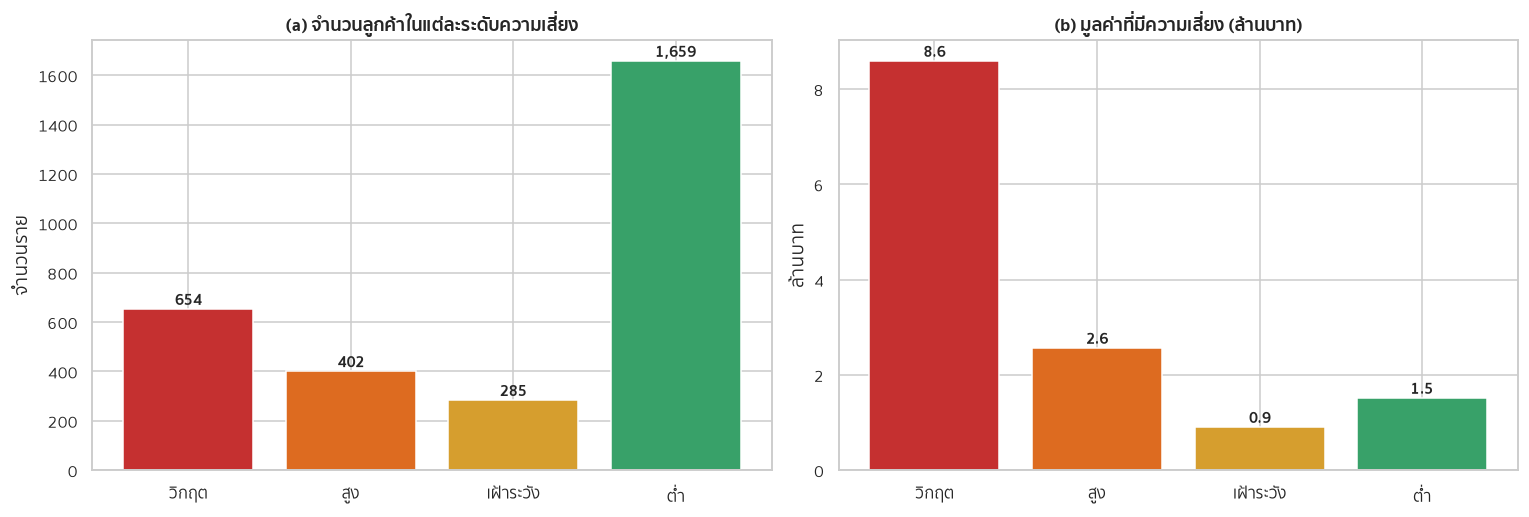

มูลค่าที่มีความเสี่ยงรวม     : 13.60 ล้านบาท
อยู่ในกลุ่มที่ต้องลงมือทันที : 11.17 ล้านบาท (82% ของทั้งหมด)

นิยาม: มูลค่าที่มีความเสี่ยง = ความน่าจะเป็นที่จะหาย x ยอดใช้จ่ายสะสมของลูกค้ารายนั้น
       เป็นตัวเลขไว้ 'จัดลำดับความสำคัญ' ไม่ใช่พยากรณ์ความสูญเสียที่จะเกิดขึ้นจริง


In [63]:
# Where is the money at risk? Combine probability with each customer's value.
risk["value_at_risk"] = risk.churn_probability * risk.monetary.fillna(0)
var_by_tier = risk.groupby("risk_tier", observed=True).agg(
    n=("churn_probability", "size"),
    total_monetary=("monetary", "sum"),
    value_at_risk=("value_at_risk", "sum"))
save_table(var_by_tier.reset_index(), "t29_value_at_risk_by_tier")

total_var = float(risk.value_at_risk.sum())
actionable_var = float(risk[risk.risk_tier.isin(["วิกฤต", "สูง"])].value_at_risk.sum())
rv("deploy_total_value_at_risk_thb", round(total_var, 0))
rv("deploy_actionable_value_at_risk_thb", round(actionable_var, 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors_tier = {"วิกฤต": "#c53030", "สูง": "#dd6b20", "เฝ้าระวัง": "#d69e2e", "ต่ำ": "#38a169"}
axes[0].bar(tier_counts.index, tier_counts.values,
            color=[colors_tier[t] for t in tier_counts.index])
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("(a) จำนวนลูกค้าในแต่ละระดับความเสี่ยง")
axes[0].set_ylabel("จำนวนราย")

vr = var_by_tier.value_at_risk.reindex(["วิกฤต", "สูง", "เฝ้าระวัง", "ต่ำ"]) / 1e6
axes[1].bar(vr.index, vr.values, color=[colors_tier[t] for t in vr.index])
for i, v in enumerate(vr.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("(b) มูลค่าที่มีความเสี่ยง (ล้านบาท)")
axes[1].set_ylabel("ล้านบาท")

fig.tight_layout()
save_fig(fig, "f15_risk_distribution")
plt.show()

print(f"มูลค่าที่มีความเสี่ยงรวม     : {total_var/1e6:,.2f} ล้านบาท")
print(f"อยู่ในกลุ่มที่ต้องลงมือทันที : {actionable_var/1e6:,.2f} ล้านบาท "
      f"({actionable_var/total_var:.0%} ของทั้งหมด)")
print()
print("นิยาม: มูลค่าที่มีความเสี่ยง = ความน่าจะเป็นที่จะหาย x ยอดใช้จ่ายสะสมของลูกค้ารายนั้น")
print("       เป็นตัวเลขไว้ 'จัดลำดับความสำคัญ' ไม่ใช่พยากรณ์ความสูญเสียที่จะเกิดขึ้นจริง")

## 6.2 ข้อเสนอเชิงกลยุทธ์ต่อผู้บริหาร

In [64]:
# Tie every recommendation back to a number produced in this notebook
V = {k: v["value"] for k, v in REPORT_VALUES.items() if not k.startswith("_")}

top_bundle = bundle_df.iloc[0]
champ_row = persona_df[persona_df["ชื่อ Persona"].str.contains("Champions")]
risk_row = persona_df[persona_df["ชื่อ Persona"].str.contains("At-Risk")]

if len(champ_row) and len(risk_row):
    seg_evidence = (f"กลุ่ม Champions มีเพียง {champ_row['% ของลูกค้า'].iloc[0]} ของลูกค้า "
                    f"แต่สร้างรายได้ถึง {champ_row['% ของรายได้'].iloc[0]} · "
                    f"ขณะที่กลุ่ม At-Risk High-Value มีอัตรา churn "
                    f"{risk_row['อัตรา churn'].iloc[0]}")
else:
    seg_evidence = "ดูตาราง persona ใน §4.2"

recommendations = [
    {
        "ข้อ": 1,
        "โจทย์": "เพิ่มยอดขายต่อบิล",
        "ข้อเสนอ": f"จัดชุดโปรโมชัน {V['ar_n_bundles']} ชุดตามกลุ่มสินค้าที่ซื้อร่วมกัน "
                   f"เริ่มจากหมวด {top_bundle['หมวดสินค้า']} ซึ่งมีความสัมพันธ์แน่นที่สุด",
        "หลักฐาน": f"กฎความสัมพันธ์ {V['ar_n_rules']} ข้อ · Lift สูงสุด {V['ar_max_lift']} เท่า · "
                   f"มี {V['ar_n_rules_lift_gt_10']} กฎที่ Lift เกิน 10 เท่า",
        "วิธีวัดผล": "ทดสอบ A/B วัดจำนวนรายการต่อบิลและกำไรขั้นต้นต่อบิล",
        "ความเสี่ยง": "กฎบอกความสัมพันธ์ ไม่ใช่เหตุและผล ลูกค้าอาจตั้งใจซื้อคู่กันอยู่แล้ว "
                     "การลดราคาจึงอาจกัดกำไรโดยไม่เพิ่มยอดขาย",
    },
    {
        "ข้อ": 2,
        "โจทย์": "ยิงโปรโมชันให้ตรงกลุ่ม",
        "ข้อเสนอ": f"แบ่งงบการตลาดตาม {V['seg_k_chosen']} persona "
                   f"โดยให้งบ retention กับกลุ่ม At-Risk High-Value เป็นอันดับแรก",
        "หลักฐาน": seg_evidence,
        "วิธีวัดผล": "เทียบ ROI ของแคมเปญรายกลุ่มกับการยิงแบบหว่านแหทั้งฐานลูกค้า",
        "ความเสี่ยง": "กลุ่มเหล่านี้ไม่ใช่กลุ่มธรรมชาติ (ยืนยันด้วย DBSCAN ใน §4.2) "
                     "ลูกค้าใกล้เส้นแบ่งอาจสลับกลุ่มเมื่อ retrain "
                     "จึงไม่ควรผูกสิทธิประโยชน์ถาวรไว้กับหมายเลข segment",
    },
    {
        "ข้อ": 3,
        "โจทย์": "รักษาลูกค้าเดิม",
        "ข้อเสนอ": f"เดินแคมเปญ retention กับลูกค้า {V['deploy_n_actionable']:,} ราย "
                   f"ที่โมเดลจัดอยู่ในระดับเสี่ยงสูงและวิกฤต",
        "หลักฐาน": f"PR-AUC {V['eval_test_pr_auc']} บนชุดทดสอบ · "
                   f"จับผู้ที่กำลังจะหายได้ {V['eval_recall_at_chosen']:.0%} · "
                   f"มูลค่าที่มีความเสี่ยงในกลุ่มนี้ "
                   f"{V['deploy_actionable_value_at_risk_thb']/1e6:,.1f} ล้านบาท",
        "วิธีวัดผล": "กันกลุ่มควบคุมไว้ไม่ส่งแคมเปญ แล้วเทียบอัตราการกลับมาซื้อจริง",
        "ความเสี่ยง": f"เกณฑ์ตัดสิน {V['eval_threshold_chosen']} ไวต่อสมมติฐานต้นทุนมาก "
                     f"(เคลื่อนได้ในช่วง {V['eval_sensitivity_threshold_min']}"
                     f"-{V['eval_sensitivity_threshold_max']}) "
                     f"ต้องยืนยันตัวเลขต้นทุนกับฝ่ายการเงินก่อนใช้จริง",
    },
]

rec_df = pd.DataFrame(recommendations)
save_table(rec_df, "t28_strategic_recommendations")
rv("deploy_recommendations", rec_df.to_dict("records"))

for r in recommendations:
    print("=" * 78)
    print(f"ข้อเสนอที่ {r['ข้อ']} — {r['โจทย์']}")
    print("=" * 78)
    print(f"  ข้อเสนอ    : {r['ข้อเสนอ']}")
    print(f"  หลักฐาน    : {r['หลักฐาน']}")
    print(f"  วิธีวัดผล  : {r['วิธีวัดผล']}")
    print(f"  ความเสี่ยง : {r['ความเสี่ยง']}")
    print()

ข้อเสนอที่ 1 — เพิ่มยอดขายต่อบิล
  ข้อเสนอ    : จัดชุดโปรโมชัน 10 ชุดตามกลุ่มสินค้าที่ซื้อร่วมกัน เริ่มจากหมวด Pet ซึ่งมีความสัมพันธ์แน่นที่สุด
  หลักฐาน    : กฎความสัมพันธ์ 96 ข้อ · Lift สูงสุด 22.55 เท่า · มี 43 กฎที่ Lift เกิน 10 เท่า
  วิธีวัดผล  : ทดสอบ A/B วัดจำนวนรายการต่อบิลและกำไรขั้นต้นต่อบิล
  ความเสี่ยง : กฎบอกความสัมพันธ์ ไม่ใช่เหตุและผล ลูกค้าอาจตั้งใจซื้อคู่กันอยู่แล้ว การลดราคาจึงอาจกัดกำไรโดยไม่เพิ่มยอดขาย

ข้อเสนอที่ 2 — ยิงโปรโมชันให้ตรงกลุ่ม
  ข้อเสนอ    : แบ่งงบการตลาดตาม 4 persona โดยให้งบ retention กับกลุ่ม At-Risk High-Value เป็นอันดับแรก
  หลักฐาน    : กลุ่ม Champions มีเพียง 25.0% ของลูกค้า แต่สร้างรายได้ถึง 76.5% · ขณะที่กลุ่ม At-Risk High-Value มีอัตรา churn 45.2%
  วิธีวัดผล  : เทียบ ROI ของแคมเปญรายกลุ่มกับการยิงแบบหว่านแหทั้งฐานลูกค้า
  ความเสี่ยง : กลุ่มเหล่านี้ไม่ใช่กลุ่มธรรมชาติ (ยืนยันด้วย DBSCAN ใน §4.2) ลูกค้าใกล้เส้นแบ่งอาจสลับกลุ่มเมื่อ retrain จึงไม่ควรผูกสิทธิประโยชน์ถาวรไว้กับหมายเลข segment

ข้อเสนอที่ 3 — รักษาลูกค้าเดิม
  ข้อเสนอ    : เดินแค

## 6.3 แผนการนำไปใช้จริงและการดูแลรักษา

### จังหวะการทำงานที่แนะนำ

| ความถี่ | กิจกรรม | ผู้รับผิดชอบ |
|---|---|---|
| **รายสัปดาห์** | ให้คะแนนความเสี่ยงลูกค้าใหม่ · ส่งรายชื่อกลุ่มวิกฤตให้ทีม CRM | ทีมข้อมูล → CRM |
| **รายเดือน** | ทบทวนผลแคมเปญเทียบกลุ่มควบคุม · ตรวจว่าการกระจายของฟีเจอร์เปลี่ยนไปหรือไม่ | ทีมข้อมูล |
| **รายไตรมาส** | ฝึกโมเดลใหม่ทั้งหมด · ทบทวนจำนวน segment · ทบทวนกฎความสัมพันธ์ตามฤดูกาล | ทีมข้อมูล |
| **รายปี** | ทบทวนนิยาม churn (90 วัน) และสมมติฐานต้นทุนร่วมกับฝ่ายธุรกิจ | ทีมข้อมูล + ฝ่ายธุรกิจ |

### สัญญาณที่บอกว่าต้องฝึกโมเดลใหม่ทันที ไม่ต้องรอถึงรอบ

- PR-AUC บนข้อมูลใหม่ตกลงเกิน 10% จากค่าที่บันทึกไว้ใน `outputs/report_values.json`
- การกระจายของฟีเจอร์สำคัญ (โดยเฉพาะ `recency` และ `frequency`) เปลี่ยนอย่างมีนัยสำคัญ
- อัตรา churn จริงเบี่ยงจากที่โมเดลทำนายเกิน 5 จุดเปอร์เซ็นต์
- มีเหตุการณ์ใหญ่ที่เปลี่ยนพฤติกรรมผู้บริโภค (คู่แข่งรายใหม่ · วิกฤตเศรษฐกิจ · เปลี่ยนนโยบายราคา)

### สิ่งที่ต้องทำก่อนใช้งานจริง

1. **ทดสอบแบบมีกลุ่มควบคุม** — อย่าส่งแคมเปญให้ทุกคนในรายชื่อ กันไว้ราว 20% เพื่อวัดผลกระทบจริง
   มิฉะนั้นจะแยกไม่ออกว่าลูกค้ากลับมาเพราะแคมเปญ หรือเขาจะกลับมาอยู่แล้ว
2. **ยืนยันตัวเลขต้นทุนกับฝ่ายการเงิน** — เกณฑ์ตัดสินไวต่อสมมติฐานมาก (ดูผลทดสอบใน §5.2.1)
3. **ตรวจสอบความยินยอมและความเป็นส่วนตัว** — ติดต่อเฉพาะลูกค้าที่ `marketing_optin = 1`
4. **ตรวจสอบความเป็นธรรม** — ตรวจว่าโมเดลไม่ได้เลือกปฏิบัติต่อกลุ่มประชากรใดอย่างไม่เป็นธรรม
5. **เตรียมแผนสำรอง** — ถ้าระบบให้คะแนนล่ม ใช้กฎจาก Decision Tree ใน §5.3 ทดแทนได้ทันที

In [65]:
# Persist every number the report will quote, so each figure in the write-up
# can be traced back to this exact run.
dump_report_values()

n_values = len([k for k in REPORT_VALUES if not k.startswith("_")])
n_figs = len(REPORT_VALUES.get("_figures", []))
n_tbls = len(REPORT_VALUES.get("_tables", []))

print()
print("=" * 70)
print("สรุปผลลัพธ์ที่ notebook นี้ผลิตออกมา")
print("=" * 70)
print(f"  ค่าตัวเลขสำหรับรายงาน : {n_values} ค่า -> outputs/report_values.json")
print(f"  รูปภาพ               : {n_figs} ไฟล์ -> outputs/figures/")
print(f"  ตาราง                : {n_tbls} ไฟล์ -> outputs/tables/")
print()
print("ทุกตัวเลขที่ปรากฏในรายงานถูกดึงมาจากไฟล์เหล่านี้เท่านั้น")

Wrote 225 report values -> outputs/report_values.json

สรุปผลลัพธ์ที่ notebook นี้ผลิตออกมา
  ค่าตัวเลขสำหรับรายงาน : 225 ค่า -> outputs/report_values.json
  รูปภาพ               : 16 ไฟล์ -> outputs/figures/
  ตาราง                : 31 ไฟล์ -> outputs/tables/

ทุกตัวเลขที่ปรากฏในรายงานถูกดึงมาจากไฟล์เหล่านี้เท่านั้น


---
# สรุปผลการดำเนินงานตามกระบวนการ CRISP-DM

| ขั้นตอน | สิ่งที่ทำ | ผลลัพธ์สำคัญ |
|---|---|---|
| **1. Business Understanding** | แปลงคำถามผู้บริหาร 3 ข้อเป็นโจทย์ ML พร้อมระบุเหตุผลการเลือกเทคนิค | กำหนดเส้นแบ่งการรั่วไหลของข้อมูลตั้งแต่ต้น |
| **2. Data Understanding** | สำรวจ 6 ตาราง · ตรวจคุณภาพข้อมูล · EDA | พบปัญหาคุณภาพครบทุกข้อและวัดปริมาณได้จริง |
| **3. Data Preparation** | ทำความสะอาด · สร้าง 3 ชุดข้อมูล · ตรวจ leakage อัตโนมัติ | ชุดข้อมูลที่พิสูจน์ได้ด้วยโค้ดว่าไม่รั่ว |
| **4. Modeling** | Association Rules · Clustering · Classification 9 โมเดล + จูน + Stacking | เลือกโมเดลจากผลการทดลองจริง ไม่ใช่จากความเชื่อ |
| **5. Evaluation** | ประเมินบนชุดทดสอบ · ปรับเกณฑ์ตามต้นทุน · ทดสอบความไว · หาสัญญาณเตือน | ตอบครบทั้ง 3 คำถาม พร้อมระบุข้อจำกัด |
| **6. Deployment** | รายชื่อลูกค้าเสี่ยง · ข้อเสนอเชิงกลยุทธ์ · แผน monitoring | ส่งมอบสิ่งที่ทีมงานนำไปใช้ได้ทันที |

### ข้อค้นพบเชิงระเบียบวิธีที่ควรค่าแก่การเน้นย้ำ

1. **ค่าเริ่มต้นไม่ใช่ค่าที่ถูกต้องเสมอไป** — เกณฑ์ตัดสิน 0.5 ให้มูลค่าทางธุรกิจต่ำกว่า
   เกณฑ์ที่คำนวณจากต้นทุนจริงอย่างมีนัยสำคัญ
2. **การตรวจสอบสมมติฐานมีค่าเท่ากับผลลัพธ์** — DBSCAN ไม่ได้ให้ segment ที่ดีกว่า K-Means
   แต่บอกเราว่าควร*ตีความ* segment ที่ได้อย่างไร ซึ่งสำคัญไม่แพ้ตัวผลลัพธ์
3. **ผลลบก็คือผลลัพธ์** — Stacking ไม่ได้ช่วย และการรายงานตามจริงพร้อมเหตุผล
   มีค่ากว่าการยัดเทคนิคเข้าไปเพื่อให้ดูซับซ้อน
4. **โมเดลที่แม่นที่สุดไม่ใช่โมเดลที่อธิบายได้ดีที่สุด** — จึงใช้ทั้งสองบทบาทคู่กัน
   แทนที่จะเลือกอย่างใดอย่างหนึ่ง